# Datathon Passos Mágicos — Relatório de Análise

Este relatório utiliza a base `data/processed/pede_unificado.csv` — painel de formato longo criado por 01_clean.py com id composto aluno × ano ; 1.661 alunos distintos, 3 anos (2022–2024), 3.030 avaliações — para responder às questões propostas pelo Tech Challenge. Além das considerações em cada seção, apresento um resumo executivo ao final.


## Configuração do Ambiente de Trabalho


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Definição das Cores do Tema
# Utilizei o meu tema pessoal, mas a organização pode ajustar os valores para usar o seu próprio.
CORES_MARCA = ['#1F3A5F', '#E0A458', '#2F6F73', '#DF745C', '#4C6A92', '#9AA5B1']
AZUL, AMBAR, TEAL, CORAL, CINZA = '#1F3A5F', '#E0A458', '#2F6F73', '#DF745C', '#9AA5B1'
CORAL_CLARO, TEAL_CLARO = '#E79887', '#3E9297'
FUNDO, GRADE = '#F5F7FA', 'rgba(154, 165, 177, 0.35)'

# Além das cores, adicionei marcadores a cada fase para ajudar a discernir uma da outra em gráficos de linha.
CORES_FASE = ['#1F3A5F', '#E0A458', '#2F6F73', '#DF745C', '#2C5185',
              '#E8BB83', '#3E9297', '#E79887', '#241F5F', '#2F4D73']
MARCAS_FASE = ['circle', 'square', 'diamond', 'triangle-up', 'x',
               'star', 'pentagon', 'cross', 'triangle-down', 'hexagon']

px.defaults.color_discrete_sequence = CORES_MARCA
px.defaults.template = 'plotly_white'

# plotly_mimetype plota o gráfico interativo no Jupyter/PyCharm; png é o fallback estático, porque o GitHub
# não executa JavaScript ao exibir um .ipynb. O fallback depende de kaleido + Chrome (`plotly_get_chrome`);
# sem eles o notebook roda igual, mas sem png.
try:
    pio.to_image(go.Figure(), format='png')
    pio.renderers.default = 'plotly_mimetype+png'
except Exception:
    pio.renderers.default = 'plotly_mimetype'


def aplicar_tema(fig, altura=430):
    fig.update_layout(paper_bgcolor=FUNDO, plot_bgcolor=FUNDO, font_color=AZUL, title_font_color=AZUL,
                      legend_title_font_color=AZUL, height=altura,
                      margin=dict(l=70, r=30, t=60, b=55))
    fig.update_xaxes(gridcolor=GRADE, linecolor=GRADE, zerolinecolor=GRADE)
    fig.update_yaxes(gridcolor=GRADE, linecolor=GRADE, zerolinecolor=GRADE)
    return fig


def linhas_por_fase(piv, titulo, rotulo_y):
    """Uma linha por fase ao longo dos anos, cada uma com cor e marcador próprios. O hover unificado
    mostra todas as fases do mesmo ano de uma vez, permitindo comparar as fases entre si."""
    fig = go.Figure()
    for i, fase in enumerate(piv.columns):
        fig.add_scatter(x=piv.index, y=piv[fase], mode='lines+markers', name=f'{fase:g}',
                        line=dict(color=CORES_FASE[i % len(CORES_FASE)], width=2),
                        marker=dict(symbol=MARCAS_FASE[i % len(MARCAS_FASE)], size=9),
                        hovertemplate='%{y:.2f}<extra></extra>')
    fig.update_layout(title=titulo, xaxis_title='ano', yaxis_title=rotulo_y, legend_title='fase',
                      hovermode='x unified')
    fig.update_xaxes(tickmode='array', tickvals=list(piv.index))
    return aplicar_tema(fig)


def variacao_por_fase(base, coluna, titulo, rotulo_y, ano_zero=2022):
    """Média da variação do indicador acompanhando os alunos, por fase e por ano, calculada só sobre quem já
    estava na base no ano anterior. A fase usada é a do ano de chegada, a mesma do rótulo no eixo x. A tabela
    vai impressa junto porque as leituras citam fases específicas, e o número de alunos por célula é o que
    diz quais pontos merecem confiança."""
    piv = base.pivot_table(index='ano', columns='fase_t1', values=f'd_{coluna}')
    n = base.pivot_table(index='ano', columns='fase_t1', values=f'd_{coluna}', aggfunc='size')
    piv.index += 1
    n.index += 1
    piv.loc[ano_zero] = 0.0
    piv = piv.sort_index()
    print(f'Δ {coluna.upper()} médio por fase — linhas: ano de chegada ({ano_zero} é a referência em zero):')
    print(piv.round(2).to_string())
    print('\nAlunos por célula:')
    print(n.sort_index().to_string())
    geral = base.groupby(base.ano + 1)[f'd_{coluna}'].mean()
    print('\nMédia de todas as fases juntas — ' + ' | '.join(f'{a}: {v:+.3f}' for a, v in geral.items()))
    fig = linhas_por_fase(piv, titulo, rotulo_y)
    fig.add_hline(y=0, line=dict(color=CINZA, width=1))
    return fig


## Nota metodológica

Apresento aqui algumas decisões que perpassam o relatório, valendo para mais de uma das questões analisadas. A ideia é concentrá-las e justificá-las em um único lugar para não ter que ficar repetindo-as ao longo da análise.

### Acompanhar o mesmo aluno, em vez da média do ano.
As perguntas sobre a progressão dos indicadores apresentam uma armadilha: se considerarmos as médias anuais, não estaremos medindo a progressão de fato dos alunos, pois a cada ano novos alunos começam a fazer parte ou deixam de participar da associação. Para de fato mensurarmos a efetividade do Programa de Aceleração do Conhecimento, precisamos seguir os alunos ao longo do tempo.

Se considerássemos apenas os alunos presentes nos três anos, teríamos dois problemas:
1. Teríamos informações sobre apenas 468 alunos;
2. Alunos que evadiram seriam desconsiderados, nos privando de informações importantes sobre as causas da evasão.

Por isso, a função `montar_painel` acompanha cada aluno de um ano para o seguinte: individualmente, os alunos de fato melhoraram de ano a ano? Por meio dessa estratégia, conseguimos aumentar o número de alunos monitorados para 897. A tabela resultante é utilizada em todas as questões que falam em mudança — da P1 à P11, com a exceção da P8, que analisa a composição do INDE dentro de cada ano e não precisa acompanhar ninguém. Onde a pergunta for sobre mudança, a média anual entra apenas como camada a ser confrontada, não como fundamento da análise.

**Obs.:** algumas perguntas, por possuírem natureza diferente das demais, pedem recortes diferentes — a P10, por exemplo, precisa dos mesmos alunos nos três anos, o que as outras não precisam. Nesses casos, o critério selecionado é apresentado junto à análise.

### Alunos de fase 8 ficaram de fora de boa parte das análises
A fase 8, que agrupa os alunos do ensino superior, fica de fora de boa parte do relatório. Isso acontece por duas principais razões:

1. Nas análises dos indicadores de desempenho — IDA, INDE e o que deriva deles —, o recorte é simplesmente `fase <= 7`, porque para esses alunos quase não há indicador medido: das 127 linhas de fase 8 da base, 1 tem IDA e nenhuma tem INDE. Mantê-las não acrescentaria informação, apenas células vazias. Essa contagem é impressa na primeira célula da P2.
2. Na análise de defasagem (P1), quem está na fase 8 está, por definição, em fase. Isso significa que alunos que entram na associação já na universidade (provavelmente por ganharem bolsa) reduziriam artificialmente as taxas de defasagem sem sequer terem passado pelo Programa de Aceleração do Conhecimento. Por isso a P1 utiliza apenas os alunos de fase 8 que efetivamente passaram pelo programa. Os descartados de cada ano são impressos junto da análise: 0 em 2022, 44 em 2023 e 71 em 2024.

**Obs.:** a P11 é a exceção patente a este ponto. Afinal, a análise feita lá é sobre permanência, que se aplica a todo mundo — a fase 8, inclusive aparece nela com a menor taxa de evasão da base.

### Barras em sentido negativo têm o objetivo de facilitar a leitura
Quando o eixo y expressar porcentagens, as barras que se encontram abaixo do eixo x não indicam uma população negativa, o que seria impossível: seu sentido serve apenas como auxílio visual para separar situações positivas (estar em fase) das negativas (defasagem). Em função disso, inclusive, o eixo y não apresenta sinal negativo nesses casos.

### Dinâmicas que aparecem como resposta a várias perguntas são reunidas ao fim do relatório
Padrões que aparecem em mais de uma resposta — a instabilidade das medições de um ano para o outro, o efeito de empilhar transições diferentes numa correlação só — não são reexplicados a cada seção. Eles são demonstrados uma vez na P11 e referenciados de volta, que é onde também ficam as relações entre os indicadores.

In [2]:
def montar_painel(base):
    """
    Acompanha cada aluno de um ano para o seguinte: cada linha junta o que ele era em t e o que virou
    em t+1, com as variações de cada indicador entre as duas pontas.
    """
    cols = ['id_aluno', 'ano', 'fase', 'defasado', 'defasagem', 'iaa_recusa', 'genero',
            'tempo_vinculo'] + IND
    atual = base[cols].assign(iaa=base['iaa_val'])
    seguinte = atual.copy()
    seguinte['ano'] -= 1
    p = atual.merge(seguinte, on=['id_aluno', 'ano'], suffixes=('', '_t1'))
    for c in IND + ['defasagem']:
        p['d_' + c] = p[c + '_t1'] - p[c]
    p['avancou'] = p['fase_t1'] > p['fase']
    p['transicao'] = p['ano'].astype(str) + '→' + (p['ano'] + 1).astype(str)
    return p


def corr_por_par(variaveis, base=None):
    """
    Correlação de Pearson entre duas variações do mesmo aluno, calculada dentro de cada transição e depois
    com todas juntas. Juntar transições diferentes pode criar correlação que não existe em nenhuma delas,
    por isso a linha 'todos' só vale quando concorda com as transições.
    """
    base = painel if base is None else base
    linhas = []
    for x, y in variaveis:
        for nome, g in list(base.groupby('transicao')) + [('todos', base)]:
            g = g.dropna(subset=[x, y])
            r, pv = stats.pearsonr(g[x], g[y])
            linhas.append((f'{x} × {y}', nome, round(r, 3), f'{pv:.1e}', len(g)))
    return pd.DataFrame(linhas, columns=['variação', 'transição', 'pearson', 'p_valor', 'n'])


## Quadro-Resumo

In [3]:
df = pd.read_csv('../data/processed/pede_unificado.csv')
ev = pd.read_csv('../data/processed/evasao.csv')

for c in ('defasado', 'atingiu_pv', 'iaa_recusa'):
    df[c] = df[c].map(lambda v: pd.NA if pd.isna(v) else v in (True, 'True')).astype('boolean')

IND = ['ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv', 'inde']
PESOS = {'ian': 0.1, 'ida': 0.2, 'ieg': 0.2, 'iaa': 0.1, 'ips': 0.1, 'ipp': 0.1, 'ipv': 0.2}

painel = montar_painel(df)

print(f'{df.shape[0]} avaliações | {df.id_aluno.nunique()} alunos distintos | {len(df.ano.unique())} anos: {sorted(df.ano.unique())}')
print(f'Painel t→t+1: {len(painel)} transições de {painel.id_aluno.nunique()} alunos '
      f'({painel.id_aluno.nunique() / df.id_aluno.nunique() * 100:.0f}% da base) — '
      f'{painel.transicao.value_counts().sort_index().to_dict()}')
print('Qtde de Alunos por Ano:')
df.groupby('ano').size()


3030 avaliações | 1661 alunos distintos | 3 anos: [np.int64(2022), np.int64(2023), np.int64(2024)]
Painel t→t+1: 1365 transições de 897 alunos (54% da base) — {'2022→2023': 600, '2023→2024': 765}
Qtde de Alunos por Ano:


ano
2022     860
2023    1014
2024    1156
dtype: int64

In [4]:
# As peças abaixo se repetem em todo o relatório, da P1 à P11. Cada uma existe por um motivo que vale para
# qualquer seção: percentual sem contagem engana, grupo pequeno merece desconto e barra divergente não
# autoriza eixo negativo. Ficam reunidas aqui para que nenhuma seção precise reinventá-las nem se encaixar
# num gráfico genérico.

# Abaixo disso a média de uma célula responde mais ao acaso do que ao grupo.
MIN_CELULA = 10


def rotulo_n(rotulos, ns):
    """Escreve o tamanho do grupo no próprio rótulo do eixo. Um percentual sem o número de alunos por trás
    convida a ler uma diferença grande num grupo minúsculo como se fosse achado, e deixar o n só no hover
    não resolve: o gráfico também é lido impresso, onde não existe hover."""
    return [f'{r}<br>n={n:.0f}' for r, n in zip(rotulos, ns)]


def hover_taxa(pct, num, den):
    """Monta o customdata e o texto do hover no formato '12.3%  (45 de 366)'. O percentual sozinho esconde
    de quantos alunos ele saiu, então o numerador e o denominador viajam junto com ele e qualquer barra
    pode ser conferida sem sair do gráfico."""
    return (np.stack([pct, num, den], axis=-1),
            '%{customdata[0]:.1f}%  (%{customdata[1]:.0f} de %{customdata[2]:.0f})<extra></extra>')


def eixo_divergente(fig, valores, passo, casas=0):
    """Fecha a escala simétrica em torno do zero e rotula o eixo pelo valor absoluto. Fazer as barras
    divergirem é uma escolha de leitura — para cima o que melhora, para baixo o que piora —, e ela não pode
    virar um eixo afirmando número negativo onde não existe: o desenho pode ser metáfora, o eixo não."""
    teto = np.ceil(np.nanmax(np.abs(valores)) / passo) * passo
    marcas = np.arange(-teto, teto + passo / 2, passo)
    fig.update_yaxes(tickmode='array', tickvals=marcas,
                     ticktext=[f'{abs(v):.{casas}f}' for v in marcas], range=[-teto * 1.12, teto * 1.12])
    fig.add_hline(y=0, line=dict(color=CINZA, width=1))
    return fig


def marca_referencia(fig, x, y, nome, formato='.2f', cor=AZUL, **kw):
    """Desenha o valor do conjunto como um traço horizontal por cima das barras. Sem ele o leitor compara
    cada barra com a vizinha e fica sem saber se as duas estão acima ou abaixo do todo, que costuma ser a
    pergunta que importa. A cor entra por parâmetro porque o traço nunca deve repetir a da barra a que se
    refere: um traço fino no mesmo tom da barra desaparece dentro dela, e dois traços de tons vizinhos não
    se separam um do outro."""
    fig.add_scatter(x=x, y=y, mode='markers', name=nome,
                    marker=dict(symbol='line-ew', size=26, line=dict(color=cor, width=2)),
                    hovertemplate='%{y:' + formato + '}<extra></extra>', **kw)
    return fig


def faixas_quartil(serie, casas=1):
    """Corta em quatro grupos de tamanho parecido e rotula cada um pela faixa de valores que ele cobre. O
    quartil entra no lugar de uma régua redonda porque os indicadores desta base são concentrados no alto:
    cortar de dois em dois pontos jogaria três quartos dos alunos numa barra só, e a comparação que
    interessa desapareceria dentro dela."""
    faixas, cortes = pd.qcut(serie, 4, retbins=True, duplicates='drop')
    rotulos = [f'{a:.{casas}f} a {b:.{casas}f}'.replace('.', ',') for a, b in zip(cortes[:-1], cortes[1:])]
    return faixas.cat.rename_categories(rotulos), rotulos


def barras_nivel(medias, ns, titulo, eixo_x, rotulo_y, cores=(AZUL, TEAL, AMBAR), referencias=None,
                 altura=440, cores_ref=(CORAL, AMBAR, CINZA)):
    """Média de um ou mais indicadores dentro de cada faixa de um terceiro, com o n no rótulo do eixo e o
    valor de referência desenhado por cima. Nível não diverge do zero, então aqui não há sinal a separar por
    cor: o que se compara é a altura de cada barra contra a marca da referência, e não uma barra contra a
    vizinha — que é a comparação que o olho faz sozinho e quase sempre é a errada. O n pode vir por grupo,
    uma contagem só para o rótulo do eixo, ou por série, quando cada barra tem população própria; nesse caso
    o rótulo leva o total do grupo e cada barra leva o seu n no hover. A referência de cada série sai no tom
    de contraste dela — coral para a barra azul, âmbar para a verde, cinza para a âmbar —, e não na cor da
    própria série: são traços finos, e dois tons vizinhos lado a lado deixam de ser dois traços."""
    por_serie = isinstance(ns, pd.DataFrame)
    x = rotulo_n([str(i) for i in medias.index], ns.sum(axis=1) if por_serie else ns)
    fig = go.Figure()
    for (nome, col), cor in zip(medias.items(), cores):
        fig.add_bar(x=x, y=col, name=nome, marker_color=cor,
                    customdata=np.stack([col.to_numpy(),
                                         np.asarray(ns[nome] if por_serie else ns)], axis=-1),
                    hovertemplate='%{customdata[0]:.2f} de média  ·  %{customdata[1]:.0f} alunos'
                                  '<extra>' + nome + '</extra>')
    for (nome, valor), cor in zip((referencias or {}).items(), cores_ref):
        marca_referencia(fig, x, [valor] * len(x), nome, cor=cor)
    fig.update_layout(barmode='group', title=titulo, xaxis_title=eixo_x, yaxis_title=rotulo_y,
                      hovermode='x unified', legend_title='')
    return aplicar_tema(fig, altura)


def barras_taxa(pct, num, den, titulo, eixo_x, rotulo_y, referencia=None, nome_ref='',
                cores=(AZUL, AMBAR), altura=440):
    """Parcela de alunos numa situação dentro de cada categoria, com o n no rótulo do eixo e o numerador no
    hover. É o barras_nivel com a frase certa: lá o hover narra "de média", que aqui seria falso, porque a
    barra não é a média de uma nota e sim quantos alunos de cada grupo estão de um lado. A referência
    aceita um valor por categoria, e não um só para o gráfico inteiro, porque a taxa do conjunto costuma
    mudar de uma categoria para a outra — foi o que a P10 precisou para pôr a taxa publicada na P1 ao lado
    da coorte, ano a ano."""
    pct, num, den = (v.to_frame() if isinstance(v, pd.Series) else v for v in (pct, num, den))
    x = rotulo_n([f'{i:g}' if isinstance(i, float) else str(i) for i in pct.index], den.sum(axis=1))
    fig = go.Figure()
    for (nome, col), cor in zip(pct.items(), cores):
        dados, modelo = hover_taxa(col.to_numpy(), num[nome].to_numpy(), den[nome].to_numpy())
        fig.add_bar(x=x, y=col, name=nome, marker_color=cor, customdata=dados,
                    hovertemplate=modelo.replace('<extra></extra>', f'<extra>{nome}</extra>'))
    if referencia is not None:
        marca_referencia(fig, x, list(referencia), nome_ref, formato='.1f', cor=CORAL)
    fig.update_layout(barmode='group', title=titulo, xaxis_title=eixo_x, yaxis_title=rotulo_y,
                      hovermode='x unified', legend_title='')
    return aplicar_tema(fig, altura)


## P1 — Qual o perfil de defasagem escolar (IAN) e como evoluiu?

Aqui, a análise é feita em duas camadas: a **transversal** calcula a taxa e a severidade da defasagem por ano; a **longitudinal** usa o painel de alunos para analisar o que acontece com o mesmo aluno de um ano para o outro: quantos defasados recuperam a fase ideal e quanto permanecem defasados, bem como quantos que estavam em fase se mantêm em fase ou se defasam.

Taxa geral de alunos defasados:
ano
2022    69.9%
2023    56.9%
2024    49.2%
Name: defasado, dtype: str

Alunos em cada nível de defasagem — contagem e % do ano:
cat   severa  moderada  em fase
ano                            
2022      28       573      259
2023      14       538      418
2024       3       531      551
cat   severa  moderada  em fase
ano                            
2022     3.3      66.6     30.1
2023     1.4      55.5     43.1
2024     0.3      48.9     50.8


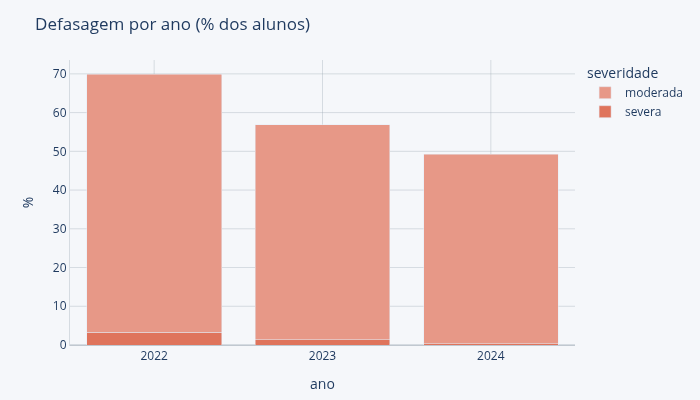


Bolsistas sem passagem pelas fases 0-7 excluídos em cada ano:
ano
2022     0
2023    44
2024    71


In [5]:
# ---------- Camada transversal: quantos alunos estão defasados em cada ano ----------
# Seleção dos alunos para a análise das alterações na taxa de defasagem
uni = df.fase.isna() | (df.fase == 8)
prim_07 = df.loc[~uni].groupby('id_aluno')['ano'].min()
d1 = df[~uni | (df.id_aluno.map(prim_07) < df.ano)]

# Análise de defasagem por severidade e geral a cada ano
cat = np.select([d1.ian == 2.5, d1.ian == 5], ['severa', 'moderada'], default='em fase')
sev = d1.assign(cat=pd.Categorical(cat, ['severa', 'moderada', 'em fase'])) \
        .groupby(['ano', 'cat'], observed=False).size().unstack()
sev_pct = (sev.div(sev.sum(axis=1), axis=0) * 100).round(1)
tx = d1.groupby('ano')['defasado'].mean().mul(100).round(1)
print('Taxa geral de alunos defasados:')
print(tx.astype(str) + '%')

# A contagem sai impressa antes do gráfico porque a fatia severa é pequena em termos absolutos, e uma
# barra fina desenhada em percentual não deixa isso à vista.
print('\nAlunos em cada nível de defasagem — contagem e % do ano:')
print(sev.to_string())
print(sev_pct.to_string())

fig = go.Figure()
for severidade, cor in zip(['severa', 'moderada'], [CORAL, CORAL_CLARO]):
    fig.add_bar(x=sev_pct.index.astype(str), y=sev_pct[severidade], name=severidade, marker_color=cor,
                customdata=np.stack([sev_pct[severidade], sev[severidade], sev.sum(axis=1)], axis=-1),
                hovertemplate='%{customdata[0]:.1f}%  (%{customdata[1]:.0f} de %{customdata[2]:.0f})'
                              '<extra></extra>')
fig.update_layout(barmode='stack', title='Defasagem por ano (% dos alunos)', xaxis_title='ano',
                  yaxis_title='%', legend_title='severidade', hovermode='x unified')
aplicar_tema(fig, 400).show()

print()
print('Bolsistas sem passagem pelas fases 0-7 excluídos em cada ano:')
print((df.groupby('ano').size() - d1.groupby('ano').size()).to_string())


**Conclusão da análise transversal:** a defasagem cai de forma consistente — 69,9% (2022) → 56,9% (2023) → 49,2% (2024) — e a severa quase desaparece (3,3% → 0,3%). A contagem impressa acima diz de quantos alunos se trata em cada ano: são poucas dezenas, e por isso essa é a parte mais frágil do gráfico — a série geral é que sustenta a leitura. Sozinha, porém, essa série não prova a efetividade do PAC, pois fatores como a aquisição de alunos novos aluno em fase ou a evasão de alunos defasados também levariam a taxa de defasagem para baixo. A análise a seguir resolve isso.


Transições dentro do mesmo aluno: 1323 de 855 alunos ({'2022→2023': 600, '2023→2024': 723}).

Matriz de transição da severidade — 1323 transições (de t, nas linhas → para t+1, nas colunas):
para t+1  severa  moderada  em fase  total
de t                                      
severa         5         9        2     16
moderada       5       511      274    790
em fase        0       144      373    517

A mesma matriz como % de cada linha:
para t+1  severa  moderada  em fase
de t                               
severa      31.2      56.2     12.5
moderada     0.6      64.7     34.7
em fase      0.0      27.9     72.1


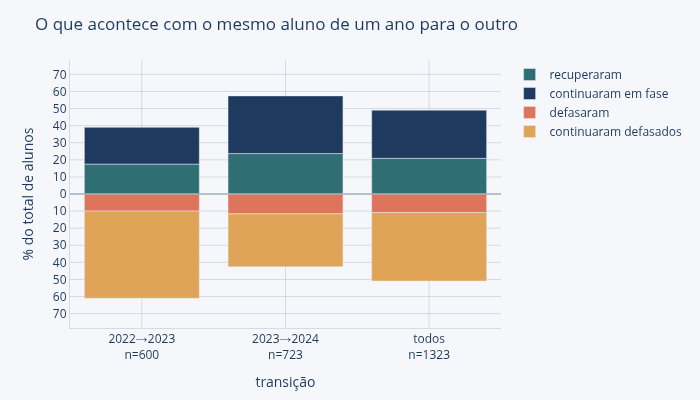

In [6]:
# ---------- Camada longitudinal: o que acontece com cada aluno de um ano para o outro ----------
# A mesma exclusão de universitários vale aqui, e o aluno só entra se as duas pontas sobreviverem a ela.
chaves = set(map(tuple, d1[['id_aluno', 'ano']].to_numpy()))
elegivel = [(a, n) in chaves and (a, n + 1) in chaves for a, n in painel[['id_aluno', 'ano']].to_numpy()]
p1 = painel[elegivel].dropna(subset=['defasado', 'defasado_t1'])


def transicoes(g):
    """Os quatro destinos possíveis do aluno entre t e t+1. Medir cada um contra o próprio grupo de origem
    esconde que os dois grupos têm tamanhos muito diferentes, e um percentual maior pode corresponder a
    menos alunos; por isso o denominador aqui é sempre o total de alunos da transição."""
    de, ef = g.defasado.astype(bool), ~g.defasado.astype(bool)
    de_t1 = g.defasado_t1.astype(bool)
    return pd.Series({'continuaram defasados': (de & de_t1).sum(), 'recuperaram': (de & ~de_t1).sum(),
                      'continuaram em fase': (ef & ~de_t1).sum(), 'defasaram': (ef & de_t1).sum()})


def contar_destinos(base, chaves):
    """Os destinos contados dentro de cada célula de um cruzamento de chaves."""
    return pd.DataFrame({k: transicoes(g) for k, g in base.groupby(chaves, observed=True)}).T.rename_axis(chaves)


def barras_destino(t, titulo, eixo_x, eixo_y='% dos alunos do grupo', altura=470, passo=25):
    """Desenha a tabela de destinos como barras divergentes. Todas as desagregações da P1 usam este mesmo
    gráfico, e o denominador é sempre a própria célula, então cada barra soma os 100% dos alunos dela e grupos
    de tamanhos diferentes ficam comparáveis. Como normalizar apaga justamente o tamanho, o número de alunos
    de cada célula vai no rótulo do eixo, e não só no hover: uma barra de 100% sobre sete alunos ocupa o mesmo
    espaço de uma sobre duzentos, e o leitor precisa poder distinguir as duas sem passar o mouse. O rótulo, o
    hover e o eixo saem das peças definidas antes desta seção, para que a mesma convenção de leitura valha
    aqui e nas dez perguntas seguintes."""
    pct = t.div(t.sum(axis=1), axis=0).mul(100)
    rotulo = lambda v: f'{v:g}' if isinstance(v, float) else str(v)
    eixo = [[rotulo(v) for v in t.index.get_level_values(i)] for i in range(t.index.nlevels)]
    eixo[-1] = rotulo_n(eixo[-1], t.sum(axis=1))
    fig = go.Figure()
    for coluna, cor, sentido in zip(['recuperaram', 'continuaram em fase', 'defasaram', 'continuaram defasados'],
                                    [TEAL, AZUL, CORAL, AMBAR], [1, 1, -1, -1]):
        dados, modelo = hover_taxa(pct[coluna], t[coluna], t.sum(axis=1))
        fig.add_bar(x=eixo if t.index.nlevels > 1 else eixo[0], y=sentido * pct[coluna], name=coluna,
                    marker_color=cor, customdata=dados, hovertemplate=modelo)
    somas = pd.concat([pct[['recuperaram', 'continuaram em fase']].sum(axis=1),
                       pct[['defasaram', 'continuaram defasados']].sum(axis=1)])
    fig.update_layout(barmode='relative', title=titulo, xaxis_title=eixo_x, yaxis_title=eixo_y,
                      hovermode='x unified', legend_title='')
    eixo_divergente(fig, somas, passo)
    return aplicar_tema(fig, altura).update_layout(margin_b=95 if t.index.nlevels > 1 else 70)


tr = pd.DataFrame({nome: transicoes(g) for nome, g in list(p1.groupby('transicao')) + [('todos', p1)]}).T
tr_pct = tr.div(tr.sum(axis=1), axis=0).mul(100)
print(f'Transições dentro do mesmo aluno: {len(p1)} de {p1.id_aluno.nunique()} alunos '
      f'({p1.transicao.value_counts().sort_index().to_dict()}).')

severidade = lambda s: pd.Categorical(np.select([s == 2.5, s == 5], ['severa', 'moderada'], default='em fase'),
                                      ['severa', 'moderada', 'em fase'])
sev1 = p1.dropna(subset=['ian', 'ian_t1'])
mat = pd.crosstab(severidade(sev1.ian), severidade(sev1.ian_t1)).rename_axis(index='de t', columns='para t+1')
print(f'\nMatriz de transição da severidade — {len(sev1)} transições (de t, nas linhas → para t+1, nas colunas):')
# O total de cada linha entra na impressão porque é ele que dá o peso de cada nível de partida: sem
# ele, uma linha de poucas transições e uma de centenas se leem do mesmo jeito nos percentuais abaixo.
print(mat.assign(total=mat.sum(axis=1)).to_string())
# Aqui o denominador volta a ser a linha, de propósito: a pergunta desta matriz não é o que aconteceu com a
# base, e sim para onde vai um aluno dado o nível em que ele estava — e a contagem acima já dá o peso de cada
# linha, que é o que faltava para ler os percentuais sem se enganar.
print('\nA mesma matriz como % de cada linha:')
print(mat.div(mat.sum(axis=1), axis=0).mul(100).round(1).to_string())

# Embora não existam porcentagens negativas, as barras divergem do zero conforme o destino em t+1 para tornar
# o visual mais intuitivo: para cima quem chega em fase, para baixo quem chega defasado. Os dois movimentos
# ficam colados ao eixo e a inércia nas pontas, de modo que a barra inteira soma os 100% dos alunos do ano.
barras_destino(tr, 'O que acontece com o mesmo aluno de um ano para o outro', 'transição', '% do total de alunos',altura=400, passo=10).show()


**Conclusão da análise longitudinal:** considerando o período como um todo, temos que o programa ajudou uma
média de 20,9% dos alunos a recuperaram a defasagem que apresentavam, enquanto 10,9% dos alunos que
estavam em fase ficaram defasados. Além disso, 28,2% dos alunos que estavam em fase assim permaneceram e
40,1% dos alunos que estavam defasados também permaneceram como tal.

A matriz de severidade detalha o movimento, mostrando que 68,7% dos alunos em defasagem severa melhoram de
nível no ano seguinte (56,2% para moderada e 12,5% até a fase ideal), e 72,1% de quem está em fase permanece
nela. As duas porcentagens não têm o mesmo peso, e a matriz impressa acima mostra por quê: a primeira
repousa sobre 16 transições, das quais 11 são a melhora, e meia dúzia de casos a mais ou a menos a viraria
do avesso — ela vale como indício, não como achado. A segunda repousa sobre 517 transições e é sólida.

O mais interessante do gráfico é observarmos a mudança nas transições de 2022->2023 e 2023->2024: enquanto na
primeira transição 61% dos alunos permaneceram ou se tornaram defasados, na segunda apenas 42,6% tiveram o
mesmo destino, o que indica uma melhoria significativa da efetividade do programa.

### Desagregações da Defasagem

Além de analisarmos a defasagem como um todo, também é importante averiguarmos como ela se comporta em
diferentes subgrupos de alunos. Além da desagregação por fase, que é a mais diretamente relacionada à
defasagem, incluí também duas outras que mostraram padrões significativos: o tempo de vínculo do aluno com a instituição e o gênero, cuja diferença se concentra numa fase específica.

#### Defasagem por Fase

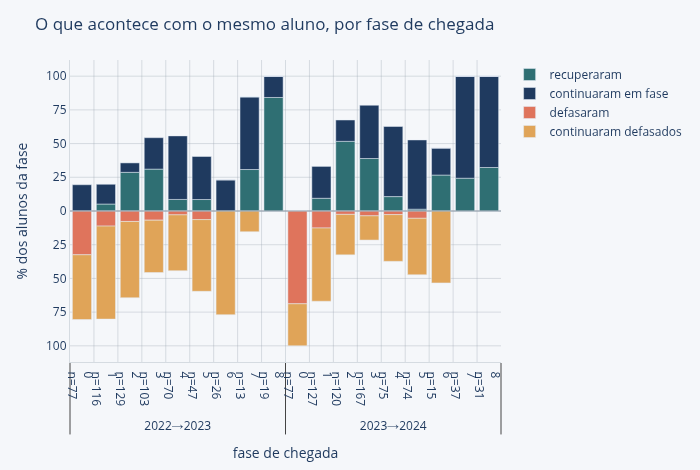

In [7]:
# Utilizei [transição, fase] como níveis do eixo x para facilitar a comparação geral entre anos: observando o
# gráfico, podemos perceber um perfil geral de melhoria em 2023->2024 em comparação com 2022->2023.
pf = p1.dropna(subset=['fase_t1'])
barras_destino(contar_destinos(pf, ['transicao', 'fase_t1']),
               'O que acontece com o mesmo aluno, por fase de chegada', 'fase de chegada',
               '% dos alunos da fase').show()


Cada barra soma 100% dos alunos que chegaram ao ano t+1 em uma dada fase. Acima do zero, temos os alunos que
chegaram em fase; abaixo, os que ficaram defasado. Podemos ver que a recuperação se concentra nas fases 2 e 3
(28,7% e 31,1% em 2022→2023; 51,7% e 38,9% em 2023→2024) e nas fases 7 e 8 (30,8% e 84,2% em 2022→2023; 24,3%
e 32,3% em 2023→2024) — vale lembrar que chegar na fase 8 é, por definição, estar em fase, pois ela é o teto
da escala. Por outro lado, como a fase zero é o início da escala, quase todos os alunos que permanecem nela
em t+1 ficam defasados (com exceção de 19,5% de alunos na virada de 2022 para 2023 que, em função de suas
idades, ainda possuíam a fase 0 como a fase ideal. Outra fase que merece atenção reforçada é a fase 1, em que
11,2% dos alunos se tornaram defasados na transição de 2022->2023 e 12,6% na transição de 2023->2024 — além da
permanência em defasagem de 69% e 54,3% dos alunos nessas transições de ano, respectivamente. A fase 6 também
mostra um grande número de defasados (76,9% em 2022->2023 e 54,3% em 2023->2024), embora nenhum desses sejam
alunos que se tornaram defasados (eles já o eram e assim permaneceram).

O gráfico anterior nos mostrou que a efetividade do Programa de Aceleração do Conhecimento aumentou de 2022
para 2023. Este gráfico mostra onde os alunos recuperados foram parar: as fases 2 e 3 são as que mais os
recebem.

Vale marcar o limite dessa leitura, porque ele decide o que se pode concluir daqui. O eixo é a fase de
**chegada**, em t+1, e recuperar a fase ideal significa justamente avançar de fase — ou seja, é o próprio
desfecho que decide em qual barra o aluno aparece. Quem se recuperou saindo da fase 1 é contado na fase 2, e
some da fase 1. Por isso este gráfico descreve como se compõe a turma que chegou a cada fase, e não de onde
os alunos saíram nem em que fase o programa consegue revertê-la. Para essa pergunta, o eixo precisa ser a
fase de **partida**, em t, com o grupo fechado antes do desfecho acontecer — é o que as tabelas por tempo de
vínculo e por gênero, logo adiante, fazem, e é delas que sai a resposta sobre onde agir.

#### Defasagem por Tempo de Vínculo

Risco de se defasar no ano seguinte, ano a ano de vínculo, entre quem estava em fase em t:
               em_fase_em_t  defasaram_pct
tempo_vinculo                             
0                       221           50.7
1                        92           16.3
2                        39           10.3
3                        45           11.1
4                        60            6.7
5                        32           12.5
6                        19            0.0
7                         9            0.0

Taxas condicionais por tempo de vínculo, com o tamanho de cada grupo de origem:
                  defasados_em_t  recuperaram_%  em_fase_em_t  defasaram_%
vinculo                                                                   
1º ano                     288.0           28.5         221.0         50.7
2º ano em diante           518.0           37.5         296.0         10.8
Diferença de queda entre os dois grupos: 112 de 221 contra 32 de 296 — resiste ao acaso.

E contro

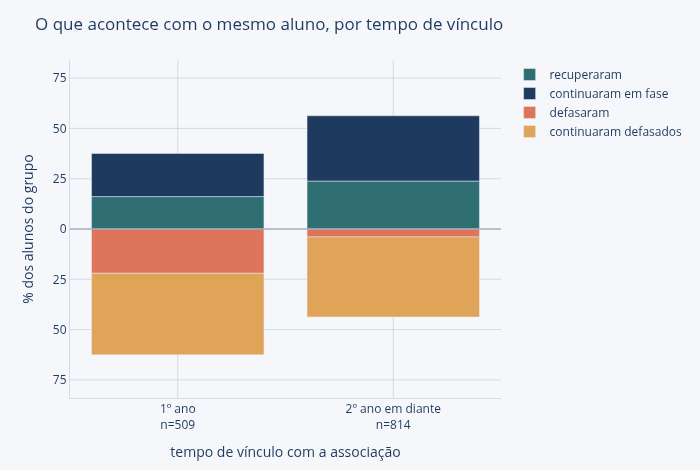

In [8]:
# Com relação ao tempo de vínculo, a separação de coortes que se mostrou proveitosa foi a que resulta em
# apenas dois grupos: ingressantes e demais. O que justifica esse corte é a tabela ano a ano impressa logo
# abaixo, e não uma escolha feita de antemão: a queda do risco acontece toda do primeiro para o segundo ano,
# e daí em diante o número só oscila, sobre grupos cada vez menores.
pv = p1.dropna(subset=['tempo_vinculo']).copy()
pv['vinculo'] = pd.cut(pv.tempo_vinculo, [-1, 0, 99], labels=['1º ano', '2º ano em diante'])

emf_v = pv[~pv.defasado.astype(bool)]
print('Risco de se defasar no ano seguinte, ano a ano de vínculo, entre quem estava em fase em t:')
print(emf_v.groupby(emf_v.tempo_vinculo.astype(int)).defasado_t1
           .agg(em_fase_em_t='size', defasaram_pct=lambda s: s.astype(bool).mean() * 100)
           .round(1).to_string())
print()


def riscos(g):
    """Taxas condicionais ao grupo de origem: dado que o aluno estava defasado em t, com que frequência ele
    recuperou; dado que estava em fase, com que frequência caiu. O tamanho de cada grupo de origem vai na
    coluna ao lado, porque aqui o denominador muda de uma linha para a outra.

    Toda desagregação desta função usa a fase de partida, em t, nunca a de chegada: o grupo precisa estar
    fechado antes do desfecho acontecer, e como recuperar significa avançar de fase, agrupar por fase_t1
    mudaria o aluno de grupo conforme o resultado — quem fica parado sai do balde de quem recupera. A fase
    de chegada rotula bem um valor observado em t+1, como nos gráficos de variação por fase, mas não serve
    para definir a população em risco."""
    de = g.defasado.astype(bool)
    ef = ~de
    de_t1 = g.defasado_t1.astype(bool)
    taxa = lambda acerto, grupo: acerto.sum() / grupo.sum() * 100 if grupo.sum() else np.nan
    return pd.Series({'defasados_em_t': de.sum(), 'recuperaram_%': taxa(de & ~de_t1, de),
                      'em_fase_em_t': ef.sum(), 'defasaram_%': taxa(ef & de_t1, ef)})


def fisher_queda(base, rotulo):
    """Compara a queda dos dois grupos entre quem estava em fase em t e diz se a diferença observada resiste
    ao acaso — a mesma tradução que `diferenca_resiste` faz mais adiante, e pelo mesmo motivo: quem lê o
    relatório precisa saber se pode confiar na diferença, não com que ferramenta ela foi medida. O limiar
    adotado é 1%, e as contagens dos dois lados saem junto para que o leitor julgue por conta própria."""
    ef = base[~base.defasado.astype(bool)]
    a, b = [ef[ef.vinculo == v].defasado_t1.astype(bool) for v in ('1º ano', '2º ano em diante')]
    p = stats.fisher_exact([[a.sum(), (~a).sum()], [b.sum(), (~b).sum()]])[1]
    veredito = 'resiste ao acaso' if p < 0.01 else 'ainda poderia vir só do acaso'
    print(f'{rotulo}: {a.sum()} de {len(a)} contra {b.sum()} de {len(b)} — {veredito}.')


print('Taxas condicionais por tempo de vínculo, com o tamanho de cada grupo de origem:')
print(pv.groupby('vinculo', observed=True).apply(riscos, include_groups=False).round(1).to_string())
fisher_queda(pv, 'Diferença de queda entre os dois grupos')

# Como o aluno novo tende a entrar nas fases iniciais, o efeito do vínculo poderia ser a fase disfarçada; daí
# o controle a seguir. Deixei de fora as células com menos de 10 alunos em fase em t.
cf = pv.groupby(['fase', 'vinculo'], observed=True).apply(riscos, include_groups=False)
print('\nE controlando por fase (só as células com pelo menos 10 alunos em fase em t):')
print(cf[cf.em_fase_em_t >= 10].round(1).to_string())

# A análise em P11 (veremos adiante) mostra que quem evade tem INDE e IEG menores, então o grupo mais antigo
# poderia estar apenas livre dos alunos com mais dificuldade. Para checar isso, restringi os dois grupos a
# quem não evadiu. Só dá para fazer isso em 2022→2023, porque em 2023→2024 estar na base em 2024 já é
# condição para o aluno entrar no painel.
sub = pv[pv.transicao == '2022→2023']
fica = sub[sub.id_aluno.isin(set(df.loc[df.ano == 2024, 'id_aluno']))]
print(f'\nSó os alunos de 2022→2023 que ainda aparecem em 2024 ({len(fica)} dos {len(sub)} alunos):')
print(fica.groupby('vinculo', observed=True).apply(riscos, include_groups=False).round(1).to_string())
fisher_queda(fica, 'Diferença de queda entre os que não evadiram')

barras_destino(contar_destinos(pv, ['vinculo']),
               'O que acontece com o mesmo aluno, por tempo de vínculo',
               'tempo de vínculo com a associação').show()


A diferença entre os alunos ingressantes e os veteranos com relação à defasagem pode ser observada na posição
do topo e do fundo de cada barra no gráfico acima: enquanto a maioria dos alunos (62,5%) permaneceu ou entrou
em defasagem no primeiro ano, os veteranos apresentaram o comportamento inverso: a maioria (56,2%) se manteve
em fase ou se recuperou da defasagem.

Há duas coisas que poderiam explicar isso para além da efetividade do PAC: a fase de ingresso e a evasão.
Explico: como o aluno novo tende a entrar nas fases iniciais, o vínculo poderia estar apenas refletindo onde
ele está. Por outro lado, como quem evade tem INDE e IEG menores — veremos isso adiante, na resposta à P11 —,
o grupo mais antigo poderia estar apenas livre dos alunos com mais dificuldade.

As tabelas que se encontram acima do gráfico mostram que nenhum desses é o caso. Com relação à fase de
ingresso, nas quatro fases com alunos suficientes dos dois lados a diferença se mantém: a porcentagem de
alunos novatos vs. veteranos que entraram em defasagem é de 60,0% contra 40,0% na fase 0; 82,6% contra 32,3%
na fase 1; 17,1% contra 11,1% na fase 2; e 32,0% contra 5,5% na fase 3. Vale salientar que, do lado dos
veteranos, as duas primeiras taxas se apoiam em grupos de partida pequenos: são 15 e 31 alunos em fase em t
nas fases 0 e 1, contra 54 e 73 nas fases 2 e 3. Os alunos que efetivamente se defasaram são 6, 10, 6 e 4 —
o bastante para ler as fases 0 e 1 como indício, não como medida fina. Já com relação à evasão, mesmo se restringirmos os dois grupos a quem não evadiu — o
que só é observável em 2022→2023, já que em 2023→2024 estar na base em 2024 é condição para o aluno ser
considerado —, a diferença inclusive aumenta: 50,0% de alunos novatos entram em defasagem contra 13,6% dos
veteranos.

#### Defasagem por Gênero

Taxas condicionais por gênero:
        defasados_em_t  recuperaram_%  em_fase_em_t  defasaram_%
genero                                                          
Fem              409.0           38.1         292.0         22.9
Masc             397.0           30.2         225.0         34.2

As mesmas taxas por fase de partida:
             defasados_em_t  recuperaram_%  em_fase_em_t  defasaram_%
fase genero                                                          
0.0  Fem               92.0           10.9          66.0         56.1
     Masc              95.0           10.5          69.0         59.4
1.0  Fem              104.0           49.0          27.0         40.7
     Masc             122.0           37.7          27.0         66.7
2.0  Fem               89.0           69.7          48.0          8.3
     Masc              81.0           44.4          47.0         19.1
3.0  Fem               37.0           18.9          62.0         11.3
     Masc              44.0           13.

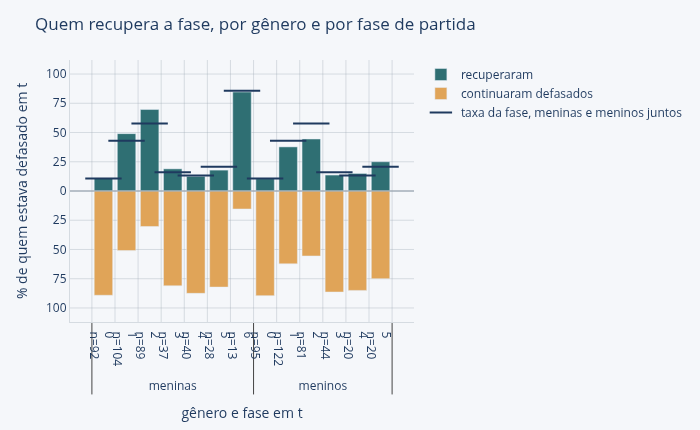

In [9]:
# A fase aqui é a de partida, em t — a convenção de riscos, detalhada na docstring da função. O gráfico
# abaixo segue o mesmo eixo, para poder ser lido junto com a tabela; o gráfico por fase de chegada, lá no
# começo da P1, responde a outra pergunta: como se compõe a turma que chegou a cada fase.
pg = p1.dropna(subset=['genero'])
print('Taxas condicionais por gênero:')
print(pg.groupby('genero').apply(riscos, include_groups=False).round(1).to_string())

print('\nAs mesmas taxas por fase de partida:')
print(pg.groupby(['fase', 'genero']).apply(riscos, include_groups=False).round(1).to_string())

gen = pg.assign(recuperou=~pg.defasado_t1.astype(bool), caiu=pg.defasado_t1.astype(bool))

# Onde mora a diferença agregada. Tirando as fases 1 e 2, a vantagem das meninas na recuperação desaparece,
# mas o risco de se defasar continua desigual — e boa parte dele é reflexo de onde cada grupo está, não do
# gênero, o que a segunda tabela mostra pondo lado a lado a distribuição de quem começou em fase e o risco
# próprio de cada faixa de fase.
print('\nO mesmo agregado, sem as fases 1 e 2:')
print(gen[~gen.fase.isin([1, 2])].groupby('genero').apply(riscos, include_groups=False).round(1).to_string())

emf = gen[~gen.defasado.astype(bool)]
faixa = pd.cut(emf.fase, [-1, 1, 2, 99], labels=['fases 0 e 1', 'fase 2', 'fase 3 em diante'])
onde = emf.groupby([faixa, 'genero'], observed=True).size().unstack()
print('\nOnde estava quem começou em fase, e o risco próprio de cada faixa:')
print(pd.DataFrame({'meninas_%': onde.Fem / onde.Fem.sum() * 100,
                    'meninos_%': onde.Masc / onde.Masc.sum() * 100,
                    'defasaram_%': emf.groupby(faixa, observed=True).caiu.mean() * 100}).round(1).to_string())

# Os alunos por trás das duas fases que a tabela por fase destaca, para deixar à vista de quantas pessoas se
# está falando em cada porcentagem.
det = pd.concat([gen[gen.fase.eq(2) & gen.defasado.astype(bool)].assign(taxa='fase 2 · recuperaram',
                                                                        ok=lambda b: b.recuperou),
                 gen[gen.fase.eq(1) & ~gen.defasado.astype(bool)].assign(taxa='fase 1 · defasaram',
                                                                         ok=lambda b: b.caiu)])
print('\nOs alunos por trás das duas fases que mais chamam a atenção:')
print(det.groupby(['taxa', 'genero']).ok.agg(alunos='sum', no_grupo='size').to_string())

# Qual das diferenças por fase é grande o bastante para não ser oscilação de grupo pequeno. Isto não muda o
# que o gráfico mostra — ele desenha todas as fases —, serve para saber em qual delas vale a pena agir.
def diferenca_resiste(g, origem, desfecho):
    """
    Compara meninas e meninos dentro de uma fase, no grupo de origem indicado, e devolve o quanto da
    diferença observada ainda poderia vir só do acaso. Fases com menos de 10 alunos de um dos lados ficam de
    fora, porque abaixo disso não há como separar uma coisa da outra.
    """
    cel = [[s[desfecho].sum(), (~s[desfecho]).sum()] for _, s in g[origem(g)].groupby('genero')]
    return stats.fisher_exact(cel)[1] if len(cel) == 2 and min(map(sum, cel)) >= 10 else np.nan


acaso = pd.Series({(f, taxa): diferenca_resiste(s, origem, alvo) for f, s in gen.groupby('fase')
                   for taxa, origem, alvo in (('recuperação', lambda b: b.defasado.astype(bool), 'recuperou'),
                                              ('queda', lambda b: ~b.defasado.astype(bool), 'caiu'))}) \
          .dropna().sort_values()
# Desconta o efeito de olhar muitas fases de uma vez, que por si só já faz aparecer diferença onde não há.
ajustado = (acaso * len(acaso) / np.arange(1, len(acaso) + 1))[::-1].cummin()[::-1]
resistem = [f'fase {f:g}, na {taxa}' for f, taxa in sorted(ajustado[ajustado < 0.10].index)]
print(f'\nDas {len(acaso)} comparações com alunos suficientes para comparar, a diferença entre meninas e '
      f'meninos só resiste em: {"; ".join(resistem)}.')


def recuperacao_por_genero(base, titulo, altura=430):
    """
    Desenha a taxa de recuperação por gênero em cada fase de partida. O traço que aparece em cada par [fase, gênero]
    marca a taxa da fase com os dois gêneros juntos: é ele que nos ajuda a identificar quando um grupo vai melhor que a
    média e outro vai pior.

    Pares com menos de dez alunos defasados em t ficam de fora, e os que saem são listados antes do gráfico. É o
    mesmo mínimo já usado no controle por fase da seção anterior — o MIN_CELULA das ferramentas de leitura —, e
    existe porque uma taxa sobre meia dúzia de alunos desenha a barra mais alta do gráfico sem ter mais
    conteúdo que o acaso do grupo pequeno.
    """
    de = base[base.defasado.astype(bool)]
    tab = de.groupby(['genero', 'fase']).recuperou.agg(rec='sum', n='size').query('n > 0')
    fora = tab[tab.n < 10]
    if len(fora):
        print(f'Fora do gráfico, por terem menos de 10 alunos defasados em t: '
              f'{", ".join(f"{g}/fase {f:g} (n={n})" for (g, f), n in zip(fora.index, fora.n))}.')
    tab = tab[tab.n >= 10]
    tab['pct'] = tab.rec / tab.n * 100
    fase_toda = de.groupby('fase').recuperou.mean().mul(100)
    eixo = [tab.index.get_level_values('genero').map({'Fem': 'meninas', 'Masc': 'meninos'}).tolist(),
            rotulo_n([f'{f:g}' for _, f in tab.index], tab.n)]
    fig = go.Figure()
    for nome, cor, sentido, pct in [('recuperaram', TEAL, 1, tab.pct),
                                    ('continuaram defasados', AMBAR, -1, 100 - tab.pct)]:
        dados, modelo = hover_taxa(pct, (pct / 100 * tab.n).round(), tab.n)
        fig.add_bar(x=eixo, y=sentido * pct, name=nome, marker_color=cor,
                    customdata=dados, hovertemplate=modelo)
    # O traço sai em azul, que não é a cor de nenhuma das duas barras: no tom de uma delas ele desapareceria
    # dentro da barra a que se refere.
    marca_referencia(fig, eixo, tab.index.get_level_values('fase').map(fase_toda),
                     'taxa da fase, meninas e meninos juntos', formato='.1f')
    fig.update_layout(barmode='relative', title=titulo, xaxis_title='gênero e fase em t',
                      yaxis_title='% de quem estava defasado em t', hovermode='x unified', legend_title='')
    # A escala fecha nos 100% dos dois lados porque as duas séries são complementares dentro de cada barra.
    eixo_divergente(fig, [100], 25)
    return aplicar_tema(fig, altura).update_layout(margin_b=90)


recuperacao_por_genero(gen, 'Quem recupera a fase, por gênero e por fase de partida').show()


A tabela nos mostra que, em geral, as meninas se recuperam mais da defasagem do que os meninos (38,1% contra
30,2%), além de correrem menos risco de entrarem em defasagem (22,9% contra 34,2%). As duas diferenças, no
entanto, têm origens distintas.

A vantagem na recuperação é inteiramente localizada nas fases 1 e 2: fora delas, meninas e meninos recuperam
na mesma medida — 19,9% contra 19,6%. Já a diferença no risco de se defasar está espalhada por todas as fases
e continua de pé mesmo sem as duas (24,0% contra 33,1%). Boa parte dela, porém, é reflexo de onde cada grupo
está, e não do gênero: 42,7% dos meninos que estavam em fase se encontravam nas fases 0 e 1, em que mais da
metade dos alunos se defasa no ano seguinte, contra 31,8% das meninas; e 51,7% das meninas estavam da fase 3
em diante, em que o risco cai para um em cada dez, contra 36,4% dos meninos.

Das diferenças por fase, uma se destaca por ser grande e por estar apoiada em alunos suficientes: na fase 2, as
meninas que estavam defasadas recuperam a fase em 69,7% dos casos (62 de 89) contra 44,4% dos meninos (36 de
81). A fase 1 chama a atenção na outra taxa da tabela, a de quem estava em fase e se defasou: 66,7% dos
meninos contra 40,7% das meninas. Mas ali são 27 alunos de cada lado, e a diferença inteira são 7 deles:
18 meninos contra 11 meninas. Meia dúzia de
casos bastaria para virá-la do avesso, então não dá para tratá-la como achado.

Ou seja, não é que os meninos vão pior de modo geral. O que os dados sustentam é um gargalo específico na fase
2, e é assim, como um gargalo de uma fase, que o gênero deve entrar no desenho de uma intervenção.


**Conclusão da P1:** o Programa de Aceleração do Conhecimento realmente reverte a defasagem dos alunos, sendo a
transição de 2023->2024 melhor que de 2022->2023 em quase todas as fases. O efeito, porém, não é uniforme — e onde
ele está depende de qual das duas leituras se faz. Pela fase de **chegada**, os alunos recuperados se acumulam nas
fases 2 e 3, que é o que o gráfico do começo da seção mostra. Pela fase de **partida**, que é a única que fecha o
grupo antes do desfecho acontecer, o quadro é outro: quem menos recupera são os alunos que estavam nas fases 0 e 3.
As duas leituras não se contradizem, porque respondem a perguntas diferentes; o que decide onde agir é a segunda.

As desagregações nos trazem novas informações sobre o tema da defasagem ao nos mostrar para quais grupos o problema é
pior, o que sugere três frentes de atuação para a associação:

1. Proteger o primeiro ano de vínculo, em que 50,7% dos alunos que estavam em fase se defasam, contra 10,8% dos demais.
2. Concentrar esforços nas fases 0 e 3, que são, pela fase de partida, as duas em que a recuperação quase não acontece. Dos alunos defasados na fase 0 em t, recuperaram a fase ideal no ano seguinte apenas 8,9% dos ingressantes e 12,8% dos veteranos; na fase 3, 16,7% e 15,8%. As fases 1 e 2, por outro lado, são as que mais revertem defasagem: 41,8% e 43,5% na fase 1, 47,1% e 62,2% na fase 2.
3. Priorizar os meninos na fase 2: atualmente, quando estão defasados e nessa fase, eles se recuperam bem menos que as meninas (44,4% contra 69,7%). Na fase 1 a diferença aparente é ainda maior, mas repousa sobre apenas 27 alunos, dos quais 7 representam uma proporção muito grande.


## P2 — O desempenho acadêmico (IDA) está melhorando, estagnado ou caindo?

O IDA (Indicador de Desempenho Acadêmico) mede o desempenho em Matemática e Português em todas as fases e, a
partir da fase 3, também em inglês.

Uma vez calculada a variação e suas tendências, duas explicações concorrentes são testadas: a primeira é que o avanço de fase faz com que os alunos passem a ser avaliados com um conteúdo mais difícil, e o IDA cair pode não significar que
aprendeu menos; a segunda é que a adição do inglês no cálculo do IDA a partir da fase 3 afeta as variações por introduzir um novo componente ao cálculo do indicador.

Fase 8 fora das duas camadas: 127 linhas, 1 com IDA e 0 com INDE.
Ficam 2865 linhas nas fases 0 a 7, das quais 14 sem IDA.

IDA médio de quem está na base em cada ano:
      media     n
ano              
2022   6.09   860
2023   6.66   937
2024   6.35  1054

IDA no próprio ano, separando quem voltou no ano seguinte de quem não voltou:
             media    n
ano  evadiu            
2022 False    6.47  600
     True     5.23  260
2023 False    6.83  693
     True     6.20  244

Alta de 2022 para 2023 contando todo mundo: +0.57 (6.09 → 6.66)
A mesma alta contando só quem voltou no ano seguinte: +0.36 (6.47 → 6.83)
Parte da alta que vem de quem saiu, e não de quem ficou: 37.2%


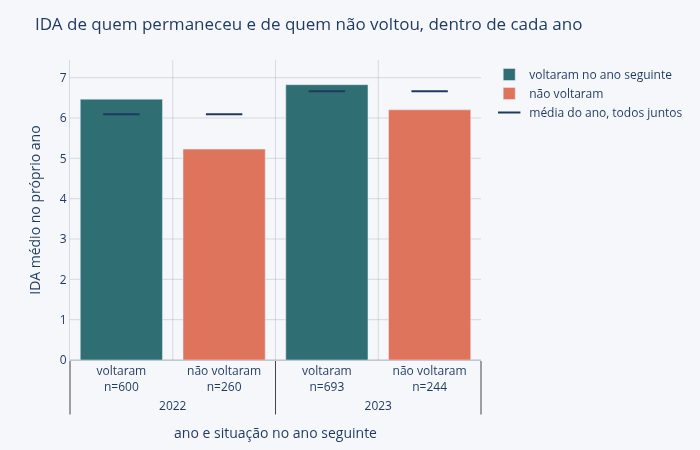

In [10]:
d2 = df[df.fase <= 7]
print(f'Fase 8 fora das duas camadas: {(df.fase == 8).sum()} linhas, '
      f'{df[df.fase == 8].ida.notna().sum()} com IDA e {df[df.fase == 8].inde.notna().sum()} com INDE.')
print(f'Ficam {len(d2)} linhas nas fases 0 a 7, das quais {d2.ida.isna().sum()} sem IDA.')

anual = d2.groupby('ano').ida.agg(media='mean', n='count')
print('\nIDA médio de quem está na base em cada ano:')
print(anual.round(2).to_string())

# Se a média anual se move por composição, a diferença tem que aparecer em quem deixa o programa. Comparo,
# dentro do mesmo ano, o IDA de quem voltou na avaliação seguinte com o de quem não voltou. A base de evasão
# só sabe responder isso para 2022 e 2023: para 2024 não existe ano seguinte onde procurar o aluno.
m2 = d2.merge(ev.rename(columns={'ano_referencia': 'ano'})[['id_aluno', 'ano', 'evadiu']],
              on=['id_aluno', 'ano'])
saida = m2.groupby(['ano', 'evadiu']).ida.agg(media='mean', n='count')
print('\nIDA no próprio ano, separando quem voltou no ano seguinte de quem não voltou:')
print(saida.round(2).to_string())

# A conta que interessa: quanto da alta de 2022 para 2023 sobra quando os dois anos são medidos só sobre
# quem permaneceu, isto é, quando a saída dos alunos com nota mais baixa deixa de empurrar a média.
todos, ficaram = m2.groupby('ano').ida.mean(), m2[~m2.evadiu].groupby('ano').ida.mean()
a0, a1 = todos.index.min(), todos.index.max()
print(f'\nAlta de {a0} para {a1} contando todo mundo: {todos[a1] - todos[a0]:+.2f} '
      f'({todos[a0]:.2f} → {todos[a1]:.2f})')
print(f'A mesma alta contando só quem voltou no ano seguinte: {ficaram[a1] - ficaram[a0]:+.2f} '
      f'({ficaram[a0]:.2f} → {ficaram[a1]:.2f})')
print(f'Parte da alta que vem de quem saiu, e não de quem ficou: '
      f'{1 - (ficaram[a1] - ficaram[a0]) / (todos[a1] - todos[a0]):.1%}')


def ida_por_saida(tab, anual, titulo):
    """Desenha o IDA médio do ano separando quem voltou na avaliação seguinte de quem não voltou, com a
    média do ano inteiro marcada por cima. O denominador aqui é o ano, não o grupo: a pergunta é se a série
    anual se move porque os alunos mudaram ou porque mudou quem está sendo contado, e isso só fica visível
    quando as duas partes e o total dividem o mesmo eixo. A cor repete o que o rótulo já diz, de propósito."""
    eixo = [[f'{a}' for a, _ in tab.index],
            rotulo_n(['não voltaram' if e else 'voltaram' for _, e in tab.index], tab.n)]
    fig = go.Figure()
    for saiu, cor, nome in [(False, TEAL, 'voltaram no ano seguinte'), (True, CORAL, 'não voltaram')]:
        fig.add_bar(x=eixo, y=[v if e == saiu else None for (_, e), v in zip(tab.index, tab.media)],
                    marker_color=cor, name=nome,
                    customdata=np.stack([tab.media, tab.n], axis=-1),
                    hovertemplate='IDA %{customdata[0]:.2f}  ·  %{customdata[1]:.0f} alunos<extra></extra>')
    marca_referencia(fig, eixo, [anual.media[a] for a, _ in tab.index], 'média do ano, todos juntos')
    fig.update_layout(barmode='relative', title=titulo, xaxis_title='ano e situação no ano seguinte',
                      yaxis_title='IDA médio no próprio ano', hovermode='x unified', legend_title='')
    return aplicar_tema(fig, 450).update_layout(margin_b=85)


ida_por_saida(saida, anual, 'IDA de quem permaneceu e de quem não voltou, dentro de cada ano').show()


O IDA médio sobe de 6,09 em 2022 para 6,66 em 2023 e recua para 6,35 em 2024. Lida sozinha, a série sugeriria um
ano bom seguido de um ano ruim. Este é mais um exemplo do porquê é importante considerarmos a trajetória dos alunos em vez das médias anuais.

O gráfico separa, dentro de cada ano, quem voltou na avaliação seguinte de quem não voltou, e marca por cima, com um traço azul, a média do ano inteiro. Ele mostra o mecanismo funcionando: quem não voltou já tinha IDA mais baixo antes de evadir — 5,23 contra 6,47 em 2022 (260 alunos contra 600); e 6,20 contra 6,83 em 2023 (244 contra 693). A média do ano cai sempre entre as duas barras e mais perto da barra de quem ficou, que é o grupo maior. No ano seguinte, os que performaram pior (e evadiram) não estão mais na conta, o que por si pode fazer a média subir sem que o programa tenha se tornado mais eficiente.

Qual é a dimensão da diferença? A variação positiva do IDA médio em 2022->2023 é de +0,57 se considerarmos todos os alunos (inclusive novos ingressantes), mas de apenas +0,36 quando consideramos apenas os alunos que já estavam na instituição. Ou seja, 37,2% da variação positiva (+0,21) vem somente da remoção das notas baixas de alunos que evadiram.

Transições no painel: 1365. Sem variação de IDA: 109 — 78 chegam na fase 8 e 31 não têm IDA numa das pontas.
Fora também o único aluno que chega na fase 8 com IDA registrado. População da camada longitudinal: 1255 transições, 820 alunos.

Variação do IDA dentro do mesmo aluno:
transição    n  melhoraram  iguais  pioraram  melhoraram_%  média  mediana
2022→2023  574         268      21       285         46.69   0.12     0.00
2023→2024  681         288       5       388         42.29  -0.48    -0.30
    todos 1255         556      26       673         44.30  -0.21    -0.17

Dos 820 alunos, 435 aparecem nas duas transições.

Δ IDA por transição e fase de chegada:
                   media    n  melhoraram  melhoraram_%
transicao fase_t1                                      
2022→2023 0.0       0.19   77          41         53.25
          1.0       0.17  116          61         52.59
          2.0       0.26  129          61         47.29
          3.0       0.12  103          54         5

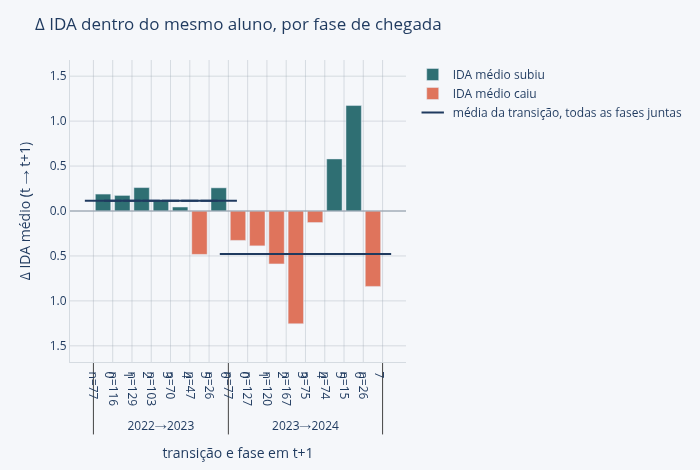

In [11]:
# ---------- Camada longitudinal: o mesmo aluno em t e em t+1 ----------
b2 = painel.dropna(subset=['d_ida'])
fora = painel[painel.d_ida.isna()]
print(f'Transições no painel: {len(painel)}. Sem variação de IDA: {len(fora)} '
      f'— {(fora.fase_t1 == 8).sum()} chegam na fase 8 e {(fora.fase_t1 != 8).sum()} não têm IDA numa das '
      f'pontas.')
b2 = b2[b2.fase_t1 <= 7]
print(f'Fora também o único aluno que chega na fase 8 com IDA registrado. '
      f'População da camada longitudinal: {len(b2)} transições, {b2.id_aluno.nunique()} alunos.')

# Contagem antes de taxa: quantos melhoraram e quantos pioraram
linhas = []
for nome, g in list(b2.groupby('transicao')) + [('todos', b2)]:
    linhas.append((nome, len(g), (g.d_ida > 0).sum(), (g.d_ida == 0).sum(), (g.d_ida < 0).sum(),
                   (g.d_ida > 0).mean() * 100, g.d_ida.mean(), g.d_ida.median()))
print('\nVariação do IDA dentro do mesmo aluno:')
print(pd.DataFrame(linhas, columns=['transição', 'n', 'melhoraram', 'iguais', 'pioraram', 'melhoraram_%',
                                    'média', 'mediana']).round(2).to_string(index=False))
# A linha 'todos' conta duas vezes quem aparece nas duas transições, então ela é resumo e não população.
print(f"\nDos {b2.id_aluno.nunique()} alunos, "
      f"{(b2.groupby('id_aluno').size() == 2).sum()} aparecem nas duas transições.")

por_fase = b2.groupby(['transicao', 'fase_t1']).d_ida.agg(
    media='mean', n='size', melhoraram=lambda s: (s > 0).sum())
por_fase['melhoraram_%'] = por_fase.melhoraram / por_fase.n * 100
print('\nΔ IDA por transição e fase de chegada:')
print(por_fase.round(2).to_string())
finas = por_fase[por_fase.n < MIN_CELULA]
print(f'\nFora do gráfico, por terem menos de {MIN_CELULA} alunos: '
      + (', '.join(f'{t} fase {f:g} (n={v})' for (t, f), v in finas.n.items()) or 'nenhuma célula') + '.')


def barras_variacao(tab, titulo, eixo_x, rotulo_y, nomes=('subiu', 'caiu'), passo=0.5, casas=1,
                    altura=470, referencia=None, nome_ref=''):
    """Desenha a variação média de cada grupo como barra que diverge do zero: para cima quem melhorou, para
    baixo quem piorou. O sinal é a primeira coisa que a pergunta pede, e divergir entrega o sinal antes de o
    leitor chegar ao eixo; o rótulo do eixo, por isso mesmo, mostra o valor absoluto. O n vai no rótulo e o
    hover leva a média, o tamanho do grupo e quantos melhoraram, para que nenhuma barra seja lida sem o peso
    que ela tem — uma média de seis alunos e uma de duzentos ocupam a mesma largura na tela."""
    rot = lambda v: f'{v:g}' if isinstance(v, float) else str(v)
    eixo = [[rot(v) for v in tab.index.get_level_values(i)] for i in range(tab.index.nlevels)]
    eixo[-1] = rotulo_n(eixo[-1], tab.n)
    x = eixo if tab.index.nlevels > 1 else eixo[0]
    dados = np.stack([tab.media, tab.n, tab['melhoraram_%']], axis=-1)
    fig = go.Figure()
    for acima, cor, nome in [(True, TEAL, nomes[0]), (False, CORAL, nomes[1])]:
        fig.add_bar(x=x, y=[v if (v > 0) == acima else None for v in tab.media], marker_color=cor,
                    name=nome, customdata=dados,
                    hovertemplate='%{customdata[0]:+.2f} em média  ·  %{customdata[1]:.0f} alunos  ·  '
                                  '%{customdata[2]:.0f}% melhoraram<extra></extra>')
    if referencia is not None:
        marca_referencia(fig, x, list(referencia), nome_ref, formato='+.2f')
    fig.update_layout(barmode='relative', title=titulo, xaxis_title=eixo_x, yaxis_title=rotulo_y,
                      hovermode='x unified', legend_title='')
    eixo_divergente(fig, list(tab.media) + list(referencia if referencia is not None else []), passo, casas)
    return aplicar_tema(fig, altura).update_layout(margin_b=85 if tab.index.nlevels > 1 else 55)


grosso = por_fase[por_fase.n >= MIN_CELULA]
media_transicao = b2.groupby('transicao').d_ida.mean()
barras_variacao(grosso, 'Δ IDA dentro do mesmo aluno, por fase de chegada',
                'transição e fase em t+1', 'Δ IDA médio (t → t+1)',
                nomes=('IDA médio subiu', 'IDA médio caiu'),
                referencia=[media_transicao[t] for t, _ in grosso.index],
                nome_ref='média da transição, todas as fases juntas').show()


Ao acompanharmos a trajetória dos alunos em vez de considerar as médias anuais, fica ainda mais claro como estas não são boas medidas de análise: em 2022→2023, 268 dos 574 alunos melhoraram e 285 pioraram — quase um empate — com média de variaçao do IDA de +0,12 e mediana zero; em 2023→2024, 288 melhoraram e 388 pioraram, e a média de variação cai para −0,48. Ou seja, vemos que o que a série anual apontava como um ano de melhoria do IDA, na verdade, foi um ano de piora se considerarmos os alunos que **já vinham do programa**.

O gráfico traz ainda mais detalhes ao desagregar essa variação por fase de **chegada** do aluno — isto é, a fase em t+1. Podemos ver que, em 2022→2023, embora as variações fossem pequenas (barras curtas), elas foram quase todas positivas (barras acima do eixo x). Já em 2023→2024, vemos não apenas uma grande deterioração do ida médio, mas também que ela ocorreu intensamente em fases com grandes grupos amostrais — a variação positiva na fase 6, por exemplo, não tem tanto peso, uma vez que inclui apenas 15 alunos.

Uma queda desse tamanho no IDA gera perguntas sobre o que pode tê-la causado. A seguir, avalio as duas explicações candidatas apresentadas no início desta seção: a dificuldade natural pelo avanço de fase e a inclusão do inglês no cálculo do indicador a partir da fase 3.

Rótulo 'permaneceu na fase': 377 ficaram na mesma fase e 1 regrediram — o rótulo descreve o grupo, com essa exceção.

Δ IDA por transição e situação de fase:
                              media  mediana    n  melhoraram  melhoraram_%
transicao situacao                                                         
2022→2023 avançou de fase     -0.26    -0.30  377         132         35.01
          permaneceu na fase   0.84     1.00  197         136         69.04
2023→2024 avançou de fase     -0.74    -0.50  500         188         37.60
          permaneceu na fase   0.26     0.35  181         100         55.25

Quantos avançaram de fase em cada transição:
           avançaram    n     %
transicao                      
2022→2023        377  574  65.7
2023→2024        500  681  73.4

IDA médio de partida de cada grupo, no ano t:
situacao   avançou de fase  permaneceu na fase
transicao                                     
2022→2023             6.71                6.07
2023→2024             7.

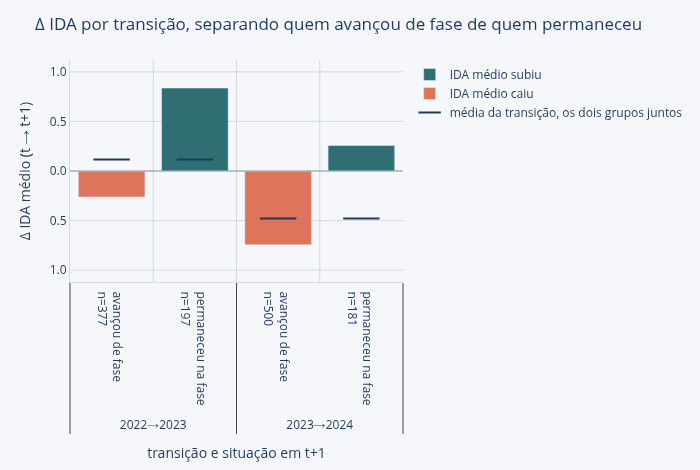

In [12]:
# ---------- Primeira explicação candidata: o avanço de fase ----------
# Avançar significa passar a ser avaliado em conteúdo mais difícil, então o IDA cair não é necessariamente
# ter aprendido menos. Se a explicação bastar, a piora de uma transição para a outra deve vir de terem
# promovido mais alunos — e isso é uma conta, não uma impressão.
b2 = b2.assign(situacao=np.where(b2.avancou, 'avançou de fase', 'permaneceu na fase'))
nao = b2[~b2.avancou]
print(f"Rótulo 'permaneceu na fase': {(nao.fase_t1 == nao.fase).sum()} ficaram na mesma fase e "
      f'{(nao.fase_t1 < nao.fase).sum()} regrediram — o rótulo descreve o grupo, com essa exceção.')

avanco = b2.groupby(['transicao', 'situacao']).d_ida.agg(
    media='mean', mediana='median', n='size', melhoraram=lambda s: (s > 0).sum())
avanco['melhoraram_%'] = avanco.melhoraram / avanco.n * 100
print('\nΔ IDA por transição e situação de fase:')
print(avanco.round(2).to_string())

promovidos = b2.groupby('transicao').avancou.agg(avançaram='sum', n='size')
promovidos['%'] = promovidos.avançaram / promovidos.n * 100
print('\nQuantos avançaram de fase em cada transição:')
print(promovidos.round(1).to_string())

# Os dois grupos não partem do mesmo lugar, e o número fica registrado aqui porque a leitura precisa dizer o
# que ela não está medindo. O efeito do patamar de partida sobre a variação seguinte não é uma questão do IDA:
# vale para qualquer indicador medido duas vezes, e por isso é tratado uma vez só, na P11.
print('\nIDA médio de partida de cada grupo, no ano t:')
print(b2.groupby(['transicao', 'situacao']).ida.mean().unstack().round(2).to_string())

# Se a queda fosse só efeito de terem promovido mais gente, trocar a proporção de promovidos de uma
# transição pela da outra, mantendo a média de cada grupo, já reproduziria a queda inteira. Faço as duas
# contas separadas: mudando só a mistura dos grupos e mudando só o desempenho dentro de cada grupo.
m = avanco.media.unstack()
peso = avanco.n.unstack()
peso = peso.div(peso.sum(axis=1), axis=0)
t0, t1 = m.index[0], m.index[-1]
real = {t: float((m.loc[t] * peso.loc[t]).sum()) for t in (t0, t1)}
so_mistura = float((m.loc[t0] * peso.loc[t1]).sum())
so_desempenho = float((m.loc[t1] * peso.loc[t0]).sum())
total = real[t1] - real[t0]
print(f'\nMédia da transição: {t0} {real[t0]:+.2f} → {t1} {real[t1]:+.2f}, variação {total:+.2f}')
print(f'  mudando só a mistura (médias de {t0}, proporção de {t1}): {so_mistura:+.2f} '
      f'→ explica {so_mistura - real[t0]:+.2f}, {(so_mistura - real[t0]) / total:.0%} da queda')
print(f'  mudando só o desempenho (médias de {t1}, proporção de {t0}): {so_desempenho:+.2f} '
      f'→ explica {so_desempenho - real[t0]:+.2f}, {(so_desempenho - real[t0]) / total:.0%} da queda')
# Os dois pedaços não somam o total sozinhos porque mudam ao mesmo tempo: o resíduo é o quanto disso é
# cruzamento dos dois. Ele entra impresso para que a soma feche e ninguém precise confiar na aritmética.
print(f'  os dois pedaços se cruzam em '
      f'{total - (so_mistura - real[t0]) - (so_desempenho - real[t0]):+.2f}, fechando os {total:+.2f}')

barras_variacao(avanco, 'Δ IDA por transição, separando quem avançou de fase de quem permaneceu',
                'transição e situação em t+1', 'Δ IDA médio (t → t+1)',
                nomes=('IDA médio subiu', 'IDA médio caiu'),
                referencia=[media_transicao[t] for t, _ in avanco.index],
                nome_ref='média da transição, os dois grupos juntos').show()


Podemos observar que, de fato, nas duas transições (2022->2023 e 2023->2024), o grupo que avançou de fase piorou e o grupo que permaneceu na antiga melhorou com relação ao IDA. Em 2022→2023, quem avançou perdeu 0,26 ponto em média (377 alunos) enquanto quem permaneceu ganhou 0,84 (197 alunos); em 2023→2024, −0,74 contra +0,26 (500 e 181).

É importante observarmos que a proporção de promovidos subiu de uma transição para a outra: de 65,7% em 2022→2023 para 73,4% em 2023→2024. Como o grupo cujo IDA cai ficou maior, parte da queda geral que observamos na segunda transição se origina daí. Essa parte, no entanto, não se revela significativa: ela responde apenas por 9% da queda observada. Isso foi calculado da seguinte forma:
1. Já estabelecemos anteriormente que a variação média geral do IDA vai de +0,12 em 2022->2023 para −0,48 em 2023->2024, uma queda de 0,59.
2. Congelando o desempenho de cada grupo e trocando apenas a proporção entre eles, observasmos que a variação média teria ido para +0,03. Ou seja, inverter a proporção de alunos promovidos em cada transição causaria uma queda de apenas 0,09 (14% da observada).
3. Congelando a proporção dos alunos promovidos em cada transição e trocando apenas o desempenho de cada grupo, o
movimento observado é de 0,52 (87% da queda observada).

Uma coisa que não foi considerada nesta comparação: os dois grupos não partem do mesmo patamar — quem avançou tinha IDA médio de 6,71 contra 6,07 de quem permaneceu em 2022→2023, e 7,00 contra 6,31 em 2023→2024. Como a promoção é decidida olhando a nota, isso era esperado. O quanto o patamar de partida afeta a variação seguinte, no entanto, é uma pergunta que se aplica a todos os indicadores e, por isso, está respondida em P11.

In [13]:
# ---------- Segunda explicação candidata: a régua ----------
# O inglês entra no IDA a partir da fase 3, e quem avança de fase é justamente quem cruza essa fronteira. Se
# a queda dos promovidos for a média passando a incluir uma matéria nova, ela é da régua e não do aluno. Duas
# checagens bastam: para que lado o inglês puxa a média, e o que sobra do resultado da célula anterior quando
# as duas pontas são medidas só por matemática e português, que é uma régua constante.

# mat/port/ing não estão no painel da P1, que só carrega os indicadores, então vêm da base.
notas = df[['id_aluno', 'ano', 'mat', 'port', 'ing']]
med = (b2.merge(notas, on=['id_aluno', 'ano'], how='left')
         .merge(notas.assign(ano=notas.ano - 1), on=['id_aluno', 'ano'], how='left', suffixes=('', '_t1')))
med['entrou_ing'] = med.ing_t1.notna() & med.ing.isna()
print(f'Transições em que o inglês passa a entrar na média: {med.entrou_ing.sum()} de {len(med)} — '
      f'{(med.entrou_ing & (med.fase == 2)).sum()} delas saindo da fase 2, onde fica a fronteira, e '
      f'{(med.entrou_ing & med.avancou).sum()} são de quem avançou de fase.')

# A régua nova é mais generosa, não mais dura: entre quem tem as três matérias, o inglês é a nota mais alta.
tres = df[(df.fase <= 7) & df[['mat', 'port', 'ing']].notna().all(axis=1)]
mp_tres = tres[['mat', 'port']].mean(axis=1)
print(f'\nNas {len(tres)} linhas com as três matérias, inglês {tres.ing.mean():.2f} contra '
      f'{mp_tres.mean():.2f} de mat/port: incluir o inglês sobe a média em '
      f'{tres.ida.mean() - mp_tres.mean():+.2f}, então ele não é o que puxa o IDA para baixo.')

# O teste que fecha a questão: refazer a comparação da célula anterior medindo só matemática e português nos
# dois anos. A régua fica constante, e o resultado da seção não pode se apoiar na troca de matérias.
so_mp = df[['id_aluno', 'ano', 'fase']].assign(mp=df[['mat', 'port']].mean(axis=1))
pmp = so_mp.merge(so_mp.assign(ano=so_mp.ano - 1), on=['id_aluno', 'ano'], suffixes=('', '_t1'))
pmp = pmp[pmp.fase_t1 <= 7].dropna(subset=['mp', 'mp_t1']).assign(
    d=lambda t: t.mp_t1 - t.mp,
    situacao=lambda t: np.where(t.fase_t1 > t.fase, 'avançou de fase', 'permaneceu na fase'),
    transicao=lambda t: t.ano.astype(str) + '→' + (t.ano + 1).astype(str))
print(f'\nMedindo só matemática e português nos dois anos ({len(pmp)} transições):')
print(pmp.groupby(['transicao', 'situacao']).d.agg(media='mean', n='size').round(2).to_string())

Transições em que o inglês passa a entrar na média: 235 de 1255 — 220 delas saindo da fase 2, onde fica a fronteira, e 225 são de quem avançou de fase.

Nas 1085 linhas com as três matérias, inglês 6.30 contra 5.67 de mat/port: incluir o inglês sobe a média em +0.21, então ele não é o que puxa o IDA para baixo.

Medindo só matemática e português nos dois anos (1255 transições):
                              media    n
transicao situacao                      
2022→2023 avançou de fase     -0.22  377
          permaneceu na fase   0.82  197
2023→2024 avançou de fase     -0.91  500
          permaneceu na fase   0.15  181


A segunda explicação candidata é a régua, e ela merece checagem porque a fronteira do inglês fica exatamente onde
está o grupo que interessa: das 1.255 transições, 235 passam a incluir inglês na média — 220 delas saindo da fase
2, onde fica a fronteira, e 225 são de alunos que avançaram de fase. Se a matéria nova fosse mais difícil, a queda
dos promovidos poderia ser só isso. No entanto, é mais fácil atingir notas altas no inglês do que no português e na matemática: nas 1.085 linhas com as três matérias, o inglês tem média 6,30 contra 5,67 de matemática e português — incluí-lo, na verdade, faz o IDA subir em 0,21. A régua nova favorece o grupo que avança para a fase 3 e, ainda assim, é ele cuja performance cai. Ou seja, a inclusão do inglês no cálculo do IDA não explica sua queda.

### Resposta da P2

**O IDA não está melhorando.** Medido dentro do grupo de alunos que já faziam parte da associação no ano anterior, ele não avança em 2022→2023 (variação média +0,12 e mediana 0,00) e, 2023→2024, recua (variação média de −0,48 e mediana de −0,30). A série anual sugere o contrário porque conta alunos diferentes a cada ano: 37,2% da alta de 2022 para 2023 vem simplesmente da exclusão dos IDAs baixos de que deixou o programa.

Como vimos, duas explicações foram testadas antes de apresentarmos uma conclusão e nenhuma delas duas explica a queda. A queda em quem avança de fase de fato acontece, mas explica apenas 14% da variação. Aém, diso, a nova régua de cálculo do IDA a partir da fase 3 também não explica sua queda.


A partir dos dados, não conseguimos explicar por que o desempenho caiu. O fato, no entanto, é que caiu.

**Sugestões:**

1. **Blindar o ano seguinte à promoção.** Quem avança de fase perde IDA nas duas transições, e a perda piorou
   (−0,26 para −0,74). Promover mais alunos é justamente o que a P1 mostra o programa fazendo bem; o que falta
   é o apoio no ano em que o conteúdo fica mais difícil.
2. **Não usar a média anual do IDA como indicador de resultado.** Embora ela tenha subido 0,57 entre 2022 e 2023, vimos que, na verdade, esse aumento veio das notas de novos alunos, enquanto os veteranos ficaram estagnados.

## P3 — Alunos mais engajados (IEG) apresentam melhor desempenho (IDA) e ponto de virada (IPV)?

O IEG (Indicador de Engajamento) resume entrega de tarefas, participação e presença. O IPV (Indicador de
Ponto de Virada) é a leitura dos professores sobre o quanto o aluno já mudou de patamar.

A pergunta importa porque o engajamento é das poucas coisas em que a associação consegue mexer diretamente.
Só que a foto de um ano — alunos mais engajados têm notas melhores — responderia igual se engajamento e
desempenho fossem apenas duas faces do mesmo aluno aplicado, e nesse caso não haveria alavanca nenhuma. Por
isso as duas camadas aparecem: primeiro a de nível, para ser confrontada, e depois a de variação, que é a
única que autoriza qualquer recomendação.

Uma explicação concorrente é testada junto: a P2 mostrou que quem avança de fase cai de IDA. Se a ligação
entre engajamento e desempenho fosse só o reflexo disso, ela deveria sumir quando promovidos e não
promovidos são olhados separadamente.

Esta seção não estabelece como o IEG se comporta ao lado dos outros indicadores, nem o que acontece com
essas associações quando as duas transições são empilhadas numa conta só. As duas coisas estão na P11.

Base da P3: 2851 das 3030 avaliações. Ficam de fora 127 da fase 8 e 14 sem IEG, IDA ou IPV medidos.

Correlação entre níveis, dentro do mesmo ano:
indicadores   ano  pearson  spearman    n
    IEG×IDA  2022     0.56      0.51  860
    IEG×IDA  2023     0.46      0.45  937
    IEG×IDA  2024     0.55      0.52 1054
    IEG×IDA todos     0.54      0.50 2851
    IEG×IPV  2022     0.59      0.54  860
    IEG×IPV  2023     0.45      0.49  937
    IEG×IPV  2024     0.54      0.55 1054
    IEG×IPV todos     0.56      0.55 2851

IDA e IPV médios por faixa de IEG:
            IDA médio  IPV médio    n
faixa                                
0,0 a 7,5        4.92       6.71  734
7,5 a 8,7        6.27       7.44  692
8,7 a 9,4        6.91       7.85  734
9,4 a 10,0       7.46       8.22  691


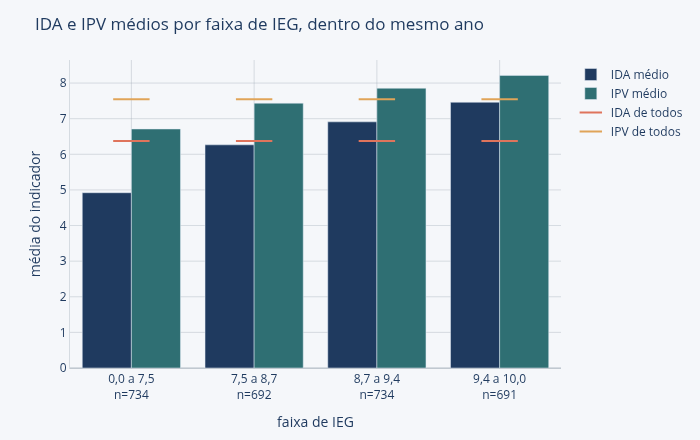

In [14]:
# ---------- Camada de nível: a foto que compara alunos diferentes ----------
def tabela_corr(pares, base=None):
    """Correlação entre dois indicadores no mesmo ano, por ano e no total. É a foto transversal, que compara
    alunos diferentes entre si, e entra como camada a ser confrontada, não como resposta: ela sobe do mesmo
    jeito se o engajamento puxa a nota e se as duas coisas forem apenas duas faces do mesmo aluno aplicado."""
    base = df if base is None else base
    linhas = []
    for x, y in pares:
        for ano, g in base.dropna(subset=[x, y]).groupby('ano'):
            linhas.append((f'{x.upper()}×{y.upper()}', ano, g[x].corr(g[y]),
                           g[x].corr(g[y], method='spearman'), len(g)))
        g = base.dropna(subset=[x, y])
        linhas.append((f'{x.upper()}×{y.upper()}', 'todos', g[x].corr(g[y]),
                       g[x].corr(g[y], method='spearman'), len(g)))
    return pd.DataFrame(linhas, columns=['indicadores', 'ano', 'pearson', 'spearman', 'n']).round(2)


# A seção fica nas fases 0 a 7 e só nas avaliações com os três indicadores medidos, para que o n escrito no
# rótulo valha para as duas barras que ele sustenta. O custo da restrição vai impresso: exclusão que não diz
# quantas linhas levou é indistinguível de descuido.
b3 = df[df.fase <= 7].dropna(subset=['ieg', 'ida', 'ipv'])
print(f'Base da P3: {len(b3)} das {len(df)} avaliações. Ficam de fora {(df.fase == 8).sum()} da fase 8 e '
      f'{len(df[df.fase <= 7]) - len(b3)} sem IEG, IDA ou IPV medidos.')
print('\nCorrelação entre níveis, dentro do mesmo ano:')
print(tabela_corr([('ieg', 'ida'), ('ieg', 'ipv')], b3).to_string(index=False))

faixa_ieg, _ = faixas_quartil(b3.ieg)
niv3 = b3.assign(faixa=faixa_ieg).groupby('faixa', observed=True)
medias3 = niv3[['ida', 'ipv']].mean().rename(columns={'ida': 'IDA médio', 'ipv': 'IPV médio'})
n3 = niv3.size()
print('\nIDA e IPV médios por faixa de IEG:')
print(pd.concat([medias3, n3.rename('n')], axis=1).round(2).to_string())

barras_nivel(medias3, n3, 'IDA e IPV médios por faixa de IEG, dentro do mesmo ano',
             'faixa de IEG', 'média do indicador',
             referencias={'IDA de todos': b3.ida.mean(), 'IPV de todos': b3.ipv.mean()}).show()

**Leitura da camada de nível.** Cada barra é a média de um grupo de alunos e o traço horizontal é a média de
todos: o que se lê é a distância de cada barra até o traço, não de uma barra até a vizinha. O quarto mais
engajado tem IDA médio 7,46 contra 4,92 do quarto menos engajado — dois pontos e meio numa escala de dez — e
o IPV acompanha, de 6,71 a 8,22. Medida como associação entre os dois indicadores, numa escala em que 0 é
nenhuma relação e 1 é relação perfeita, a ligação fica em 0,54 com o IDA e 0,56 com o IPV, e aparece nos três
anos (2023 é o mais fraco: 0,46 e 0,45).

É forte, e é aqui que o gráfico precisa parar de ser lido como resposta. Ele compara alunos diferentes entre
si, e por isso apareceria exatamente assim mesmo que engajamento e desempenho fossem apenas duas faces do
mesmo aluno aplicado. Nesse caso não haveria alavanca nenhuma: fazer quem entrega pouco entregar mais não o
transformaria no aluno da barra de cima. A pergunta que decide isso é outra — quando **o mesmo aluno** muda
de engajamento, o desempenho dele muda junto?

Transições com as três variações medidas: 1255 das 1365 do painel, 820 alunos.

Correlação entre variações do mesmo aluno, dentro de cada transição:
     variação transição  pearson    n
d_ieg × d_ida 2022→2023    0.268  574
d_ieg × d_ida 2023→2024    0.416  681
d_ieg × d_ida     todos    0.396 1255
d_ieg × d_ipv 2022→2023    0.258  574
d_ieg × d_ipv 2023→2024    0.299  681
d_ieg × d_ipv     todos    0.418 1255
d_ida × d_ipv 2022→2023    0.344  574
d_ida × d_ipv 2023→2024    0.377  681
d_ida × d_ipv     todos    0.392 1255

Dos 550 que aumentaram o IEG: 304 melhoraram o IDA (55.3%) e 319 melhoraram o IPV (58.0%).
Dos 663 que reduziram o IEG: 229 melhoraram o IDA (34.5%) e 206 melhoraram o IPV (31.1%).

A mesma correlação, separando quem avançou de fase de quem permaneceu:
transição           situação   n  Δ IEG × Δ IDA  Δ IEG × Δ IPV
2022→2023    avançou de fase 377           0.38           0.36
2022→2023 permaneceu na fase 197           0.14           0.12
2023→2024    avançou de fase

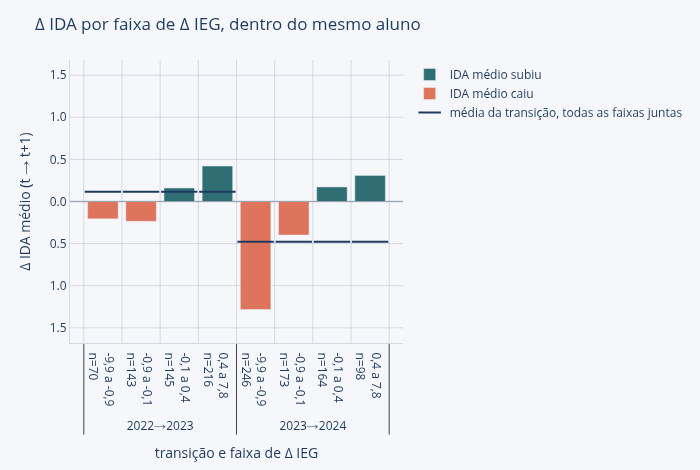


Δ IPV médio por transição e faixa de Δ IEG:
                       media    n  melhoraram  melhoraram_%
transicao faixa                                            
2022→2023 -9,9 a -0,9   0.22   70          40         57.14
          -0,9 a -0,1   0.39  143          86         60.14
          -0,1 a 0,4    0.55  145         104         71.72
          0,4 a 7,8     0.76  216         168         77.78
2023→2024 -9,9 a -0,9  -1.16  246          34         13.82
          -0,9 a -0,1  -0.68  173          41         23.70
          -0,1 a 0,4   -0.61  164          44         26.83
          0,4 a 7,8    -0.38   98          34         34.69
Fora do gráfico, por terem menos de 10 alunos: nenhuma célula.


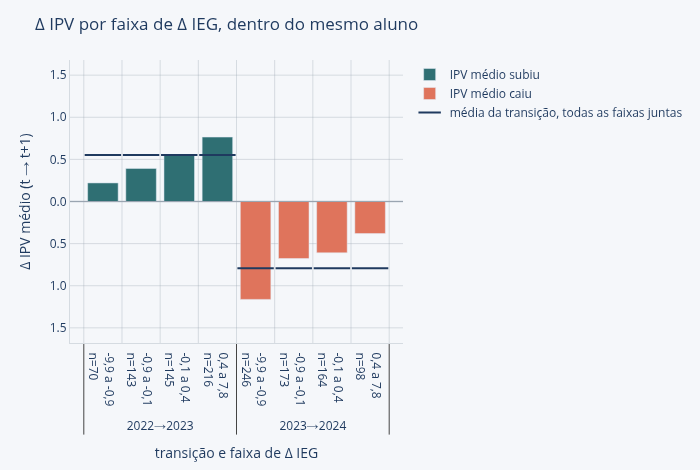

In [15]:
# ---------- Camada de variação: o mesmo aluno de um ano para o outro ----------
p3 = painel[painel.fase_t1 <= 7].dropna(subset=['d_ieg', 'd_ida', 'd_ipv'])
print(f'Transições com as três variações medidas: {len(p3)} das {len(painel)} do painel, '
      f'{p3.id_aluno.nunique()} alunos.')
print('\nCorrelação entre variações do mesmo aluno, dentro de cada transição:')
print(corr_por_par([('d_ieg', 'd_ida'), ('d_ieg', 'd_ipv'), ('d_ida', 'd_ipv')], p3)
      .drop(columns='p_valor').to_string(index=False))

# Contagem antes de taxa: de quem mexeu no engajamento, quantos de fato melhoraram do outro lado.
print()
for nome, g in [('aumentaram o IEG', p3[p3.d_ieg > 0]), ('reduziram o IEG', p3[p3.d_ieg < 0])]:
    print(f'Dos {len(g)} que {nome}: {(g.d_ida > 0).sum()} melhoraram o IDA '
          f'({(g.d_ida > 0).mean() * 100:.1f}%) e {(g.d_ipv > 0).sum()} melhoraram o IPV '
          f'({(g.d_ipv > 0).mean() * 100:.1f}%).')

# Explicação concorrente: a P2 mostrou que quem avança de fase cai de IDA. Se a ligação entre engajamento e
# desempenho fosse só o reflexo daquilo — o promovido se engaja menos e cai —, ela sumiria dentro de cada
# situação de fase, onde não há mais promovido e não promovido misturados.
p3 = p3.assign(situacao=np.where(p3.avancou, 'avançou de fase', 'permaneceu na fase'))
linhas3 = [(t, s, len(g), g.d_ieg.corr(g.d_ida), g.d_ieg.corr(g.d_ipv))
           for (t, s), g in p3.groupby(['transicao', 'situacao'])]
print('\nA mesma correlação, separando quem avançou de fase de quem permaneceu:')
print(pd.DataFrame(linhas3, columns=['transição', 'situação', 'n', 'Δ IEG × Δ IDA', 'Δ IEG × Δ IPV'])
      .round(2).to_string(index=False))

faixa_dieg, _ = faixas_quartil(p3.d_ieg)
p3f = p3.assign(faixa=faixa_dieg)
for alvo, rot in [('d_ida', 'IDA'), ('d_ipv', 'IPV')]:
    tab3 = p3f.groupby(['transicao', 'faixa'], observed=True)[alvo].agg(
        media='mean', n='size', melhoraram=lambda s: (s > 0).sum())
    tab3['melhoraram_%'] = tab3.melhoraram / tab3.n * 100
    grosso3 = tab3[tab3.n >= MIN_CELULA]
    finas3 = tab3[tab3.n < MIN_CELULA]
    print(f'\nΔ {rot} médio por transição e faixa de Δ IEG:')
    print(tab3.round(2).to_string())
    print(f'Fora do gráfico, por terem menos de {MIN_CELULA} alunos: '
          + (', '.join(f'{t} · {f}' for t, f in finas3.index) or 'nenhuma célula') + '.')
    ref3 = p3f.groupby('transicao')[alvo].mean()
    barras_variacao(grosso3, f'Δ {rot} por faixa de Δ IEG, dentro do mesmo aluno',
                    'transição e faixa de Δ IEG', f'Δ {rot} médio (t → t+1)',
                    nomes=(f'{rot} médio subiu', f'{rot} médio caiu'),
                    referencia=[ref3[t] for t, _ in grosso3.index],
                    nome_ref='média da transição, todas as faixas juntas').show()

**Leitura da camada de variação.** Agora cada aluno é comparado com ele mesmo. Dos 550 que aumentaram o IEG
de um ano para o outro, 304 melhoraram o IDA (55,3%) e 319 melhoraram o IPV (58,0%); dos 663 que reduziram o
IEG, só 229 melhoraram o IDA (34,5%) e 206 o IPV (31,1%). A diferença sobrevive à troca de unidade, que é o
teste que a camada anterior não passava.

Os gráficos mostram o tamanho dela. Nas duas transições o Δ IDA médio sobe de forma contínua conforme a faixa
de Δ IEG: de −0,21 a +0,42 em 2022→2023, e de −1,28 a +0,31 em 2023→2024. O Δ IPV desenha a mesma escada, em
alturas diferentes — em 2022→2023 todas as faixas sobem (+0,22 a +0,76) e em 2023→2024 todas caem (−1,16 a
−0,38). Vale ler devagar o que isso significa: em 2023→2024 nenhum grupo escapa da queda de IPV, mas quem
aumentou o engajamento cai cerca de um terço do que cai quem o reduziu. Onde o ano inteiro anda para trás,
engajamento não impede a queda; encurta a queda.

**A explicação concorrente.** A P2 mostrou que quem avança de fase perde IDA, e quem avança também muda de
turma, de professor e de rotina — a escada acima poderia ser aquele efeito disfarçado. A tabela separa os
dois grupos e o padrão continua nos dois: entre os promovidos, a ligação entre Δ IEG e Δ IDA é de 0,38 e
0,46; entre os que permaneceram na fase, de 0,14 e 0,29. Não é reflexo da promoção. E é mais forte
justamente entre os promovidos, que são o grupo onde a P2 localizou a maior queda de desempenho do período.

### Resposta da P3

**Sim — e a relação sobrevive ao teste que derruba a maior parte das leituras transversais deste relatório.**
Alunos mais engajados têm desempenho melhor, mas isso sozinho não autorizaria nada. O que autoriza é a
segunda camada: quando o mesmo aluno aumenta o engajamento, ele melhora mais em desempenho e em ponto de
virada do que quando o reduz — 55,3% contra 34,5% de melhora no IDA — e o efeito não some quando promovidos e
não promovidos são olhados separadamente.

**O que a seção não estabelece.** Que aumentar o IEG *cause* a melhora: um aluno que passa por um bom ano
melhora em tudo ao mesmo tempo, e nada aqui separa as duas coisas. Também não estabelece nada sobre o nível
absoluto de 2023→2024 — naquela transição o IPV cai em todas as faixas, e a leitura só vale como comparação
entre elas. Como o IEG conversa com os demais indicadores, e o que acontece quando as duas transições são
somadas numa conta só, ficam para a P11.

**Frentes:**

1. **Usar o IEG como termômetro de curto prazo.** É o único indicador da base que se mexe dentro do ano e
   anda junto com o desempenho do mesmo aluno. Queda de entrega e de presença é o aviso mais barato que a
   associação tem — e não depende de esperar o boletim.
2. **Reforçar entrega e presença no ano da promoção.** É onde a ligação é mais forte (0,46 em 2023→2024) e é
   exatamente o grupo que a P2 mostrou perdendo IDA ao mudar de fase.
3. **Não prometer recuperação por engajamento em ano de queda geral.** Em 2023→2024 o IPV caiu em todas as
   faixas de Δ IEG. O que o engajamento fez foi reduzir a queda a cerca de um terço, não revertê-la — e é
   isso que se pode prometer.

## P4 — A autoavaliação (IAA) dos alunos está alinhada com o desempenho real?

Antes de responder, é preciso tratar os zeros. O Relatório PEDE 2022 (p. 133) registra que, no indicador de
autoavaliação, **a nota zero significa a não participação do estudante, por escolha própria** — não é uma
nota baixa, é uma recusa. O `01_clean.py` preserva `iaa` como publicado, porque é dele que o INDE oficial é
reproduzível, e cria `iaa_val`, em que a recusa vira ausência, e `iaa_recusa`, que guarda o comportamento
como variável de análise.

A pergunta original só faz sentido depois disso, então a seção vai em quatro passos: o que o zero é de fato
e o que ele faz com a média do IAA; quanto a penalidade custa em INDE e em pedra; se recusar é, em si, um
sinal; e por fim a comparação entre autoavaliação e desempenho, já sem o ruído.

Recusa de autoavaliação e o efeito dela na média do IAA:
      recusas  avaliados  recusas_%  IAA com zeros  IAA sem recusas
ano                                                                
2022       39        860       4.53           8.27             8.67
2023      190        951      19.98           6.90             8.63
2024       20       1054        1.9           8.54             8.71

Campo do avaliador preenchido: 98.8% de quem recusou (246 de 249) contra 98.7% do resto (2581 de 2616); avaliações por aluno: 3.28 contra 3.13.

Outros indicadores de quem recusou e de quem respondeu — o INDE fica fora porque ele já
carrega o zero dentro de si, e conferir a penalidade com ela mesma não confere nada:
             ieg   ida   ipv
iaa_recusa                  
recusou     7.80  5.91  7.53
respondeu   8.27  6.42  7.55

Recusa por fase em 2023. A escola não serve para esta conferência: o campo só foi preenchido em 1155 das 1156 avaliações de 2024 e em nenhuma das de 2022 e 2023.
     

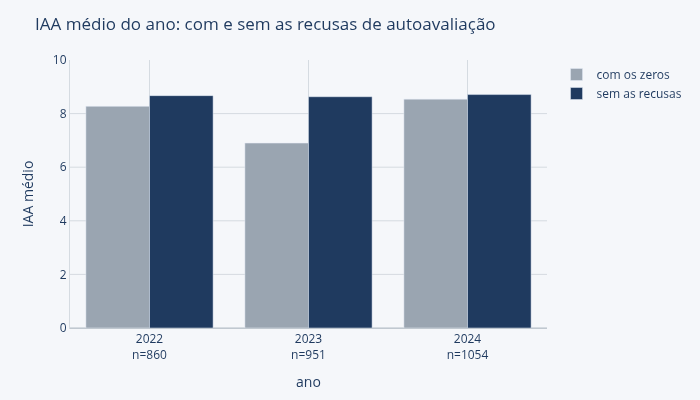

In [16]:
# ---------- A nota zero do IAA não é uma nota ----------
rec = df.dropna(subset=['iaa_recusa'])
tx4 = pd.DataFrame({'recusas': rec.groupby('ano').iaa_recusa.sum(),
                    'avaliados': rec.groupby('ano').size(),
                    'recusas_%': rec.groupby('ano').iaa_recusa.mean() * 100,
                    'IAA com zeros': df.groupby('ano').iaa.mean(),
                    'IAA sem recusas': df.groupby('ano').iaa_val.mean()}).round(2)
print('Recusa de autoavaliação e o efeito dela na média do IAA:')
print(tx4.to_string())

# O relatório da associação já diz o que o zero significa, mas uma definição documentada não dispensa a
# conferência: se fosse nota, quem zerou seria um aluno diferente dos demais em tudo o mais. As três
# checagens abaixo perguntam justamente isso — se ele foi avaliado, como ele vai nos outros indicadores e
# se a recusa se concentra em algum lugar da estrutura, que é o que uma falha de coleta produziria.
z4 = rec.iaa_recusa.astype(bool)
cols_av = [c for c in df.columns if c.startswith('avaliador_')]
tem_av = rec[cols_av].notna().any(axis=1)
print(f'\nCampo do avaliador preenchido: {tem_av[z4].mean() * 100:.1f}% de quem recusou '
      f'({tem_av[z4].sum()} de {z4.sum()}) contra {tem_av[~z4].mean() * 100:.1f}% do resto '
      f'({tem_av[~z4].sum()} de {(~z4).sum()}); avaliações por aluno: {rec.n_av[z4].mean():.2f} contra '
      f'{rec.n_av[~z4].mean():.2f}.')
print('\nOutros indicadores de quem recusou e de quem respondeu — o INDE fica fora porque ele já')
print('carrega o zero dentro de si, e conferir a penalidade com ela mesma não confere nada:')
print(rec.groupby(z4.map({True: 'recusou', False: 'respondeu'}))[['ieg', 'ida', 'ipv']]
      .mean().round(2).to_string())

# A escola seria o corte natural para procurar concentração, mas o campo só existe no dado de 2024: nenhuma
# linha de 2022 ou 2023 o traz preenchido, e é justamente 2023 que precisa ser explicado. A fase alcança os
# três anos, e é onde uma recusa de grupo apareceria — concentrada em algum ponto da estrutura.
por_fase = rec[rec.ano == 2023].groupby('fase').iaa_recusa.agg(recusas='sum', alunos='size')
por_fase['recusas_%'] = por_fase.recusas / por_fase.alunos * 100
print(f'\nRecusa por fase em 2023. A escola não serve para esta conferência: o campo só foi preenchido '
      f'em {df[df.ano == 2024].escola.notna().sum()} das {(df.ano == 2024).sum()} avaliações de 2024 e '
      f'em nenhuma das de 2022 e 2023.')
print(por_fase.round(1).to_string())

fig = go.Figure()
for serie, cor, nome in [('IAA com zeros', CINZA, 'com os zeros'), ('IAA sem recusas', AZUL, 'sem as recusas')]:
    fig.add_bar(x=rotulo_n(tx4.index.astype(str), tx4.avaliados), y=tx4[serie], name=nome, marker_color=cor,
                customdata=np.stack([tx4[serie], tx4.recusas], axis=-1),
                hovertemplate='%{customdata[0]:.2f} de média  ·  %{customdata[1]:.0f} recusas'
                              '<extra>' + nome + '</extra>')
fig.update_layout(barmode='group', title='IAA médio do ano: com e sem as recusas de autoavaliação',
                  xaxis_title='ano', yaxis_title='IAA médio', hovermode='x unified', legend_title='')
fig.update_yaxes(range=[0, 10])
aplicar_tema(fig, 400).show()

**Leitura.** O zero não é uma nota baixa: é uma recusa registrada como número. As conferências confirmam.
Quem recusou foi avaliado como todo mundo — campo do avaliador preenchido em 98,8% dos casos contra 98,7% do
resto, com 3,28 avaliações por aluno contra 3,13 — e, em 2023, a recusa aparece em todas as fases quase na
mesma proporção, de 18,1% na fase 4 a 24,2% na fase 3. Recusa espalhada assim por toda a estrutura não é
comportamento de um grupo específico; é o que acontece quando a coleta muda para todo mundo ao mesmo tempo.

O tamanho do estrago está no gráfico. Em 2023 o IAA médio publicado é 6,90 e, sem as recusas, seria 8,63. Os
outros dois anos praticamente não se mexem (8,27 contra 8,67 em 2022; 8,54 contra 8,71 em 2024), porque neles
a recusa é rara: 4,53% e 1,90%, contra 19,98% em 2023. A queda de quase dois pontos no meio da série não é um
ano em que os alunos se sentiram pior. É o ano em que um quinto deles não respondeu.

Isso não torna a recusa neutra. Quem recusou tem IEG médio 7,80 contra 8,27 e IDA 5,91 contra 6,42 — o zero
não é nota, mas o gesto anda junto com desengajamento, e é isso que o terceiro bloco vai testar.

Quanto o INDE de quem recusou sobe se o zero deixa de contar como nota: +0.69 (n = 249)
Alunos que aparecem uma pedra abaixo por causa da recusa: 148 de 245 (60.4%)

Distribuição das pedras em 2023 — oficial e sem a penalidade da recusa:
          oficial  sem_penalidade  oficial_%  sem_penalidade_%
Quartzo        72              38        7.7               4.1
Ágata         246             216       26.4              23.2
Ametista      381             412       40.9              44.3
Topázio       232             265       24.9              28.5


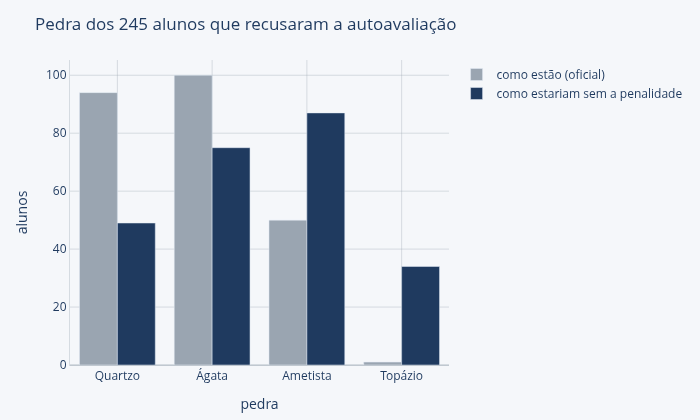

In [17]:
# ---------- Quanto a penalidade custa no INDE e nas pedras ----------
# O contrafactual repondera os seis indicadores restantes para somar 1, que é o que o INDE seria se a recusa
# fosse tratada como ausência em vez de zero. As faixas das pedras são as derivadas empiricamente do INDE.
sem_iaa = {k: v for k, v in PESOS.items() if k != 'iaa'}
inde_cf = sum(df[c] * p for c, p in sem_iaa.items()) / sum(sem_iaa.values())
z = df.iaa_recusa.fillna(False).astype(bool)
faixa = lambda v: (pd.NA if pd.isna(v) else 'Quartzo' if v < 6 else 'Ágata' if v < 7
                   else 'Ametista' if v < 8 else 'Topázio')
PEDRAS = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
pedra_of, pedra_cf = df.inde.map(faixa), inde_cf.where(z, df.inde).map(faixa)
val = z & pedra_of.notna() & inde_cf.notna()
mudou = pedra_of[val] != pedra_cf[val]
print(f'Quanto o INDE de quem recusou sobe se o zero deixa de contar como nota: {(inde_cf[z] - df.inde[z]).mean():+.2f} (n = {z.sum()})')
print(f'Alunos que aparecem uma pedra abaixo por causa da recusa: {mudou.sum()} de {val.sum()} '
      f'({mudou.mean() * 100:.1f}%)')
i23 = df.ano == 2023
print('\nDistribuição das pedras em 2023 — oficial e sem a penalidade da recusa:')
print(pd.DataFrame({'oficial': pedra_of[i23].value_counts(),
                    'sem_penalidade': pedra_cf[i23].value_counts(),
                    'oficial_%': pedra_of[i23].value_counts(normalize=True) * 100,
                    'sem_penalidade_%': pedra_cf[i23].value_counts(normalize=True) * 100})
      .reindex(PEDRAS).round(1).to_string())

# O gráfico é dos alunos que recusaram, que é de quem o número fala: a barra mostra onde eles estão
# classificados e onde estariam sem a penalidade, em contagem, porque é a contagem que a associação
# atende. O percentual continua no hover, junto do total de onde saiu.
of4 = pedra_of[val].value_counts().reindex(PEDRAS).fillna(0)
cf4 = pedra_cf[val].value_counts().reindex(PEDRAS).fillna(0)
fig = go.Figure()
for serie, cor, nome in [(of4, CINZA, 'como estão (oficial)'), (cf4, AZUL, 'como estariam sem a penalidade')]:
    pct, den = serie / val.sum() * 100, np.full(len(serie), val.sum())
    dados, modelo = hover_taxa(pct.to_numpy(), serie.to_numpy(), den)
    fig.add_bar(x=PEDRAS, y=serie, name=nome, marker_color=cor, customdata=dados,
                hovertemplate=modelo.replace('<extra></extra>', '<extra>' + nome + '</extra>'))
fig.update_layout(barmode='group', title=f'Pedra dos {val.sum()} alunos que recusaram a autoavaliação',
                  xaxis_title='pedra', yaxis_title='alunos', hovermode='x unified', legend_title='')
aplicar_tema(fig, 420).show()

**Leitura.** Tratar a recusa como zero custa 0,69 ponto de INDE, em média, a quem recusou. Parece pouco até
virar classificação: 148 dos 245 alunos com recusa e INDE calculado — 60,4% — aparecem uma pedra abaixo da
que teriam se a recusa fosse tratada como ausência. O gráfico mostra para onde eles voltariam: o Quartzo cai
de 94 para 49 alunos e o Topázio sobe de 1 para 34.

O efeito não fica contido nesse grupo, porque a distribuição do ano é publicada inteira. Em 2023 o Quartzo
aparece com 7,7% dos alunos quando seria 4,1%, e o Topázio com 24,9% quando seria 28,5%. Um relatório que
compare a distribuição de pedras de 2023 com a dos outros anos está comparando, em boa parte, quem respondeu
ao formulário.

In [18]:
# ---------- Recusar é, em si, um sinal? ----------
# A pergunta aqui é se a recusa antecipa a saída do aluno. Contagem antes de taxa, e por ano, porque a
# própria recusa muda de natureza quando deixa de ser rara.
mr = rec.merge(ev.rename(columns={'ano_referencia': 'ano'})[['id_aluno', 'ano', 'evadiu']],
               on=['id_aluno', 'ano'])
linhas4 = []
for ano, g in mr.groupby('ano'):
    for rotulo, h in [('recusou', g[g.iaa_recusa.astype(bool)]), ('respondeu', g[~g.iaa_recusa.astype(bool)])]:
        linhas4.append((ano, rotulo, len(h), h.evadiu.sum(), h.evadiu.mean() * 100))
print('Evasão no ano seguinte, de quem recusou e de quem respondeu:')
print(pd.DataFrame(linhas4, columns=['ano', 'grupo', 'alunos', 'evadiram', 'evadiram_%'])
      .round(1).to_string(index=False))

Evasão no ano seguinte, de quem recusou e de quem respondeu:
 ano     grupo  alunos  evadiram  evadiram_%
2022   recusou      39        20        51.3
2022 respondeu     821       240        29.2
2023   recusou     190        53        27.9
2023 respondeu     761       192        25.2


**Leitura.** A tabela conta antes de dividir, porque a taxa muda de significado com o tamanho do grupo. Em
2022, 39 alunos recusaram e 20 deles não voltaram no ano seguinte — 51,3% contra 29,2% de quem respondeu. Em
2023, 190 recusaram e 53 não voltaram: 27,9% contra 25,2%, uma diferença que não sustenta decisão nenhuma.

A leitura fácil seria dizer que recusar prevê evasão, citando o primeiro ano e ignorando o segundo. A leitura
correta é que o mesmo gesto significa coisas diferentes conforme a frequência: em 2022, recusar era exceção
individual e funcionava como aviso; em 2023, recusar foi o que um quinto da base fez, e um comportamento tão
comum não separa mais ninguém de ninguém.

Base da comparação: 2606 avaliações — fora 127 da fase 8 e 259 sem IAA válido ou sem IDA.

Correlação entre níveis, dentro do mesmo ano:
indicadores   ano  pearson  spearman    n
IAA_VAL×IDA  2022     0.15      0.14  821
IAA_VAL×IDA  2023     0.11      0.11  751
IAA_VAL×IDA  2024     0.15      0.15 1034
IAA_VAL×IDA todos     0.13      0.14 2606
IAA_VAL×IEG  2022     0.18      0.16  821
IAA_VAL×IEG  2023     0.12      0.13  751
IAA_VAL×IEG  2024     0.19      0.20 1034
IAA_VAL×IEG todos     0.16      0.16 2606

Correlação entre variações do mesmo aluno, dentro de cada transição:
     variação transição  pearson   n
d_iaa × d_ida 2022→2023   -0.021 439
d_iaa × d_ida 2023→2024    0.036 542
d_iaa × d_ida     todos   -0.002 981
d_iaa × d_ieg 2022→2023    0.061 439
d_iaa × d_ieg 2023→2024    0.051 542
d_iaa × d_ieg     todos    0.012 981

Distância entre a autoavaliação e o desempenho (IAA − IDA): média +2.25, mediana +2.08. Acima do próprio IDA: 2281 de 2606 (87.5%). Três pontos ou mais aci

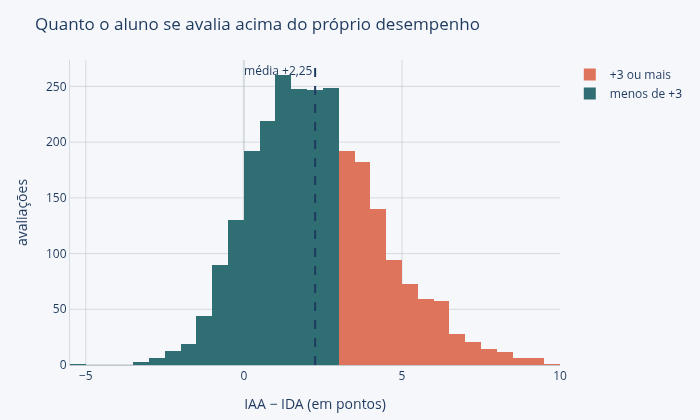

In [19]:
# ---------- A pergunta original, agora sem o ruído das recusas ----------
# Mesma restrição da P3, pelo mesmo motivo: o IDA quase não existe na fase 8, e comparar autoavaliação com
# desempenho exige que os dois estejam medidos.
b4 = df[df.fase <= 7].dropna(subset=['iaa_val', 'ida'])
print(f'Base da comparação: {len(b4)} avaliações — fora {(df.fase == 8).sum()} da fase 8 e '
      f'{len(df[df.fase <= 7]) - len(b4)} sem IAA válido ou sem IDA.')
print('\nCorrelação entre níveis, dentro do mesmo ano:')
print(tabela_corr([('iaa_val', 'ida'), ('iaa_val', 'ieg')], b4).to_string(index=False))
print('\nCorrelação entre variações do mesmo aluno, dentro de cada transição:')
print(corr_por_par([('d_iaa', 'd_ida'), ('d_iaa', 'd_ieg')],
                   painel[painel.fase_t1 <= 7]).drop(columns='p_valor').to_string(index=False))

g4 = b4.assign(gap=lambda d: d.iaa_val - d.ida)
acima3 = (g4.gap >= 3).sum()
print(f'\nDistância entre a autoavaliação e o desempenho (IAA − IDA): média {g4.gap.mean():+.2f}, '
      f'mediana {g4.gap.median():+.2f}. Acima do próprio IDA: {(g4.gap > 0).sum()} de {len(g4)} '
      f'({(g4.gap > 0).mean() * 100:.1f}%). Três pontos ou mais acima: {acima3} '
      f'({acima3 / len(g4) * 100:.1f}%).')

# O corte de +3 é o número que a leitura cita, então ele é desenhado: a área à direita da linha é o grupo
# que se avalia três pontos ou mais acima do próprio desempenho, e não uma região que o texto afirma existir.
fig = go.Figure()
for rotulo, sub, cor in [('menos de +3', g4.gap[g4.gap < 3], TEAL), (f'+3 ou mais', g4.gap[g4.gap >= 3], CORAL)]:
    fig.add_histogram(x=sub, xbins=dict(start=-6, end=10, size=0.5), marker_color=cor, name=rotulo,
                      hovertemplate='distância em %{x}<br>%{y} avaliações<extra>' + rotulo + '</extra>')
fig.add_vline(x=g4.gap.mean(), line=dict(color=AZUL, width=2, dash='dash'),
              annotation_text=f'média {g4.gap.mean():+.2f}'.replace('.', ','), annotation_position='top left')
fig.update_layout(barmode='stack', title='Quanto o aluno se avalia acima do próprio desempenho',
                  xaxis_title='IAA − IDA (em pontos)', yaxis_title='avaliações', legend_title='')
aplicar_tema(fig, 420).show()

**Leitura.** Com as recusas fora do caminho, o IAA anda muito pouco junto com o desempenho: 0,13 com o IDA e
0,16 com o IEG no nível, e entre −0,02 e +0,06 quando o que se compara é a variação do mesmo aluno, o que é
indistinguível de nada. Saber a autoavaliação de um aluno não diz onde ele está nem para onde ele vai.

O que existe é uma distância, e ela tem direção. Em 2.281 das 2.606 avaliações (87,5%) a autoavaliação está
acima do próprio IDA, com média de +2,25 ponto. O histograma separa por cor o grupo que o texto cita: à
direita da fronteira estão os 885 casos (34,0%) em que o aluno se dá três pontos ou mais acima do próprio
desempenho — um aluno com IDA 5 se avaliando 8.

### Resposta da P4

**A pergunta, como foi feita, não tinha resposta na base — e o motivo virou o achado.** Antes de comparar
autoavaliação com desempenho é preciso tirar da conta um zero que não é nota. Em 2023, 190 dos 951 alunos
avaliados (19,98%) recusaram a autoavaliação, e é isso — não o humor da turma — que derruba o IAA publicado
de 8,27 para 6,90 e o devolve a 8,54 no ano seguinte.

**Feita a limpeza, a resposta é não.** A autoavaliação quase não acompanha o desempenho: 0,13 entre níveis no
mesmo ano e praticamente zero entre as variações do mesmo aluno. E a distância é sistemática e para cima —
87,5% dos alunos se avaliam acima do próprio IDA, em média +2,25 ponto, e 34,0% se avaliam três pontos ou
mais acima.

**Recusar, por outro lado, foi um sinal enquanto foi raro.** Em 2022, quando 39 alunos recusaram, 51,3% deles
não voltaram no ano seguinte, contra 29,2% de quem respondeu. Em 2023, com 190 recusas, a diferença
desaparece (27,9% contra 25,2%).

**O que a seção não estabelece.** Que o aluno esteja se enganando sobre si mesmo. Autoavaliação e prova medem
coisas diferentes, e um aluno pode ter razão sobre o próprio esforço e ainda assim ir mal em matemática. O
que a distância mostra é que uma não substitui a outra — não que uma delas esteja errada.

**Frentes:**

1. **Corrigir o tratamento do zero no cálculo do INDE.** Como ausência em vez de nota, o INDE de quem recusou
   sobe 0,69 em média e 148 dos 245 afetados (60,4%) saem da pedra em que aparecem hoje — 45 deles deixam o
   Quartzo. A pedra é usada para priorizar atendimento; hoje ela penaliza quem não respondeu a um formulário.
2. **Não comparar IAA entre anos que incluam 2023.** Nem no relatório, nem no painel, nem na apresentação: a
   série sobe e desce por causa da coleta, e qualquer conclusão tirada dela é sobre o formulário.
3. **Reaproveitar a recusa como variável, não como nota.** Ela já existe no dado limpo (`iaa_recusa`) e, nos
   anos em que é rara, antecipa evasão melhor do que o próprio IAA. É informação que hoje entra na conta pelo
   pior caminho possível.

## P5 — O IPS (psicossocial) antecede quedas de desempenho ou engajamento?

O IPS (Indicador Psicossocial) resume a leitura da equipe sobre a situação emocional e social do aluno. A
pergunta é se ele funciona como aviso: um IPS baixo hoje anuncia queda de nota ou de engajamento no ano que
vem? Se anunciar, a associação ganha um alarme que dispara antes do prejuízo aparecer no boletim.

O teste é direto: o IPS do ano t contra a variação de IDA e de IEG entre t e t+1, dentro de cada transição.
A conta com as duas transições empilhadas aparece junto, porque é dela que saía a conclusão anterior do
notebook e ela precisa ser confrontada, não escondida — mas o motivo pelo qual empilhar distorce vale para
várias perguntas e está demonstrado uma vez só, na P11.

In [20]:
# ---------- O IPS de hoje contra a variação de amanhã ----------
b5 = painel[painel.fase_t1 <= 7].dropna(subset=['ips'])
print(f'Transições com IPS medido em t: {len(b5)} das {len(painel)} do painel, '
      f'{b5.id_aluno.nunique()} alunos.')
linhas5 = []
for alvo in ['d_ida', 'd_ieg']:
    for nome, g in list(b5.groupby('transicao')) + [('empilhado', b5)]:
        g = g.dropna(subset=[alvo])
        linhas5.append((f'IPS(t) × {alvo}', nome, g.ips.corr(g[alvo]), len(g)))
print('\nCorrelação entre o IPS em t e a variação até t+1:')
print(pd.DataFrame(linhas5, columns=['relação', 'transição', 'pearson', 'n']).round(2).to_string(index=False))
print('\nIPS médio de partida e variação média de cada transição:')
print(b5.groupby('transicao').agg(ips_medio=('ips', 'mean'), d_ida_medio=('d_ida', 'mean'),
                                  d_ieg_medio=('d_ieg', 'mean'), n=('ips', 'size')).round(2).to_string())

Transições com IPS medido em t: 1270 das 1365 do painel, 830 alunos.

Correlação entre o IPS em t e a variação até t+1:
       relação transição  pearson    n
IPS(t) × d_ida 2022→2023     0.06  574
IPS(t) × d_ida 2023→2024     0.05  678
IPS(t) × d_ida empilhado     0.12 1252
IPS(t) × d_ieg 2022→2023    -0.01  574
IPS(t) × d_ieg 2023→2024     0.06  678
IPS(t) × d_ieg empilhado     0.20 1252

IPS médio de partida e variação média de cada transição:
           ips_medio  d_ida_medio  d_ieg_medio    n
transicao                                          
2022→2023       6.88         0.12         0.23  581
2023→2024       5.14        -0.48        -0.81  689


**Leitura.** Dentro de cada transição, o IPS de partida quase não diz nada sobre a variação do ano seguinte:
0,06 e 0,05 para o desempenho, −0,01 e 0,06 para o engajamento, numa escala em que 1 seria previsão perfeita.
Como aviso antecipado, isso é ruído.

A linha empilhada conta outra história — 0,12 e 0,20 — e era dela que saía a conclusão anterior desta seção.
O motivo de ela não valer está na tabela de baixo: as duas transições partem de patamares muito diferentes de
IPS (6,88 e 5,14) e terminam com variações médias de sinais opostos (+0,12 e −0,48 no IDA; +0,23 e −0,81 no
IEG). Somar as duas numa conta só faz o **ano** entrar disfarçado de **aluno**: o que a correlação empilhada
descreve é a diferença entre 2022 e 2023, não a diferença entre um aluno com IPS alto e outro com IPS baixo.
Esse mecanismo reaparece em outros pontos do relatório e está demonstrado uma única vez, na P11.

Δ IDA por quartil de IPS(t), dentro de cada transição:
                               media    n  melhoraram  melhoraram_%
transicao faixa                                                    
2022→2023 Q1 (IPS mais baixo)  -0.07  144          62         43.06
          Q2                    0.34  143          69         48.25
          Q3                    0.24  143          69         48.25
          Q4 (IPS mais alto)   -0.04  144          68         47.22
2023→2024 Q1 (IPS mais baixo)  -0.55  170          75         44.12
          Q2                   -0.52  169          74         43.79
          Q3                   -0.20  169          80         47.34
          Q4 (IPS mais alto)   -0.66  170          57         33.53
Fora do gráfico, por terem menos de 10 alunos: nenhuma célula.


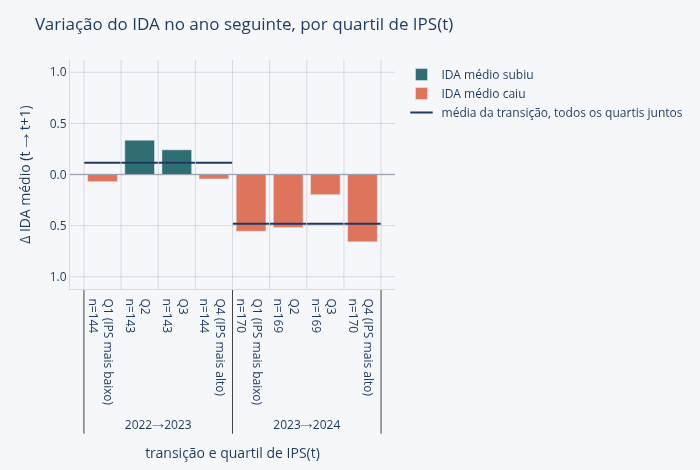

In [21]:
# ---------- A mesma pergunta pela via descritiva: há gradiente por faixa de IPS? ----------
# O quartil é calculado dentro de cada transição, justamente para não misturar duas escalas que, como a
# célula seguinte mostra, não são a mesma coisa de um ano para o outro.
b5q = b5.dropna(subset=['d_ida']).copy()
b5q['faixa'] = b5q.groupby('transicao').ips.transform(
    lambda s: pd.qcut(s.rank(method='first'), 4, labels=['Q1 (IPS mais baixo)', 'Q2', 'Q3',
                                                         'Q4 (IPS mais alto)']))
tab5 = b5q.groupby(['transicao', 'faixa'], observed=True).d_ida.agg(
    media='mean', n='size', melhoraram=lambda s: (s > 0).sum())
tab5['melhoraram_%'] = tab5.melhoraram / tab5.n * 100
print('Δ IDA por quartil de IPS(t), dentro de cada transição:')
print(tab5.round(2).to_string())
finas5 = tab5[tab5.n < MIN_CELULA]
print(f'Fora do gráfico, por terem menos de {MIN_CELULA} alunos: '
      + (', '.join(f'{t} · {f}' for t, f in finas5.index) or 'nenhuma célula') + '.')

grosso5 = tab5[tab5.n >= MIN_CELULA]
ref5 = b5q.groupby('transicao').d_ida.mean()
barras_variacao(grosso5, 'Variação do IDA no ano seguinte, por quartil de IPS(t)',
                'transição e quartil de IPS(t)', 'Δ IDA médio (t → t+1)',
                nomes=('IDA médio subiu', 'IDA médio caiu'),
                referencia=[ref5[t] for t, _ in grosso5.index],
                nome_ref='média da transição, todos os quartis juntos').show()

**Leitura.** Se o IPS antecipasse queda, as barras formariam uma escada: o quartil mais baixo caindo mais, o
mais alto caindo menos. Nenhuma das duas transições faz isso. Em 2022→2023 o quartil mais baixo varia −0,07 e
o mais alto −0,04, com os dois quartis do meio subindo (+0,34 e +0,24). Em 2023→2024 todos caem, e a maior
queda está no quartil de **IPS mais alto** (−0,66, contra −0,55 do mais baixo) — o contrário do que a
hipótese previa. As oito células têm entre 143 e 170 alunos cada, então não é falta de gente.

Quantis do IPS por ano:
       count  mean   std   min   10%   25%   50%   75%   90%   max
ano                                                               
2022   860.0  6.90  1.07  2.50  5.00  6.30  7.50  7.50  7.50  10.0
2023   945.0  5.12  2.09  2.52  2.52  2.52  5.00  7.52  7.52  10.0
2024  1054.0  6.83  1.43  2.51  5.01  6.26  7.51  7.51  8.13  10.0

Alunos exatamente no valor mínimo da escala, em cada ano:
      minimo  no_minimo     n  no_minimo_%
ano                                       
2022    2.50          1   860         0.12
2023    2.52        265   945        28.04
2024    2.51         58  1054         5.50


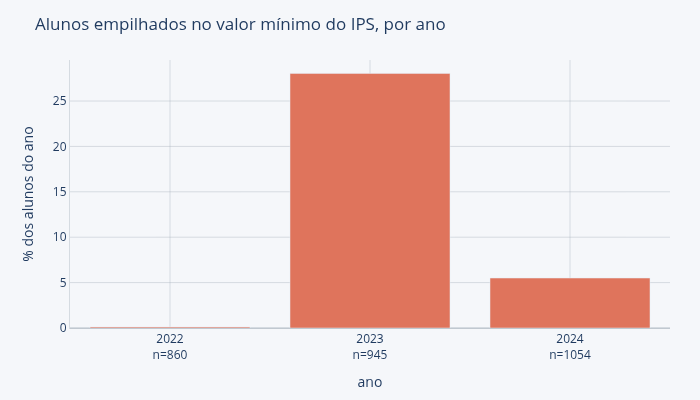

In [22]:
# ---------- Por que as duas transições não são comparáveis: o piso do IPS em 2023 ----------
# A escala do IPS não se comporta igual nos três anos. Em 2023 uma parte grande da base está empilhada
# exatamente no valor mínimo, e um piso desses muda o nível médio do grupo sem dizer nada sobre os alunos.
print('Quantis do IPS por ano:')
print(df.groupby('ano').ips.describe(percentiles=[.1, .25, .5, .75, .9]).round(2).to_string())

piso = df.dropna(subset=['ips']).groupby('ano').ips.agg(
    minimo='min', no_minimo=lambda s: (s == s.min()).sum(), n='size')
piso['no_minimo_%'] = piso.no_minimo / piso.n * 100
print('\nAlunos exatamente no valor mínimo da escala, em cada ano:')
print(piso.round(2).to_string())

dados5, modelo5 = hover_taxa(piso['no_minimo_%'].to_numpy(), piso.no_minimo.to_numpy(), piso.n.to_numpy())
fig = go.Figure(go.Bar(x=rotulo_n(piso.index.astype(str), piso.n), y=piso['no_minimo_%'],
                       marker_color=CORAL, showlegend=False, customdata=dados5, hovertemplate=modelo5))
fig.update_layout(title='Alunos empilhados no valor mínimo do IPS, por ano',
                  xaxis_title='ano', yaxis_title='% dos alunos do ano')
aplicar_tema(fig, 400).show()

**Leitura.** A escala do IPS não se comporta igual nos três anos. Em 2023, 265 dos 945 alunos com IPS medido
— 28,0% — estão exatamente no valor mínimo, 2,52; em 2022 isso acontece com 1 aluno (0,1%) e em 2024 com 58
(5,5%). Os quantis mostram o mesmo de outro jeito: em 2023 o décimo e o quarto inferiores da base estão os
dois em 2,52, ou seja, um quarto dos alunos parado na mesma casa decimal.

Qual foi a mudança — de formulário, de escala ou de regra de preenchimento — a base não diz. Mas o número de
2023 descreve o instrumento tanto quanto descreve o aluno, e isso basta para uma consequência prática:
nenhuma comparação de IPS que atravesse 2023 pode ser lida como mudança de bem-estar.

### Resposta da P5

**Não. O IPS medido hoje não antecipa a queda de amanhã.** Dentro de cada transição a relação com a variação
seguinte fica em 0,06 e 0,05 para o desempenho e em −0,01 e 0,06 para o engajamento, e o gradiente por
quartil simplesmente não existe: em 2023→2024 quem mais caiu foi o quartil de IPS **mais alto**. Usar o IPS
como alarme antecipado colocaria a fila de atendimento em ordem errada.

**O que a seção não estabelece.** Que o acompanhamento psicossocial não importe. O IPS mede a leitura da
equipe sobre o aluno, não o atendimento que ele recebeu, e um indicador que não prevê pode perfeitamente
estar medindo algo real e importante. O que está estabelecido aqui é sobre o poder de antecipação do
indicador — nada além disso.

**Frentes:**

1. **Não usar o IPS como gatilho de encaminhamento preventivo.** Ele não separa quem vai cair de quem não
   vai. Para essa função a P3 aponta um candidato melhor, a queda de IEG, e a P9 monta o modelo que combina
   os dois.
2. **Revisar a coleta do IPS antes de qualquer série histórica.** Com 28,0% da base no piso em 2023 contra
   0,1% em 2022, comparar anos mistura mudança de aluno com mudança de instrumento.
3. **Investigar o que significa o valor de piso.** A P4 mostra o que acontece quando um código de não
   resposta entra na média como se fosse nota. Aqui há o mesmo desenho, e quem aplica o instrumento pode
   confirmar ou descartar em uma conversa — o que a base sozinha não consegue fazer.

## P6 — As avaliações psicopedagógicas (IPP) confirmam ou contradizem o IAN?

O IAN mede a adequação do aluno à fase; o IPP é a avaliação que a equipe psicopedagógica faz dele. A
pergunta é se os dois contam a mesma história — e ela se divide nas duas camadas de sempre: se alunos mais
defasados recebem IPP menor, e se o IPP do mesmo aluno acompanha a defasagem dele quando ela muda. A
segunda é a que interessa para a prática, porque só ela distingue "o IPP descreve a situação" de "o IPP
responde ao progresso".

> **Ressalva sobre 2022.** O IPP de 2022 não foi publicado e está reconstruído a partir da fórmula do INDE.
> A diferença de patamar entre 2022 e os dois anos seguintes (≈ 6,3 contra ≈ 7,6) é uma diferença real de
> distribuição, não erro de reconstrução — a verificação está em `planning/achados_limpeza.md`, achado 2. A
> consequência prática é que a transição 2022→2023 mistura mudança de aluno com mudança de patamar, e por
> isso as duas transições são lidas separadamente aqui e em todo o resto do relatório.

Base da P6: 2852 das 3030 avaliações. Ficam de fora 178 sem IPP — 127 delas na fase 8, que tem rubrica própria — e 0 sem defasagem registrada.

IPP médio por categoria de defasagem × ano:
ano       2022  2023  2024
cat_ian                   
severa    6.47  6.96  7.26
moderada  6.18  7.50  7.41
em fase   6.50  7.67  7.69

Quantas avaliações sustentam cada uma dessas médias:
ano       2022  2023  2024
cat_ian                   
severa      28    14     3
moderada   573   536   531
em fase    259   388   520

A categoria severa encolhe ao longo dos três anos: 2022 com 28 avaliações (3.3% do ano), 2023 com 14 avaliações (1.5% do ano), 2024 com 3 avaliações (0.3% do ano).

Defasagem × IPP, os três anos juntos: +0.24 (n = 2852)
  2022→2023: em t = +0.18 | em t+1 = +0.31
  2023→2024: em t = +0.20 | em t+1 = +0.26

Fora do gráfico, por terem menos de 10 avaliações: severa em 2024 (n = 3).


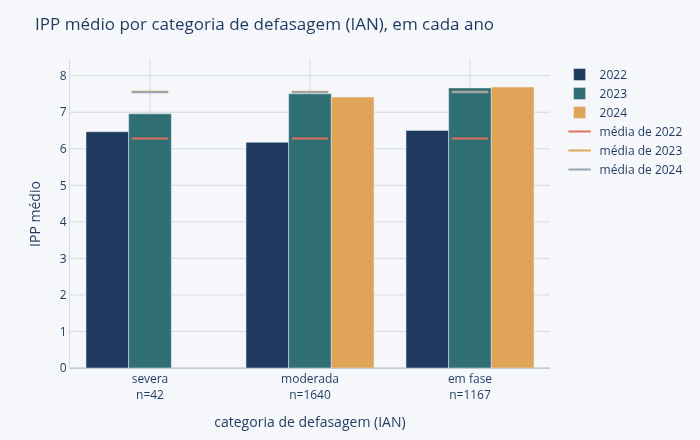

In [23]:
# ---------- Camada de nível ----------
df['cat_ian'] = pd.Categorical(
    np.select([df.ian == 2.5, df.ian == 5], ['severa', 'moderada'], default='em fase'),
    ['severa', 'moderada', 'em fase'])

b6 = df.dropna(subset=['ipp', 'defasagem'])
sem_ipp = df.ipp.isna()
print(f'Base da P6: {len(b6)} das {len(df)} avaliações. Ficam de fora {sem_ipp.sum()} sem IPP — '
      f'{(sem_ipp & (df.fase == 8)).sum()} delas na fase 8, que tem rubrica própria — e '
      f'{(~sem_ipp & df.defasagem.isna()).sum()} sem defasagem registrada.')

niv6 = b6.pivot_table(index='cat_ian', columns='ano', values='ipp', observed=True)
n6 = b6.pivot_table(index='cat_ian', columns='ano', values='ipp', observed=True, aggfunc='size')
print('\nIPP médio por categoria de defasagem × ano:')
print(niv6.round(2).to_string())
print('\nQuantas avaliações sustentam cada uma dessas médias:')
print(n6.to_string())
parcela6 = n6.loc['severa'] / n6.sum() * 100
print('\nA categoria severa encolhe ao longo dos três anos: '
      + ', '.join(f'{a} com {n6.loc["severa", a]} avaliações ({parcela6[a]:.1f}% do ano)'
                  for a in n6.columns) + '.')

print(f'\nDefasagem × IPP, os três anos juntos: {stats.pearsonr(b6.defasagem, b6.ipp)[0]:+.2f} '
      f'(n = {len(b6)})')

# Uma associação que aparece num ano e some no outro é do ano, não do aluno. Conferir nas duas pontas de
# cada par é a forma mais barata de descartar isso.
p6 = painel.dropna(subset=['d_ipp', 'd_defasagem'])
for nome, g in p6.groupby('transicao'):
    print(f'  {nome}: em t = {stats.pearsonr(g.defasagem, g.ipp)[0]:+.2f} | '
          f'em t+1 = {stats.pearsonr(g.defasagem_t1, g.ipp_t1)[0]:+.2f}')

# Os três anos lado a lado, cada um com a sua própria média marcada por cima, no tom de contraste da
# série. O IPP de 2022 está num patamar diferente (ressalva acima), e comparar cada categoria contra a
# média do próprio ano é o que impede a diferença de patamar de ser lida como diferença de aluno. Célula
# abaixo do mínimo não vira barra: uma média de três pessoas ocupa no gráfico o mesmo espaço que uma de
# quinhentas.
finos6 = [(c, a, int(n6.loc[c, a])) for c in n6.index for a in n6.columns if n6.loc[c, a] < MIN_CELULA]
print(f'\nFora do gráfico, por terem menos de {MIN_CELULA} avaliações: '
      + (', '.join(f'{c} em {a} (n = {v})' for c, a, v in finos6) or 'nenhuma célula') + '.')
niv6, n6 = niv6.mask(n6 < MIN_CELULA), n6.where(n6 >= MIN_CELULA, 0)

niv6.columns = n6.columns = [str(a) for a in niv6.columns]
barras_nivel(niv6, n6, 'IPP médio por categoria de defasagem (IAN), em cada ano',
             'categoria de defasagem (IAN)', 'IPP médio',
             referencias={f'média de {a}': v for a, v in
                          zip(niv6.columns, b6.groupby('ano').ipp.mean())}).show()

**Leitura da camada de nível.** As barras são o IPP médio de cada categoria de defasagem, uma por ano, e o
traço horizontal de cada cor é a média do próprio ano. Comparar cada barra com o traço da mesma cor é o que
impede a diferença de patamar entre 2022 e os anos seguintes de ser lida como diferença de aluno.

Nos dois anos em que o IPP foi publicado, quem está em fase recebe avaliação psicopedagógica melhor do que
quem tem defasagem moderada: 7,67 contra 7,50 em 2023 e 7,69 contra 7,41 em 2024. A distância é pequena —
menos de três décimos numa escala de dez — e é a parte sólida do achado, porque são as duas categorias
cheias: 536 e 388 avaliações em 2023, 531 e 520 em 2024.

A defasagem severa não sustenta leitura. São 28 avaliações em 2022, 14 em 2023 e 3 em 2024, e a barra de
2024 nem aparece, por ficar abaixo do mínimo de dez alunos que este relatório usa. Em 2022 a categoria
inclusive aparece acima da moderada (6,47 contra 6,18), e com 28 alunos isso é ruído, não achado. O que a
sequência 28 → 14 → 3 diz é outra coisa, e vale mais: a defasagem severa saiu de 3,3% da base em 2022 para
0,3% em 2024. É leitura transversal, com a limitação que a nota metodológica registra — mas aponta na mesma
direção da recuperação que a P1 mediu dentro de cada aluno.

A ordem das três barras, portanto, não é a evidência. A evidência é a associação medida sobre a defasagem
contínua, que fica em +0,24 nas 2.852 avaliações e se repete nas duas pontas de cada par de anos: +0,18 e
+0,31 no primeiro par, +0,20 e +0,26 no segundo. Um número que aparece nas quatro medições não é efeito de
um ano atípico.

Quando a defasagem do aluno muda, o IPP muda junto?
           variação transição  pearson    n
d_ipp × d_defasagem 2022→2023    0.009  574
d_ipp × d_defasagem 2023→2024   -0.248  681
d_ipp × d_defasagem     todos   -0.165 1255

IPP antes e depois, por tipo de movimento na defasagem:
                           ipp  ipp_t1  d_ipp
transicao movimento                          
2022→2023 perdeu fase     5.93    7.33   1.40
          sem mudança     6.26    7.63   1.38
          recuperou fase  6.39    7.85   1.46
2023→2024 perdeu fase     7.09    7.44   0.34
          sem mudança     7.53    7.51  -0.02
          recuperou fase  7.90    7.57  -0.34

Contagem antes da taxa:
                          media    n  melhoraram  melhoraram_%
transicao movimento                                           
2022→2023 perdeu fase      1.40  104          94         90.38
          sem mudança      1.38  307         272         88.60
          recuperou fase   1.46  163         143         87.73
2023→20

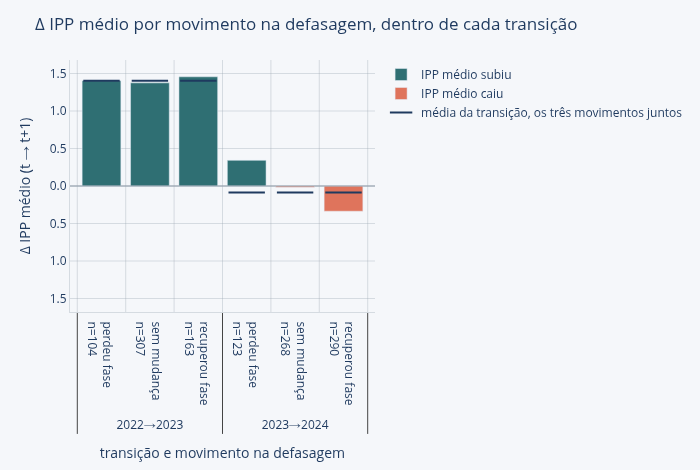

In [24]:
# ---------- Camada de variação ----------
# A defasagem é codificada com valores negativos (quanto mais atrás da fase ideal, menor), então recuperar
# fase é Δ defasagem positivo, e o IPP confirmar o IAN pediria Δ IPP também positivo.
print('Quando a defasagem do aluno muda, o IPP muda junto?')
print(corr_por_par([('d_ipp', 'd_defasagem')]).drop(columns='p_valor').to_string(index=False))

p6 = p6.assign(movimento=pd.Categorical(
    np.select([p6.d_defasagem > 0, p6.d_defasagem < 0], ['recuperou fase', 'perdeu fase'],
              default='sem mudança'), ['perdeu fase', 'sem mudança', 'recuperou fase']))
print('\nIPP antes e depois, por tipo de movimento na defasagem:')
print(p6.groupby(['transicao', 'movimento'], observed=True)[['ipp', 'ipp_t1', 'd_ipp']]
      .mean().round(2).to_string())

tab6 = p6.groupby(['transicao', 'movimento'], observed=True).d_ipp.agg(
    media='mean', n='size', melhoraram=lambda s: (s > 0).sum())
tab6['melhoraram_%'] = tab6.melhoraram / tab6.n * 100
print('\nContagem antes da taxa:')
print(tab6.round(2).to_string())
finos = tab6[tab6.n < MIN_CELULA]
print(f'\nFora do gráfico, por terem menos de {MIN_CELULA} alunos: '
      + (', '.join(f'{t} / {m} (n = {v})' for (t, m), v in finos.n.items()) or 'nenhuma célula') + '.')

grosso6 = tab6[tab6.n >= MIN_CELULA]
barras_variacao(grosso6, 'Δ IPP médio por movimento na defasagem, dentro de cada transição',
                'transição e movimento na defasagem', 'Δ IPP médio (t → t+1)',
                nomes=('IPP médio subiu', 'IPP médio caiu'), passo=0.5,
                referencia=[p6.groupby('transicao').d_ipp.mean()[t] for t, _ in grosso6.index],
                nome_ref='média da transição, os três movimentos juntos').show()

**Leitura da camada de variação.** As barras são o Δ IPP médio de cada grupo dentro de cada transição — em
verde quando o grupo sobe, em coral quando cai — e o traço horizontal é a média da transição inteira, com os
três movimentos somados. Nenhuma das seis células tem menos de dez alunos.

Em 2022→2023 os três grupos sobem quase o mesmo tanto: +1,40 para quem perdeu fase, +1,38 para quem ficou
onde estava e +1,46 para quem recuperou, com 88% a 90% dos alunos de cada grupo subindo. Ali o IPP subiu
para quase todo mundo — é a mudança de patamar registrada na ressalva de abertura, não trajetória de aluno.

Em 2023→2024 a ordem se inverte, e é essa inversão que a seção precisa explicar. Quem recuperou fase
**perdeu** IPP: 102 dos 290 subiram, média de −0,34. Quem perdeu fase ganhou: 62 de 123 subiram, média de
+0,34. Quem não se moveu ficou parado: 124 de 268, média de −0,02. A associação entre as duas variações
fecha em −0,25 nessa transição, contra +0,01 na anterior.

Lido de frente, isso diria que recuperar fase piora a avaliação psicopedagógica. Antes de aceitar, a célula
seguinte pergunta de onde vem o sinal.

In [25]:
def parcial(g, x, y, controle):
    """Correlação entre x e y depois de descontar de ambos o efeito linear de `controle`. Serve para
    perguntar se sobra alguma associação quando o ponto de partida deixa de contar."""
    resid = lambda c: g[c] - np.polyval(np.polyfit(g[controle], g[c], 1), g[controle])
    return stats.pearsonr(resid(x), resid(y))[0]


# Quem recupera fase parte de um IPP mais alto, e quem parte de um valor alto tende a aparecer mais baixo na
# medição seguinte por razões que não têm nada a ver com o aluno — o padrão vale para todos os indicadores
# desta base e está demonstrado uma única vez, na P11. Sem descontar o ponto de partida, a correlação de
# variação mede esse retorno, e não resposta do IPP ao progresso do aluno.
print('O sinal negativo é resposta do IPP ou herança do ponto de partida?')
for nome, g in p6.groupby('transicao'):
    print(f'  {nome}: IPP(t) × Δ IPP = {stats.pearsonr(g.ipp, g.d_ipp)[0]:+.2f} | '
          f'Δ IPP × Δ defasagem bruto {stats.pearsonr(g.d_ipp, g.d_defasagem)[0]:+.2f} → '
          f'descontando o IPP de partida {parcial(g, "d_ipp", "d_defasagem", "ipp"):+.2f}')

O sinal negativo é resposta do IPP ou herança do ponto de partida?
  2022→2023: IPP(t) × Δ IPP = -0.64 | Δ IPP × Δ defasagem bruto +0.01 → descontando o IPP de partida +0.14
  2023→2024: IPP(t) × Δ IPP = -0.56 | Δ IPP × Δ defasagem bruto -0.25 → descontando o IPP de partida -0.10


**Leitura.** O sinal não vem do aluno, vem do ponto de partida. Quem recuperou fase já chegava com IPP mais
alto — 7,90 contra 7,09 de quem perdeu fase, na tabela acima — e nesta base quem parte de um valor alto tende
a aparecer mais baixo na medição seguinte independentemente do que tenha acontecido no meio: o IPP de partida
correlaciona −0,64 e −0,56 com a própria variação. O padrão vale para todos os indicadores da base e está
demonstrado uma única vez, na P11; aqui basta a consequência.

Descontado o ponto de partida, o −0,25 de 2023→2024 vira −0,10 e o +0,01 de 2022→2023 vira +0,14. Sobram
duas associações fracas e de sinais contrários — ou seja, não sobra associação nenhuma para explicar.

### Resposta da P6

**Confirmam como retrato, não como acompanhamento.** Entre alunos os dois indicadores contam a mesma
história: quem está em fase recebe IPP melhor, com +0,24 de associação com a defasagem contínua, repetida
nas duas pontas de cada par de anos. Dentro do mesmo aluno, quando a defasagem muda, o IPP não responde. A
única transição em que aparece associação é 2023→2024, e ela se dissolve para −0,10 assim que o ponto de
partida é descontado.

**O que a seção não estabelece.** Que a avaliação psicopedagógica não sirva para nada, nem que a equipe
esteja avaliando errado. Um instrumento pode descrever bem a situação de hoje sem ser sensível o bastante,
entre uma aplicação anual e a seguinte, para registrar o efeito de mudar de fase. Também não estabelece nada
sobre a transição 2022→2023, em que o IPP inteiro mudou de patamar: ali não há trajetória a ler. Por que
valores altos tendem a cair na medição seguinte, e como o IPP conversa com os demais indicadores, ficam
para a P11.

**Frentes:**

1. **Não usar variação anual de IPP como medida de efeito.** Se a pergunta é se o aluno melhorou depois de
   recuperar fase, o Δ IPP responde ao ponto de partida antes de responder ao aluno — e nesta base responde
   ao contrário. Existe um uso em que o IPP é forte, e é o da P9: como sinal de nível, ele é o indicador que
   mais antecipa risco depois da própria defasagem.
2. **Publicar o IPP de 2022.** Hoje ele está reconstruído a partir da fórmula do INDE, e é a única razão
   pela qual uma das duas transições da base não pode ser lida como trajetória. Com o valor original, a
   série passa a ter duas transições comparáveis em vez de uma.
3. **Registrar a data da avaliação psicopedagógica.** A base traz o ano, não o momento. Sem isso não há como
   saber se o IPP de um aluno foi medido antes ou depois da mudança de fase — e é exatamente essa ordem que
   separa descrição de resposta.

## P7 — O que mais influencia o IPV (ponto de virada)?

Método em duas camadas. A **de nível** são os coeficientes padronizados de regressão linear e as importâncias de RandomForest para `ipv ~ ieg + ida + ips + iaa_val + defasagem`, com R² validado por GroupKFold (grupos = aluno, evita vazamento entre anos do mesmo estudante). A **de variação** roda o mesmo modelo sobre as diferenças — `d_ipv ~ d_ieg + d_ida + d_ips + d_iaa + d_defasagem` — e é ela que responde à pergunta útil para intervenção: quando o aluno melhora nos insumos, o ponto de virada dele sobe?

O modelo de variação é estimado **separadamente em cada transição**, e a coluna empilhada aparece na tabela só como demonstração de que agregar as duas inverte o sinal do IPS (ver P5).


Nível — ipv ~ ieg + ida + ips + iaa_val + defasagem
           coef_padronizado (LR)  importancia (RF)
ida                         0.38              0.37
ieg                         0.36              0.34
ips                        -0.05              0.12
iaa_val                     0.07              0.12
defasagem                   0.09              0.05
R² (RandomForest, GroupKFold 5): 0.42 ± 0.00 (n = 2600)


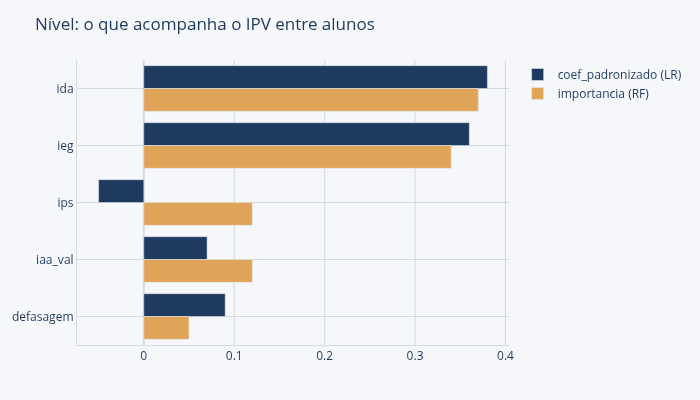

In [26]:
# ---------- Nível ----------
FEAT7 = ['ieg', 'ida', 'ips', 'iaa_val', 'defasagem']
b7 = df.dropna(subset=FEAT7 + ['ipv'])
X, y = b7[FEAT7], b7['ipv']

coefs = pd.Series(LinearRegression().fit(StandardScaler().fit_transform(X), y).coef_, index=FEAT7)
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(X, y)
r2 = cross_val_score(rf, X, y, cv=GroupKFold(5), groups=b7.id_aluno, scoring='r2')

comp = pd.DataFrame({'coef_padronizado (LR)': coefs, 'importancia (RF)': rf.feature_importances_}) \
         .sort_values('importancia (RF)', ascending=False).round(2)
print('Nível — ipv ~ ' + ' + '.join(FEAT7))
print(comp)
print(f'R² (RandomForest, GroupKFold 5): {r2.mean():.2f} ± {r2.std():.2f} (n = {len(b7)})')

fig = go.Figure()
for metrica, cor in zip(comp.columns, [AZUL, AMBAR]):
    fig.add_bar(y=comp.index, x=comp[metrica], orientation='h', name=metrica, marker_color=cor,
                hovertemplate='%{y}: %{x:.2f}<extra>' + metrica + '</extra>')
fig.update_yaxes(autorange='reversed')
fig.update_layout(barmode='group', title='Nível: o que acompanha o IPV entre alunos', legend_title='')
aplicar_tema(fig, 400).show()


**Leitura da camada de nível.** IDA (0,38) e IEG (0,36) dominam, e os dois métodos concordam: as importâncias
do RandomForest colocam os mesmos dois na frente (0,37 e 0,34), bem acima de IAA, defasagem e IPS. Em nível,
o IPV de um aluno é o retrato do desempenho e do engajamento dele.

O R² de 0,42 vem de validação cruzada com os anos do mesmo estudante mantidos no mesmo fold (GroupKFold por
aluno), o que descarta a explicação mais barata para um ajuste alto: o mesmo aluno aparecendo em 2022 no
treino e em 2023 no teste. O desvio entre folds é 0,00 — o número não depende de qual quinto da base ficou
de fora.

O IPS é a exceção a registrar: coeficiente linear de −0,05 e importância de 0,12 no RandomForest. É o mesmo
descompasso da P5 — o indicador tem dispersão que não é variação de bem-estar — e o sinal dele aqui não deve
ser lido como efeito do psicossocial sobre o ponto de virada.

Variação — d_ipv ~ d_ieg + d_ida + d_ips + d_iaa + d_defasagem (coeficientes padronizados)
             2022→2023  2023→2024  empilhado (artefato)
d_ieg             0.16       0.18                  0.29
d_ida             0.23       0.29                  0.27
d_ips             0.04       0.02                 -0.30
d_iaa             0.08       0.10                  0.06
d_defasagem      -0.14      -0.05                 -0.10

n por transição: {'2022→2023': 436, '2023→2024': 539} | 643 alunos distintos


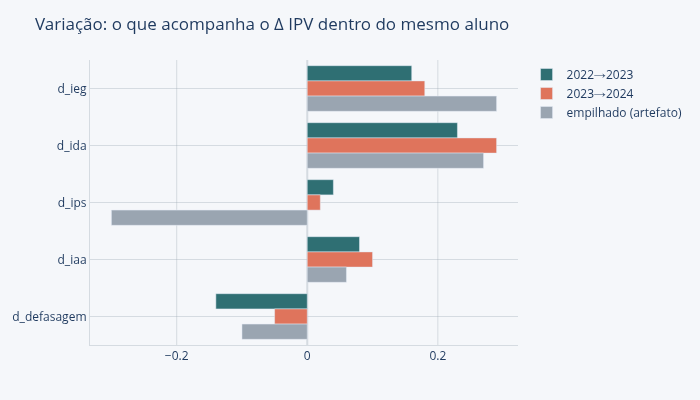

In [27]:
# ---------- Variação ----------
DFEAT7 = ['d_ieg', 'd_ida', 'd_ips', 'd_iaa', 'd_defasagem']
b7d = painel.dropna(subset=DFEAT7 + ['d_ipv'])
tab = {nome: pd.Series(LinearRegression().fit(StandardScaler().fit_transform(g[DFEAT7]), g.d_ipv).coef_,
                       index=DFEAT7)
       for nome, g in list(b7d.groupby('transicao')) + [('empilhado (artefato)', b7d)]}
tab = pd.DataFrame(tab).round(2)
print('Variação — d_ipv ~ ' + ' + '.join(DFEAT7) + ' (coeficientes padronizados)')
print(tab.to_string())
print(f'\nn por transição: {b7d.transicao.value_counts().sort_index().to_dict()} | '
      f'{b7d.id_aluno.nunique()} alunos distintos')

fig = go.Figure()
for nome, cor in zip(tab.columns, [TEAL, CORAL, CINZA]):
    fig.add_bar(y=tab.index, x=tab[nome], orientation='h', name=nome, marker_color=cor,
                hovertemplate='%{y}: %{x:.2f}<extra>' + nome + '</extra>')
fig.update_yaxes(autorange='reversed')
fig.update_layout(barmode='group', title='Variação: o que acompanha o Δ IPV dentro do mesmo aluno',
                  legend_title='')
aplicar_tema(fig, 400).show()


**Leitura da camada de variação.** A hierarquia sobrevive à troca de nível por variação, e é esta camada que
interessa para intervenção: quando o mesmo aluno melhora em desempenho e em engajamento, o ponto de virada
dele sobe. O Δ IDA entra com 0,23 e 0,29 nas duas transições e o Δ IEG com 0,16 e 0,18 — coeficientes menores
que os de nível, mas estáveis entre as transições e com o sinal esperado, sobre 436 e 539 transições de 643
alunos distintos.

O Δ IAA contribui pouco (0,08 e 0,10) e o Δ defasagem entra negativo e modesto (−0,14 e −0,05). Como a P6
mostrou para o IPP, variação contra variação responde ao ponto de partida antes de responder ao aluno, e
esse coeficiente não autoriza ler que recuperar fase atrapalhe o ponto de virada.

**A terceira coluna da tabela é um alerta, não um resultado.** Ela empilha as duas transições numa regressão
só, e o coeficiente do Δ IPS passa de +0,04 e +0,02 — praticamente zero — para **−0,30**, forte e de sinal
trocado. Lida de frente, ela diria que melhorar o psicossocial derruba o ponto de virada. Nenhuma conclusão
desta seção sai dela: ela está na tabela para que o leitor veja o efeito acontecer. Por que empilhar
transições inverte sinais, e em que outros lugares deste relatório isso acontece, está na P11.

In [28]:
# Dentro de uma transição cada aluno aparece uma única vez, então o GroupKFold aqui é apenas um KFold
# embaralhado por aluno - não há vazamento possível.
for nome, g in b7d.groupby('transicao'):
    s = cross_val_score(RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
                        g[DFEAT7], g.d_ipv, cv=GroupKFold(5), groups=g.id_aluno, scoring='r2')
    print(f'R² da variação em {nome} (RandomForest, GroupKFold 5): {s.mean():.2f} ± {s.std():.2f}')


R² da variação em 2022→2023 (RandomForest, GroupKFold 5): 0.02 ± 0.06


R² da variação em 2023→2024 (RandomForest, GroupKFold 5): 0.10 ± 0.04


### Resposta da P7

**Desempenho e engajamento — mas a resposta muda conforme a pergunta seja onde o aluno está ou para onde ele
vai.** Entre alunos, IDA e IEG explicam o IPV com folga sobre os demais (0,38 e 0,36 padronizados, R² de 0,42
validado por aluno). Dentro do mesmo aluno os dois continuam liderando (0,23–0,29 e 0,16–0,18), mas o modelo
inteiro explica pouco: R² de 0,02 em 2022→2023 e 0,10 em 2023→2024.

**A distância entre 0,42 e 0,10 é o achado, não um defeito do modelo.** Os indicadores de um aluno dizem
muito sobre a situação dele e pouco sobre o quanto ele vai melhorar no ano seguinte. Descrever posição é
fácil; prever movimento é difícil, e qualquer promessa sobre quanto um aluno vai subir depois de uma
intervenção esbarra nesse limite.

**O que a seção não estabelece.** Causa. Um aluno que passa por um bom ano melhora em IDA, IEG e IPV ao mesmo
tempo, e nada aqui separa o que puxa o quê. Também não estabelece que o psicossocial não importe: o
coeficiente do IPS é pequeno onde é confiável e grande onde é artefato, e a P5 explica por quê.

**Frentes:**

1. **Mirar entrega, presença e desempenho, nessa ordem de custo.** São os dois insumos que acompanham o IPV
   nas duas camadas, e o IEG é o que a associação consegue mexer dentro do ano sem esperar o boletim (P3).
2. **Não prometer magnitude.** O programa pode dizer com segurança em que direção o ponto de virada anda;
   quanto ele anda, este modelo não sabe, e o R² de 0,02 na primeira transição é o tamanho honesto dessa
   ignorância.
3. **Tratar o IPV como resultado, não como insumo de triagem.** Ele resume o que os outros indicadores já
   disseram. Para priorizar atendimento, a P8 e a P9 mostram sinais que chegam antes.

## P8 — Que combinações de indicadores mais elevam o INDE?

O INDE **não é uma medida independente**: o relatório PEDE o define como soma ponderada dos próprios
indicadores (IAN 0,1 / IDA 0,2 / IEG 0,2 / IAA 0,1 / IPS 0,1 / IPP 0,1 / IPV 0,2). A validação por
regressão sobre a base atual está abaixo — e, como esperado para um índice determinístico, ela apenas
recupera os pesos oficiais, com R² ≈ 1 e ganho nulo ao incluir interações. A versão não trivial da
pergunta é outra: **quais indicadores respondem, na prática, pela variação do INDE entre alunos** —
decomposição da variância do índice na contribuição de cada termo ponderado, que combina o peso nominal
com a dispersão real e as correlações da base.


In [29]:
# ---------- A regressão só recupera a fórmula oficial ----------
FEAT8 = list(PESOS)
b8 = df.dropna(subset=FEAT8 + ['inde'])          # fase 8 sai: não tem IPP (rubrica própria)
X8, y8 = b8[FEAT8], b8['inde']

ols8 = LinearRegression().fit(X8, y8)
t8 = pd.DataFrame({'coef_regressao': ols8.coef_, 'peso_oficial': list(PESOS.values())}, index=FEAT8)
print(t8.round(4))
print(f'\nR² = {ols8.score(X8, y8):.6f} | intercepto = {ols8.intercept_:.4f} | '
      f'resíduo máx = {(y8 - ols8.predict(X8)).abs().max():.4f} (n = {len(b8)})')

# O alvo aqui é reproduzir uma identidade algébrica, e uma avaliação sem os sete termos não tem como somar.
# A exclusão não escolhe lado, mas continua tendo tamanho, e o tamanho vai impresso.
fora8 = ~df.index.isin(b8.index)
print(f'Ficam de fora {fora8.sum()} avaliações às quais falta algum dos sete indicadores, '
      f'{(fora8 & (df.fase == 8)).sum()} delas na fase 8.')

Xi8 = PolynomialFeatures(2, interaction_only=True, include_bias=False).fit_transform(X8)
print(f'R² com interações de 2ª ordem: {LinearRegression().fit(Xi8, y8).score(Xi8, y8):.6f} — ganho nulo')

     coef_regressao  peso_oficial
ian          0.1001           0.1
ida          0.2000           0.2
ieg          0.2000           0.2
iaa          0.1002           0.1
ips          0.1003           0.1
ipp          0.0999           0.1
ipv          0.1995           0.2

R² = 0.999988 | intercepto = 0.0003 | resíduo máx = 0.0138 (n = 2845)
Ficam de fora 185 avaliações às quais falta algum dos sete indicadores, 127 delas na fase 8.
R² com interações de 2ª ordem: 0.999988 — ganho nulo


**Leitura.** A regressão devolve exatamente os pesos oficiais — 0,2000 para IDA e IEG, 0,1995 para o IPV,
0,1001 para o IAN, e assim por diante — com R² de 0,999988, intercepto de 0,0003 e resíduo máximo de 0,0138
sobre 2.845 avaliações. Interações de segunda ordem não acrescentam nada. É a confirmação empírica de que o
INDE é derivado, não observado: "que combinação eleva o INDE" tem resposta fechada, e ela é a própria
fórmula. Ficam de fora 185 avaliações às quais falta algum dos sete indicadores, 127 delas na fase 8.

É também a prova de que a penalidade das recusas de autoavaliação (P4) está dentro do índice por decisão de
desenho, e não por acidente de cálculo: esta célula usa o `iaa` como publicado, com os zeros, e é assim que
o INDE oficial se reproduz até a quarta casa decimal.

     contribuicao_variancia_%  peso_oficial_%  desvio_padrao
ida                      31.0            20.0           1.96
ieg                      23.6            20.0           1.57
ipv                      15.8            20.0           1.09
iaa                      10.5            10.0           2.62
ian                      10.3            10.0           2.51
ipp                       5.3            10.0           1.16
ips                       3.6            10.0           1.78


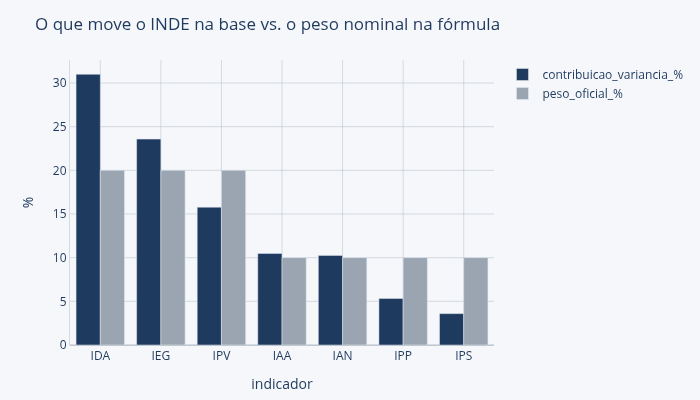

In [30]:
# ---------- O que a fórmula não diz: a variância real do índice ----------
# contribuição de cada termo ponderado à variância do INDE: cov(peso·x, inde) / var(inde) — soma 100%
share8 = pd.Series({f: PESOS[f] * np.cov(b8[f], y8)[0, 1] / y8.var() for f in FEAT8}) \
           .sort_values(ascending=False) * 100
comp8 = pd.DataFrame({'contribuicao_variancia_%': share8,
                      'peso_oficial_%': pd.Series(PESOS) * 100,
                      'desvio_padrao': b8[FEAT8].std()}).loc[share8.index]
print(comp8.round({'contribuicao_variancia_%': 1, 'peso_oficial_%': 1, 'desvio_padrao': 2}))

# Só as duas primeiras colunas viram barra. O desvio padrão fica na tabela porque é metade da explicação da
# diferença entre elas, e não uma terceira grandeza para comparar de olho com as outras duas.
fig = go.Figure()
for serie, cor in zip(comp8.columns[:2], [AZUL, CINZA]):
    fig.add_bar(x=comp8.index.str.upper(), y=comp8[serie], name=serie, marker_color=cor,
                hovertemplate='%{y:.1f}%<extra></extra>')
fig.update_layout(barmode='group', title='O que move o INDE na base vs. o peso nominal na fórmula',
                  xaxis_title='indicador', yaxis_title='%', hovermode='x unified')
aplicar_tema(fig, 400).show()

**Leitura.** A decomposição da variância mostra o que a fórmula não diz. Os pesos nominais dão 20% a IDA, IEG
e IPV e 10% aos outros quatro; a influência real sobre a variação do índice entre alunos é bem menos igual:
**IDA responde por 31,0%, IEG por 23,6% e IPV por 15,8%** — 70,4% do índice inteiro — enquanto o IPS entra
com 3,6%, pouco mais de um terço do peso que a fórmula lhe deu.

A parcela de cada indicador soma três coisas: o peso nominal, o quanto ele varia entre alunos e o quanto ele
anda junto do resto do índice. O IPV pesa 20% e é o indicador menos disperso da base (desvio padrão de 1,09),
o que o segura em 15,8%; o IPP tem dispersão parecida (1,16) com metade do peso, e fecha em 5,3%. A terceira
parcela é a que costuma surpreender: o IAA tem a maior dispersão da base (2,62) e ainda assim fica em 10,5%,
porque quase não acompanha os demais indicadores.

Três ressalvas que a barra sozinha não mostra. A parcela mede variação **entre alunos**, não evolução no
tempo — nada aqui diz o que muda de um ano para o outro. Como a conta vem de covariâncias, um indicador
também ganha crédito por andar junto dos outros: IDA e IEG são correlacionados (P3), então parte das duas
parcelas é sinal compartilhado, não influência isolada de cada um. E os 10,5% do IAA estão inflados pelas
recusas de 2023, que criam dispersão sem que ela seja variação de autoavaliação (P4).

### P8b — E o que mais se associa à defasagem (`defasagem`)?

Se o INDE é derivado, a associação operacionalmente útil é com a **defasagem** — a distância do aluno
para a fase ideal, o problema que o programa existe para corrigir. Método: regressão linear padronizada
+ importâncias de RandomForest para `defasagem ~ ida + ieg + iaa_val + ips + ipp + ipv` (IAN e INDE ficam
de fora: ambos derivam de `defasagem` por construção; o IAA entra como `iaa_val`, sem as recusas), R²
validado por GroupKFold (grupos = aluno), interações de 2ª ordem e comparação de médias entre grupos de
defasagem.


         coef_padronizado (LR)  importancia (RF)
ipp                       0.17              0.21
ipv                       0.03              0.20
ieg                       0.06              0.18
ida                       0.04              0.17
iaa_val                  -0.00              0.12
ips                       0.03              0.12



R² (GroupKFold 5): linear 0.07 ± 0.02 | +interações 0.07 ± 0.02 | RF 0.11 ± 0.03

Interações mais fortes (|coef| padronizado):
ida ipv   -0.10
ipp ipv    0.07
ida ieg    0.06
dtype: float64

Média dos indicadores por grupo de defasagem, com a contagem antes das médias:
                     n   ida   ieg  iaa_val   ips   ipp   ipv
defasagem                                                    
severa (≤ -3)       39  4.75  7.07     8.41  5.89  6.67  6.70
moderada (-2/-1)  1485  6.29  8.15     8.66  6.39  6.98  7.44
em fase (≥ 0)     1076  6.66  8.48     8.70  6.37  7.41  7.73


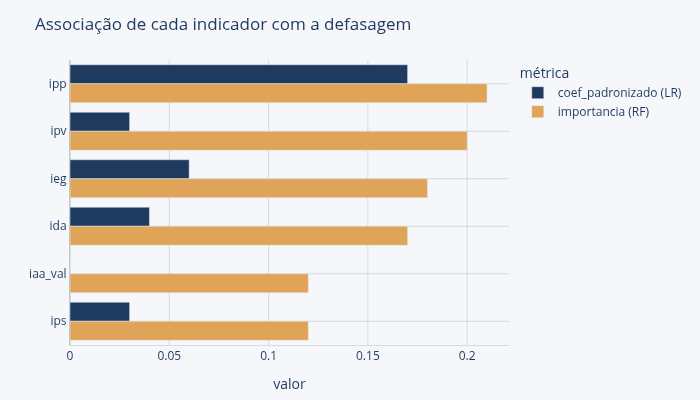

In [31]:
# 'iaa' entra aqui como 'iaa_val': a recusa de autoavaliação é ausência, não nota zero (ver P4).
FEAT8B = ['ida', 'ieg', 'iaa_val', 'ips', 'ipp', 'ipv']
b8b = df.dropna(subset=FEAT8B + ['defasagem'])
Xb, yb = b8b[FEAT8B], b8b['defasagem']               # defasagem: negativo = atrás da fase ideal

coefs_b = pd.Series(LinearRegression().fit(StandardScaler().fit_transform(Xb), yb).coef_, index=FEAT8B)
rf_b = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1).fit(Xb, yb)
comp_b = pd.DataFrame({'coef_padronizado (LR)': coefs_b,
                       'importancia (RF)': rf_b.feature_importances_}) \
           .sort_values('importancia (RF)', ascending=False).round(2)
print(comp_b)

gkf = GroupKFold(5)
r2_lin = cross_val_score(LinearRegression(), Xb, yb, cv=gkf, groups=b8b.id_aluno, scoring='r2')
r2_rf = cross_val_score(rf_b, Xb, yb, cv=gkf, groups=b8b.id_aluno, scoring='r2')
pf_b = PolynomialFeatures(2, interaction_only=True, include_bias=False)
Xbi = pf_b.fit_transform(StandardScaler().fit_transform(Xb))
r2_int = cross_val_score(LinearRegression(), Xbi, yb, cv=gkf, groups=b8b.id_aluno, scoring='r2')
print(f'\nR² (GroupKFold 5): linear {r2_lin.mean():.2f} ± {r2_lin.std():.2f} | '
      f'+interações {r2_int.mean():.2f} ± {r2_int.std():.2f} | RF {r2_rf.mean():.2f} ± {r2_rf.std():.2f}')

nomes = pf_b.get_feature_names_out(FEAT8B)
inter = pd.Series(LinearRegression().fit(Xbi, yb).coef_, index=nomes).filter(like=' ')
print('\nInterações mais fortes (|coef| padronizado):')
print(inter.reindex(inter.abs().sort_values(ascending=False).index).head(3).round(2))

grupo = pd.cut(b8b.defasagem, [-10, -3, -1, 10],
               labels=['severa (≤ -3)', 'moderada (-2/-1)', 'em fase (≥ 0)'])
tab8b = b8b.groupby(grupo, observed=True)[FEAT8B].mean().round(2)
tab8b.insert(0, 'n', b8b.groupby(grupo, observed=True).size())
print('\nMédia dos indicadores por grupo de defasagem, com a contagem antes das médias:')
print(tab8b.to_string())

fig = go.Figure()
for metrica, cor in zip(comp_b.columns, [AZUL, AMBAR]):
    fig.add_bar(y=comp_b.index, x=comp_b[metrica], orientation='h', name=metrica, marker_color=cor,
                hovertemplate='%{y}: %{x:.2f}<extra>' + metrica + '</extra>')
fig.update_layout(barmode='group', title='Associação de cada indicador com a defasagem',
                  xaxis_title='valor', legend_title='métrica')
fig.update_yaxes(autorange='reversed')
aplicar_tema(fig, 400).show()

**Leitura.** A associação é real e modesta: os seis indicadores do mesmo ano explicam 7% da variação da
defasagem na regressão linear e 11% no RandomForest, com as interações de segunda ordem não acrescentando
nada que a validação consiga distinguir (0,07 contra 0,07). Faz sentido — a defasagem é uma condição
estrutural, construída no histórico escolar anterior ao programa, e os indicadores do ano corrente a
refletem só em parte.

O gradiente entre grupos, esse, é claro: alunos com defasagem severa têm IDA médio de 4,75 contra 6,66 dos
que estão em fase, e IPP de 6,67 contra 7,41. A ressalva de tamanho vale aqui também — são 39 alunos no grupo
severo, contra 1.485 moderados e 1.076 em fase.

**O IPP é a associação mais forte, e o único indicador que lidera nos dois métodos** (0,17 padronizado e 0,21
de importância). O IPV pesa quase o mesmo no RandomForest (0,20) com coeficiente linear de 0,03, o que indica
relação não linear e não peso comparável. O IAA, uma vez retiradas as recusas, fica em −0,00: coerente com a
P4, ele não mede desempenho nem condição escolar.

A versão *preditiva* desta pergunta — indicadores do ano t antecipando a defasagem em t+1 — é o modelo da P9,
e é lá que os mesmos indicadores rendem bem mais. Eles funcionam melhor como alarme do que como explicação
do presente.

### Resposta da P8

**A pergunta tem duas respostas, e só a segunda é útil.** Do jeito que foi feita, ela tem solução fechada: o
INDE é soma ponderada dos sete indicadores, a regressão devolve os pesos oficiais até a quarta casa decimal,
e a combinação que mais eleva o índice é a que a própria fórmula manda. Não há descoberta possível aí.

**O que se descobre é o descompasso entre o peso na fórmula e a influência na base.** IDA, IEG e IPV
respondem por 70,4% da variação do índice entre alunos, contra 60% de peso nominal; IPS e IPP, com 10% cada
na fórmula, entram com 3,6% e 5,3%. Quem lê o INDE presume que os sete pesos valham o que está escrito, e na
prática dois indicadores explicam mais da metade da variação.

**E é aí que o IPP vira o achado.** Ele é o penúltimo em influência sobre o INDE (5,3%) e, ao mesmo tempo, o
indicador mais associado à defasagem entre alunos — o único que lidera nos dois métodos — e o segundo sinal
mais forte do risco do ano seguinte na P9 (−0,42). **Triar alunos pelo INDE, ou pela pedra derivada dele,
descarta justamente o indicador que mais antecipa o problema que o programa existe para corrigir.**

**O que a seção não estabelece.** A ordem exata do ranking de importâncias: as quatro primeiras ficam entre
0,21 e 0,17, distância pequena demais para sustentar posições. O que se sustenta é que o IPP lidera nos dois
métodos enquanto IPV, IEG e IDA lideram em um só. Também não estabelece causa — um R² de 0,07 linear e 0,11
no RandomForest diz que os indicadores do mesmo ano explicam pouco de uma condição trazida de antes do
programa. E o grupo de defasagem severa tem 39 alunos entre 2.600: o IDA médio de 4,75 contra 6,66 é uma
diferença grande apoiada em pouca gente.

**Frentes:**

1. **Não priorizar atendimento só pelo INDE.** Ele é um bom resumo do presente e um péssimo alarme: o
   indicador que mais antecipa defasagem é o que ele menos escuta.
2. **Publicar a decomposição junto com o índice.** Um leitor que veja apenas a fórmula acredita que o IPS
   pesa o mesmo que o IAN. Na base, ele pesa um terço.
3. **Revisar o tratamento do IAA dentro do índice.** Ele contribui com 10,5% da variação, e parte disso são
   os zeros de recusa da P4 — dispersão que não é variação de autoavaliação.

## P9 — É possível prever, com antecedência, alunos em risco de defasagem?

**Desenho early-warning (t→t+1):** prever se o aluno estará defasado no ano
seguinte usando os indicadores do ano corrente. Evita a circularidade de usar
IAN/defasagem do próprio ano-alvo (que *definem* o alvo).

Abaixo, a força de cada indicador do ano t como sinal do risco em t+1 — evidência
que motiva as features do modelo. O modelo completo (baseline logístico,
RandomForest e rede neural Keras) está em `04_modelagem.ipynb`.

> **População:** as transições abaixo são todas as que o painel permite formar. A base do
> modelo (`base_risco.csv`, montada em `03_features.py`) é menor porque acrescenta um
> filtro de treino — exige INDE no ano t, sem o qual não há features que sustentem a
> predição. Daí 1.365 transições aqui e 1.290 lá: a diferença é o recorte de modelagem, não
> divergência de dados.


transições t→t+1: 1365 | taxa de defasagem em t+1: 49.4%

Força de cada indicador do ano t como sinal da defasagem em t+1:
               correlacao     n  t = 2022  t = 2023
defasagem           -0.47  1365     -0.46     -0.44
ipp                 -0.42  1293     -0.35     -0.45
ian                 -0.40  1365     -0.41     -0.35
inde                -0.34  1290     -0.35     -0.31
ipv                 -0.34  1293     -0.33     -0.28
ieg                 -0.22  1293     -0.17     -0.22
ida                 -0.21  1293     -0.18     -0.23
tempo_vinculo       -0.18  1365     -0.14     -0.20
idade               -0.17  1365     -0.02     -0.24
iaa                  0.01  1306     -0.00     -0.04
ips                  0.16  1303     -0.01      0.13


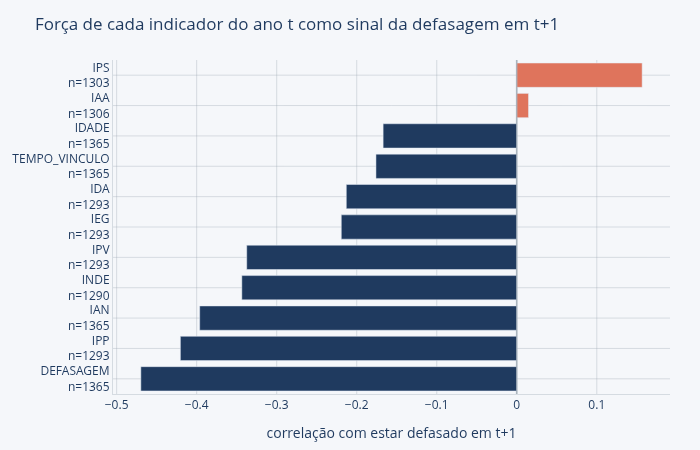

In [32]:
nxt9 = df[['id_aluno', 'ano', 'defasado']].copy()
nxt9['ano'] -= 1
p9 = df.merge(nxt9, on=['id_aluno', 'ano'], suffixes=('', '_t1'))
p9 = p9[p9.defasado_t1.notna()].copy()
p9['alvo'] = p9.defasado_t1.astype(bool).astype(int)
print(f'transições t→t+1: {len(p9)} | taxa de defasagem em t+1: {p9.alvo.mean() * 100:.1f}%')

# Cada indicador tem a sua própria população, porque nem todo aluno tem todos os indicadores medidos. O n
# vai junto no gráfico: uma correlação forte apurada em poucas transições não vale o mesmo que uma fraca
# apurada em todas. E como o gráfico empilha as duas pontas do painel, a conta é refeita dentro de cada ano
# de partida - empilhar pode criar sinal que não existe em nenhum dos dois anos.
sinais = {}
for c in IND + ['defasagem', 'idade', 'tempo_vinculo']:
    b = p9.dropna(subset=[c])
    sinais[c] = {'correlacao': stats.pointbiserialr(b.alvo, b[c])[0], 'n': len(b)}
    for ano, g in b.groupby('ano'):
        sinais[c][f't = {ano}'] = stats.pointbiserialr(g.alvo, g[c])[0]
s9 = pd.DataFrame(sinais).T.sort_values('correlacao').astype({'n': int})
print('\nForça de cada indicador do ano t como sinal da defasagem em t+1:')
print(s9.round(2).to_string())

fig = go.Figure(go.Bar(y=rotulo_n([i.upper() for i in s9.index], s9.n), x=s9.correlacao.to_numpy(),
                       orientation='h', customdata=s9.n.to_numpy(),
                       marker_color=[CORAL if v > 0 else AZUL for v in s9.correlacao],
                       hovertemplate='%{x:+.2f}  ·  %{customdata:.0f} transições<extra></extra>'))
fig.add_vline(x=0, line=dict(color=CINZA, width=1))
fig.update_layout(title='Força de cada indicador do ano t como sinal da defasagem em t+1',
                  xaxis_title='correlação com estar defasado em t+1', showlegend=False)
aplicar_tema(fig, 450).show()

**Leitura.** A previsão é viável, e os sinais mais fortes são os que descrevem a posição escolar do aluno: a
própria defasagem em t (−0,47), o IPP (−0,42), o IAN (−0,40) e o INDE (−0,34). Todos apontam na direção
esperada — quanto pior o indicador em t, maior a chance de estar defasado em t+1 — sobre 1.365 transições com
alvo quase equilibrado (49,4% ficam defasados). Cada barra traz o próprio n no rótulo, porque nem todo aluno
tem todos os indicadores medidos: defasagem e IAN existem nas 1.365 transições, o INDE em 1.290.

**Duas barras não sobrevivem à conferência por ano de partida, e são justamente as duas positivas.** O IPS
aparece com +0,16 somando as duas pontas do painel, mas dentro de cada ano é −0,01 em 2022 e +0,13 em 2023:
a barra empilhada é maior do que qualquer um dos anos que a compõem, e o único ano em que ela existe é o do
piso de escala descrito na P5. Com o IAA é ainda mais claro: +0,01 empilhado, contra −0,00 e −0,04 dentro dos
anos. Nenhum dos dois pode ser lido como "quanto melhor o indicador, maior o risco".

A idade merece a mesma ressalva por outro motivo: −0,02 em 2022 contra −0,24 em 2023. É sinal de um ano, não
do aluno. Os quatro primeiros, ao contrário, se repetem nos dois anos — o IPP vai de −0,35 a −0,45 e a
defasagem de −0,46 a −0,44 — e é sobre eles que o modelo se apoia.

In [33]:
# ---------- O modelo vale o que ele acrescenta ao palpite óbvio ----------
# O palpite óbvio é a persistência: quem está defasado hoje continuará defasado no ano que vem. Um modelo
# que não bate esse palpite não está aprendendo nada que a associação já não saiba de graça. As duas contas
# saem nas mesmas duas métricas do modelo, senão a comparação não é comparação.
base9 = p9.dropna(subset=['defasado'])
palpite, alvo9 = base9.defasado.astype(bool), base9.alvo.astype(bool)
vp, fp = (palpite & alvo9).sum(), (palpite & ~alvo9).sum()
print(f'Palpite de persistência, em {len(base9)} transições: acerta {(palpite == alvo9).mean() * 100:.0f}% '
      f'das vezes; dos {alvo9.sum()} que ficaram defasados ele aponta {vp} ({vp / alvo9.sum() * 100:.0f}%), '
      f'e dos {vp + fp} que ele aponta {vp} ({vp / (vp + fp) * 100:.0f}%) realmente ficam.')

# As métricas abaixo são as do modelo salvo em models/, medidas no conjunto de teste que ele nunca viu. Vêm
# do arquivo, e não de um novo ajuste aqui, para que o número do texto seja o mesmo do modelo em produção.
try:
    import json
    with open('../models/risk_metadata.json', encoding='utf-8') as arq:
        meta9 = json.load(arq)
    m9 = meta9['metricas_teste'][meta9['campeao']]
    print(f"\nModelo campeão: {meta9['campeao']}, treinado em {meta9['n_treino']} transições e testado em "
          f"{meta9['n_teste']} que ele nunca viu.")
    print(f"  de cada 10 alunos que vão ficar defasados, ele aponta {m9['recall'] * 10:.0f} "
          f"(recall {m9['recall']:.2f})")
    print(f"  de cada 10 alunos que ele aponta, {m9['precisao'] * 10:.0f} realmente ficam "
          f"(precisão {m9['precisao']:.2f})")
    print(f"  colocando dois alunos lado a lado, acerta qual dos dois corre mais risco em "
          f"{m9['roc_auc'] * 100:.0f}% das vezes (ROC-AUC {m9['roc_auc']:.2f})")
    print(f"  as duas primeiras linhas dependem de um corte; o limiar de {meta9['limiar_padrao']} é o padrão "
          f"do modelo, e pode ser trocado pela capacidade de atendimento. A terceira não depende de corte.")
except FileNotFoundError:
    print('\nmodels/risk_metadata.json não encontrado: rode 04_modelagem.ipynb para gerar as métricas.')

Palpite de persistência, em 1365 transições: acerta 69% das vezes; dos 674 que ficaram defasados ele aponta 530 (79%), e dos 806 que ele aponta 530 (66%) realmente ficam.

Modelo campeão: RandomForest, treinado em 1029 transições e testado em 261 que ele nunca viu.
  de cada 10 alunos que vão ficar defasados, ele aponta 8 (recall 0.82)
  de cada 10 alunos que ele aponta, 8 realmente ficam (precisão 0.77)
  colocando dois alunos lado a lado, acerta qual dos dois corre mais risco em 87% das vezes (ROC-AUC 0.87)
  as duas primeiras linhas dependem de um corte; o limiar de 0.5 é o padrão do modelo, e pode ser trocado pela capacidade de atendimento. A terceira não depende de corte.


**Leitura.** O palpite óbvio já acerta muito. Supor que quem está defasado hoje continuará defasado no ano que
vem acerta 69% das 1.365 transições: aponta 530 dos 674 que de fato ficaram (79%) e, dos 806 alunos que
aponta, 530 realmente ficam (66%). Qualquer modelo precisa ser medido contra isso antes de ser chamado de
útil.

O modelo campeão do `04_modelagem.ipynb` — um RandomForest treinado em 1.029 transições e medido em 261 que
nunca viu — aponta 8 de cada 10 alunos que vão ficar defasados (recall 0,82) e acerta 8 de cada 10 que aponta
(precisão 0,77). Contra o palpite de persistência, o ganho não está em encontrar mais alunos, e sim em errar
menos: capacidade de encontrar praticamente igual (79% contra 82%) com cerca de onze pontos a mais de
precisão. As duas contas não estão na mesma população — o palpite é medido nas 1.365 transições e o modelo
nas 261 de teste —, e a diferença é grande o bastante para sobreviver a isso, mas o número exato não é
comparável casa a casa.

O ROC-AUC de 0,87 diz outra coisa, e mais útil na prática: postos dois alunos lado a lado, o modelo acerta em
87% das vezes qual dos dois corre mais risco. É uma afirmação sobre a **ordem** da fila, e a ordem é a única
parte do modelo que não depende de escolher um limiar.

### Resposta da P9

**Sim, com um ano de antecedência.** Os indicadores do ano corrente ordenam bem o risco do ano seguinte: o
modelo acerta em 87% das vezes qual de dois alunos corre mais risco, aponta 8 de cada 10 que vão ficar
defasados e acerta 8 de cada 10 apontados. E acrescenta ao palpite de persistência, que já acerta 69%:
aponta praticamente os mesmos alunos com onze pontos a mais de precisão — o que, numa fila de atendimento
com vagas limitadas, é exatamente a diferença que importa.

**O desenho t→t+1 é necessidade, não elegância.** Estar defasado é, por definição, ter IAN baixo; prever a
defasagem de um ano com os indicadores do mesmo ano seria perguntar ao dado o que ele já sabe. Separar as
duas pontas é o que transforma descrição em antecipação — e é também o que faz o IPP, responsável por apenas
5,3% da variação do INDE (P8), aparecer como o segundo sinal mais forte da lista.

**O que a seção não estabelece.** Que os alunos apontados vão ficar defasados: o modelo devolve
probabilidade, e um em cada quatro apontados não fica. Também não estabelece nada sobre IPS e IAA — as barras
positivas dos dois não sobrevivem à conferência por ano, e usá-las colocaria a fila em ordem invertida.

**Frentes:**

1. **Usar o modelo como ordem de fila, não como carimbo.** Ordenar os alunos pela probabilidade e atender de
   cima para baixo até a capacidade acabar. O limiar de 0,5 é o corte padrão do modelo, não uma fronteira do
   fenômeno, e a parte confiável dele é a ordenação.
2. **Rodar a lista no início do ano letivo.** Todo o valor do desenho está em ter o nome antes do resultado.
   Uma lista gerada depois do fechamento do ano descreve o que já aconteceu.
3. **Levar o IPP para dentro da triagem.** Depois da própria defasagem, é o indicador que mais antecipa
   risco — e é um dos que menos pesam no índice usado hoje para priorizar.

## P10 — O programa é efetivo?

A pergunta é sobre o programa, não sobre um indicador, e por isso ela não tem um número só como resposta.
Efetividade, aqui, quer dizer uma coisa verificável: os mesmos alunos, acompanhados ao longo do tempo, ficam
melhor do que estavam.

A seção vai em três camadas, cada uma respondendo ao limite da anterior.

1. **A variação do INDE dentro do aluno, por fase de chegada.** É a camada mais ampla — usa todo o painel de
   transições — e serve para saber se existe alguma fase em que o índice global anda de forma sustentada.
2. **A coorte que atravessa os três anos.** A camada 1 compara o aluno consigo mesmo, mas não fixa quem está
   sendo comparado: cada transição traz um conjunto diferente de alunos. Ler 2022 a 2024 como uma trajetória
   exige fechar a população em quem aparece nos três anos. Essa escolha tem um custo grande, e ele é medido
   no mesmo lugar em que ela é feita.
3. **De onde vem, ou não vem, o movimento do índice.** Se o INDE da coorte ficar parado, "ficou parado" ainda
   não é resposta: pode ser que nada tenha andado, ou que o que subiu tenha sido compensado pelo que desceu.
   As duas hipóteses levam a decisões opostas, e a terceira camada as separa.

Transições com fase de chegada até a 7: 1273. Sem INDE numa das pontas, e por isso sem variação a medir: 25.

Δ INDE por transição e fase de chegada:
                   media    n  melhoraram  melhoraram_%
transicao fase_t1                                      
2022→2023 0.0      -0.08   77          40         51.95
          1.0       0.10  116          69         59.48
          2.0       0.07  129          72         55.81
          3.0      -0.08  103          47         45.63
          4.0      -0.06   66          29         43.94
          5.0      -0.50   47           8         17.02
          6.0       0.16   26          12         46.15
          7.0       0.48    6           4         66.67
2023→2024 0.0      -0.52   77          18         23.38
          1.0      -0.03  127          63         49.61
          2.0      -0.10  120          57         47.50
          3.0      -0.23  167          66         39.52
          4.0       0.22   75          52         69.33
          

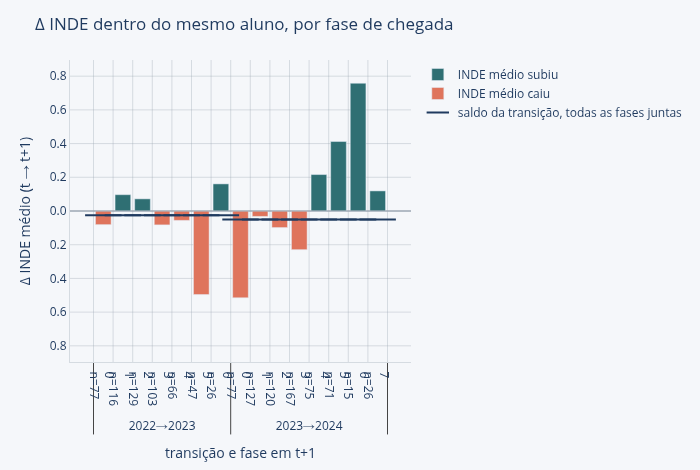

In [34]:
# ---------- Camada 1: a variação do INDE dentro do mesmo aluno, fase por fase ----------
# Fase 8 fica fora porque universitário não tem INDE avaliado — a série seria uma entrada morta na legenda.
# As demais regras do painel são as da nota metodológica e não se repetem aqui.
p10 = painel[painel.fase_t1 <= 7]
b10 = p10.dropna(subset=['d_inde'])
print(f'Transições com fase de chegada até a 7: {len(p10)}. Sem INDE numa das pontas, e por isso sem '
      f'variação a medir: {len(p10) - len(b10)}.')

fase10 = b10.groupby(['transicao', 'fase_t1']).d_inde.agg(
    media='mean', n='size', melhoraram=lambda s: (s > 0).sum())
fase10['melhoraram_%'] = fase10.melhoraram / fase10.n * 100
print('\nΔ INDE por transição e fase de chegada:')
print(fase10.round(2).to_string())
print('\nSaldo de cada transição, todas as fases juntas:')
print(b10.groupby('transicao').d_inde.agg(media='mean', n='size').round(2).to_string())

finas10 = fase10[fase10.n < MIN_CELULA]
print(f'\nFora do gráfico, por terem menos de {MIN_CELULA} alunos: '
      + (', '.join(f'{t} fase {f:g} (n = {v})' for (t, f), v in finas10.n.items()) or 'nenhuma célula')
      + '.')

grosso10 = fase10[fase10.n >= MIN_CELULA]
media10 = b10.groupby('transicao').d_inde.mean()
barras_variacao(grosso10, 'Δ INDE dentro do mesmo aluno, por fase de chegada',
                'transição e fase em t+1', 'Δ INDE médio (t → t+1)',
                nomes=('INDE médio subiu', 'INDE médio caiu'), passo=0.2,
                referencia=[media10[t] for t, _ in grosso10.index],
                nome_ref='saldo da transição, todas as fases juntas').show()

**Leitura da camada por fase.** O saldo das duas transições é praticamente nulo: −0,02 de variação média do
INDE em 2022→2023, sobre 570 transições, e −0,05 em 2023→2024, sobre 678. Lida só por aí, esta camada diria
que nada acontece. Aberta por fase, ela diz outra coisa.

Em 2023→2024 o painel se parte ao meio. As fases de chegada 0 a 3 caem — a fase 0 é o fundo, com −0,52 e só
23,38% dos 77 alunos melhorando — e as fases 4 a 7 sobem, com 76,06% de melhora na fase 5 e 73,08% na fase 7.
Na transição anterior o desenho não é esse: a queda estava na fase 5 (−0,50, com 17,02% melhorando) e as
fases baixas estavam paradas. O saldo perto de zero não é estabilidade, portanto; são dois movimentos de
sinais contrários que se anulam quando somados.

A fase 3 de 2023→2024 merece nota à parte, porque é ali que a P2 encontrou a maior queda de IDA do painel,
sobre um grupo do mesmo tamanho: 167 alunos dos dois lados. Aqui a queda é de −0,23 de INDE. O IDA entra no
índice com peso 0,2, e é razoável ler esta barra como aquela queda chegando ao índice global diluída pelos
outros seis indicadores — o índice não contradiz a P2, ele a amortece.

Duas coisas esta camada não separa. A primeira é quem está sendo comparado: cada transição traz um conjunto
diferente de alunos, e comparar 2022→2023 com 2023→2024 é comparar dois painéis de composição diferente. É o
que a coorte fixa, a seguir, resolve. A segunda é que cada barra é definida pela fase de **chegada**, e
chegar a uma fase mais alta é, em parte, resultado do próprio ano: quem foi promovido aparece uma fase acima
de onde estava. As fases altas de 2024 são, em boa medida, os promovidos de 2023, e por isso a comparação
entre fases não é uma comparação entre grupos equivalentes.

Alunos distintos na população da P1: 1588. Com situação de defasagem nos três anos: 468 (29% deles).
Em quantos anos cada aluno aparece: {1: 729, 2: 391, 3: 468}

Alunos defasados, dentro e fora da coorte:
      coorte_%  coorte_n  coorte_defasados  demais_%  demais_n  demais_defasados  geral_%
ano                                                                                      
2022      67.3       468               315      73.0       392               286     69.9
2023      58.1       468               272      55.8       502               280     56.9
2024      34.8       468               163      60.1       617               371     49.2

Dos 1120 alunos fora da coorte, 358 aparecem pela primeira vez em 2024, e 62.8% deles chegam já defasados.


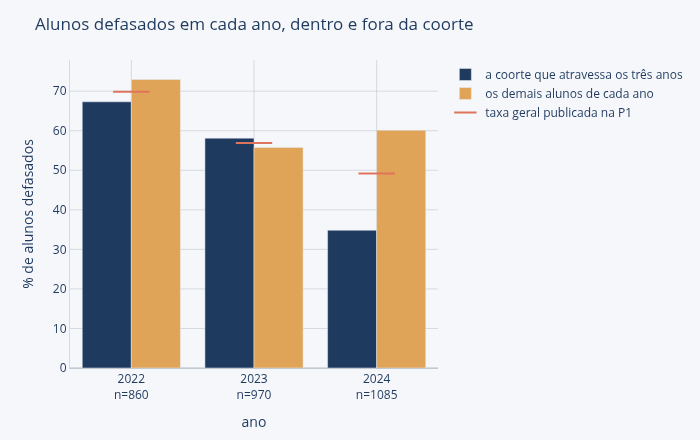

In [35]:
# ---------- Camada 2: a coorte que atravessa os três anos ----------
# A pergunta é sobre os mesmos alunos ao longo do tempo, então a população precisa ser fixa. Ela é montada
# sobre d1, a base da P1: comparar a coorte com a taxa publicada lá só faz sentido se as duas excluírem os
# universitários pelo mesmo critério. O preço da escolha vai impresso abaixo e discutido na leitura — quem
# atravessa os três anos é, por definição, quem ficou —, e é por isso que o grupo de fora entra no gráfico
# em vez de ser descartado: sem ele, a coorte não teria contra o que ser lida.
r10 = d1.assign(v=d1.defasado.astype('float')).pivot_table(index='id_aluno', columns='ano', values='v')
co10 = r10.dropna()
print(f'Alunos distintos na população da P1: {len(r10)}. Com situação de defasagem nos três anos: '
      f'{len(co10)} ({len(co10) / len(r10) * 100:.0f}% deles).')
print('Em quantos anos cada aluno aparece:',
      d1.groupby('id_aluno').ano.nunique().value_counts().sort_index().to_dict())

fora10 = r10.index.difference(co10.index)
linhas10 = []
for ano in sorted(d1.ano.unique()):
    f = r10.loc[fora10, ano].dropna()
    linhas10.append({'ano': ano, 'coorte_%': co10[ano].mean() * 100, 'coorte_n': len(co10),
                     'coorte_defasados': int(co10[ano].sum()), 'demais_%': f.mean() * 100,
                     'demais_n': len(f), 'demais_defasados': int(f.sum()),
                     'geral_%': d1[d1.ano == ano].defasado.mean() * 100})
tx10 = pd.DataFrame(linhas10).set_index('ano')
print('\nAlunos defasados, dentro e fora da coorte:')
print(tx10.round(1).to_string())

# A pergunta que decide se a queda da coorte é seleção: quem entrou depois chegou em que situação?
novos24 = set(d1[d1.ano == 2024].id_aluno) - set(d1[d1.ano < 2024].id_aluno)
e24 = r10.loc[list(novos24), 2024].dropna()
print(f'\nDos {len(fora10)} alunos fora da coorte, {len(e24)} aparecem pela primeira vez em 2024, e '
      f'{e24.mean() * 100:.1f}% deles chegam já defasados.')

SERIES10 = ['a coorte que atravessa os três anos', 'os demais alunos de cada ano']
barras_taxa(tx10[['coorte_%', 'demais_%']].set_axis(SERIES10, axis=1),
            tx10[['coorte_defasados', 'demais_defasados']].set_axis(SERIES10, axis=1),
            tx10[['coorte_n', 'demais_n']].set_axis(SERIES10, axis=1),
            'Alunos defasados em cada ano, dentro e fora da coorte', 'ano', '% de alunos defasados',
            referencia=tx10['geral_%'], nome_ref='taxa geral publicada na P1').show()

**Leitura da coorte.** Dos 1.588 alunos da população da P1, 468 têm situação de defasagem registrada nos três
anos — 29% deles. Nessa coorte a defasagem cai de 67,3% para 58,1% e depois para 34,8%: 315, 272 e 163 alunos,
sempre sobre os mesmos 468. Como a população é fixa, essa queda não pode ser efeito de composição. São as
mesmas pessoas nas três medições.

A objeção óbvia é que a coorte são os que ficaram, e quem fica é quem já estava melhor. Ela tem que ser
medida, não afastada por argumento, e por isso o grupo de fora está no mesmo gráfico. Em 2022 a coorte estava
só um pouco à frente (67,3% contra 73,0%) e em 2023 ficou atrás (58,1% contra 55,8%). A seleção existe, mas
nos dois primeiros anos ela é pequena e chega a inverter de sinal. O que abre entre os dois grupos é 2024,
quando a coorte cai para 34,8% e o resto sobe para 60,1%.

E é aí que a taxa publicada na P1 se reconcilia com a da coorte. Os 49,2% de 2024 não contradizem os 34,8%:
eles descrevem populações diferentes. Dos 1.120 alunos fora da coorte, 358 aparecem pela primeira vez em
2024, e 62,8% deles chegam já defasados. A taxa anual mistura quem está há três anos no programa com quem
acabou de entrar, e a entrada é justamente o grupo mais defasado da base. O número que a associação publica
mede resultado e demanda ao mesmo tempo.

O que esta camada responde, portanto, é o que aconteceu com quem ficou três anos — não o que acontece com
quem entra. A distinção volta na resposta da seção, porque ela muda o que se pode prometer.

Coorte com INDE nos três anos: 434 alunos.
     peso  média em 2022  média em 2024  variação  contribuição no INDE
ian   0.1           6.64           8.12      1.49                  0.15
ipp   0.1           6.25           7.51      1.26                  0.13
iaa   0.1           8.56           8.51     -0.05                 -0.00
ips   0.1           6.88           6.69     -0.19                 -0.02
ipv   0.2           7.52           7.30     -0.22                 -0.04
ida   0.2           6.69           6.22     -0.47                 -0.09
ieg   0.2           8.53           7.95     -0.58                 -0.12

Soma das contribuições: -0.003  |  variação medida do INDE da coorte: -0.003


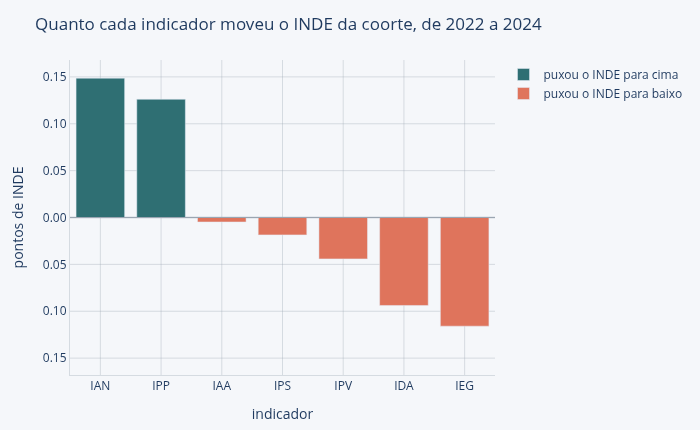

In [36]:
# ---------- Por que o INDE da coorte quase não se move ----------
# O INDE é a média ponderada dos sete indicadores, e os pesos são os que a P8 recuperou da própria base. Se
# ele ficou parado, ou nada andou, ou o que subiu foi compensado pelo que desceu — e essas duas hipóteses
# levam a decisões opostas. A conta abaixo separa as duas: quanto cada indicador moveu na coorte e quanto
# desse movimento chegou ao INDE depois de multiplicado pelo peso.
#
# A comparação é entre 2022 e 2024 e pula 2023 de propósito: a P4 mostrou que o IAA daquele ano carrega as
# recusas e a P5 mostrou que o IPS está espremido no piso da escala, então uma decomposição que passasse
# pelo ano do meio herdaria os dois artefatos. A coorte aqui é a de INDE completo nos três anos, para que a
# soma das partes possa ser conferida contra o todo medido.
wi10 = d1.pivot_table(index='id_aluno', columns='ano', values='inde').dropna()
mi10 = d1[d1.id_aluno.isin(wi10.index)].groupby('ano')[list(PESOS)].mean()
dec10 = pd.DataFrame({'peso': pd.Series(PESOS), 'média em 2022': mi10.loc[2022],
                      'média em 2024': mi10.loc[2024]})
dec10['variação'] = dec10['média em 2024'] - dec10['média em 2022']
dec10['contribuição no INDE'] = dec10.peso * dec10['variação']
dec10 = dec10.sort_values('contribuição no INDE', ascending=False)
print(f'Coorte com INDE nos três anos: {len(wi10)} alunos.')
print(dec10.round(2).to_string())
print(f"\nSoma das contribuições: {dec10['contribuição no INDE'].sum():+.3f}  |  "
      f'variação medida do INDE da coorte: {wi10[2024].mean() - wi10[2022].mean():+.3f}')

# Aqui as barras divergem e o eixo mostra o valor absoluto, como nas outras seções: o que está sendo lido é
# o tamanho do empurrão e a direção dele, e a direção já está no desenho.
dados10 = np.stack([dec10.peso, dec10['média em 2022'], dec10['média em 2024'], dec10['variação']], axis=-1)
fig10 = go.Figure()
for acima, cor, nome in [(True, TEAL, 'puxou o INDE para cima'), (False, CORAL, 'puxou o INDE para baixo')]:
    fig10.add_bar(x=[i.upper() for i in dec10.index], name=nome, marker_color=cor, customdata=dados10,
                  y=[v if (v > 0) == acima else None for v in dec10['contribuição no INDE']],
                  hovertemplate='peso %{customdata[0]:.2f}  ·  média de %{customdata[1]:.2f} para '
                                '%{customdata[2]:.2f}  (%{customdata[3]:+.2f})<extra></extra>')
fig10.update_layout(barmode='relative', title='Quanto cada indicador moveu o INDE da coorte, de 2022 a 2024',
                    xaxis_title='indicador', yaxis_title='pontos de INDE', hovermode='x unified',
                    legend_title='')
eixo_divergente(fig10, dec10['contribuição no INDE'], 0.05, casas=2)
aplicar_tema(fig10, 430).show()

**Leitura da decomposição.** Entre 2022 e 2024 o INDE médio da coorte não se move: a soma das contribuições
dá −0,003 e a variação medida do índice dá os mesmos −0,003. A conta fecha nas duas pontas, e é isso que
autoriza ler as parcelas como parcelas.

O índice ficou parado porque dois indicadores empurraram para cima e cinco puxaram para baixo. O IAN sobe
1,49 e o IPP 1,26; com peso 0,1 cada, entram no índice com +0,15 e +0,13. Contra eles, o IEG cai 0,58, o IDA
0,47 e o IPV 0,22 e, como esses três pesam 0,2, chegam ao índice com −0,12, −0,09 e −0,04. IAA e IPS
praticamente não participam.

Nenhum dos dois ganhos é o que parece. O IAN é o indicador de adequação de fase, e ele sobe porque a
defasagem da coorte caiu — é o mesmo fato do gráfico anterior chegando ao índice por outro caminho, não uma
segunda confirmação dele. E o IPP de 2022 é o valor reconstruído de que trata a ressalva da P6: o degrau que
ela registrou entre 2022 e os anos seguintes, de cerca de 6,3 para cerca de 7,6, é da mesma ordem do 1,26 que
aparece aqui. Um ganho medido de 2022 a 2024 atravessa esse degrau inteiro, e por isso esta parcela não pode
ser lida como progresso do aluno.

Do outro lado estão exatamente os indicadores que as seções anteriores já tinham mostrado recuando: o IDA da
P2, e o IEG e o IPV da P3. Dizer "o INDE da coorte ficou estável" seria verdade e seria enganoso. O que
aconteceu foi que o programa ganhou onde mais precisava ganhar e perdeu em entrega, desempenho e ponto de
virada, e o índice global apagou os dois movimentos ao somá-los — com o agravante de que, dos dois termos que
seguraram o índice por cima, um é o resultado do gráfico anterior contado de novo e o outro é um degrau de
instrumento.

### Resposta da P10

**Sim, para quem fica — e o que o programa entrega é adequação de fase, não nota.** Nos 468 alunos
acompanhados nos três anos, a defasagem cai de 67,3% para 58,1% e depois para 34,8%. São as mesmas pessoas
nas três medições, então essa queda não é troca de turma; é a maior variação que qualquer indicador apresenta
neste relatório.

O INDE dessa mesma coorte não se move, e isso não é contradição nem ausência de resultado: é um cancelamento.
O IAN sobe 1,49 e o IPP 1,26; o IEG cai 0,58, o IDA 0,47 e o IPV 0,22. O índice global soma os dois lados e
devolve zero — e o lado de cima é mais fraco do que a soma sugere, porque o IAN é a queda de defasagem
chegando ao índice por outro caminho e o IPP atravessa o degrau de instrumento que a P6 registrou entre 2022 e
os anos seguintes. Quem lê só o INDE médio conclui que três anos de programa não mudaram nada, e essa
conclusão está errada nas duas pontas.

A taxa de 49,2% publicada na P1 e os 34,8% da coorte também não brigam. A primeira é a fotografia de 2024 com
todo mundo dentro, inclusive os 358 alunos que chegaram naquele ano, dos quais 62,8% já entraram defasados. A
segunda é o resultado de três anos de acompanhamento. A taxa anual mede resultado e demanda ao mesmo tempo, e
por isso ela melhora mais devagar do que o trabalho que está por trás dela.

**O que a seção não estabelece.** Que o programa é a causa. Não há grupo de comparação: não se sabe o que
teria acontecido com esses 468 alunos fora dele. O que se pode dizer é que a explicação mais simples não
serve — envelhecer sozinho piora a defasagem, não melhora, porque a fase ideal sobe com a idade. Também não
se estabelece que o resultado vale para quem entra: a coorte é, por definição, quem ficou, e a P11 mostra que
quem sai tinha indicadores piores. O que está medido aqui é o que aconteceu com quem permaneceu três anos.

**Frentes:**

1. **Publicar a taxa da coorte ao lado da taxa anual.** São dois números com dois significados, e hoje só um
   deles aparece. Separar "alunos há três anos no programa" de "alunos que chegaram este ano" transforma um
   número confuso em dois números claros, e é o único jeito de o relatório anual não esconder o próprio
   resultado.
2. **Parar de usar o INDE médio como medida de efeito do programa.** Ele ficou parado enquanto duas coisas
   grandes aconteciam em direções opostas. Para "o programa está funcionando?", o número é a defasagem; o
   INDE responde a outra pergunta, que é "onde este aluno está hoje".
3. **Tratar a chegada como frente própria, separada do acompanhamento.** Os 358 alunos que entraram em 2024
   chegaram com 62,8% de defasagem, acima de qualquer ano da coorte. Recebê-los com o mesmo protocolo de quem
   está no terceiro ano mistura duas situações muito diferentes — e é a entrada, não o acompanhamento, que
   segura a taxa anual no lugar.

## P11 — O que atravessa as respostas

As dez perguntas anteriores foram respondidas uma a uma, e quatro delas tiveram que parar antes de uma
explicação que não era sua: a P2 deixou para cá o patamar de onde cada grupo parte; a P3 e a P5 deixaram o
efeito de empilhar as duas transições numa conta só; a P6 deixou por que uma nota alta tende a aparecer
caindo na medição seguinte. Esta seção paga essas dívidas — uma vez, com o dado na mesa — e depois olha os
indicadores juntos, em vez de um por vez.

São três padrões e dois assuntos que sobraram.

- **Padrão 1 — o ponto de partida entra duas vezes.** Por que separar alunos pela nota de hoje e medir quanto
  eles variam depois faz os melhores parecerem estar caindo, mesmo quando não estão.
- **Padrão 2 — empilhar as transições cria associação.** Por que somar 2022→2023 e 2023→2024 numa correlação
  só pode produzir um número que não existe dentro de nenhuma das duas.
- **Padrão 3 — cada indicador mede uma coisa diferente.** Quanto de cada nota é diferença estável entre
  alunos e quanto é movimento do próprio aluno — que é o que decide para qual pergunta cada uma serve.
- **Evasão.** Quem não volta no ano seguinte, quanta gente é, e o que separa esse aluno de quem fica.
- **Indicação a bolsa.** Se o critério de 2022 está de fato pegando quem tem a nota mais alta.

O quanto da queda dos melhores já está na própria ordenação:
indicador transição   n  corr t × t+1  inclinação observada  prevista pela ordenação  razão
      IAN 2022→2023 600          0.42                 -0.57                    -0.57    1.0
      IAN 2023→2024 765          0.35                 -0.66                    -0.66    1.0
      IDA 2022→2023 574          0.60                 -0.51                    -0.51    1.0
      IDA 2023→2024 682          0.48                 -0.34                    -0.34    1.0
      IEG 2022→2023 574          0.59                 -0.50                    -0.50    1.0
      IEG 2023→2024 681          0.51                 -0.09                    -0.09    1.0
      IAA 2022→2023 444          0.44                 -0.46                    -0.46    1.0
      IAA 2023→2024 551          0.43                 -0.65                    -0.65    1.0
      IPS 2022→2023 577          0.30                 -0.43                    -0.43    1.0
      IPS 2023→2024

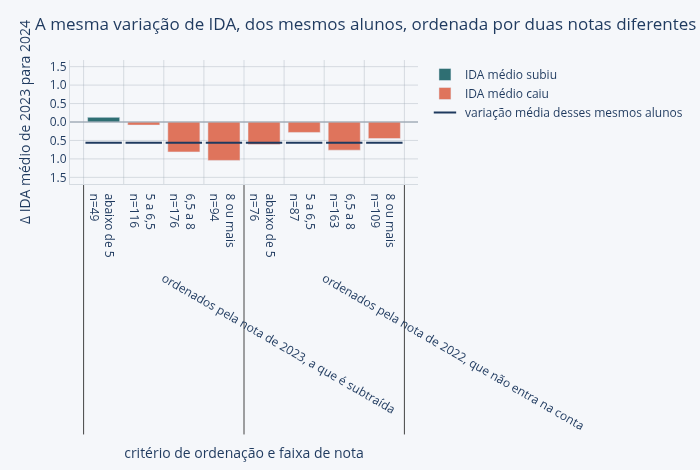

In [37]:
# ---------- Padrão 1: o ponto de partida entra duas vezes ----------
# Separar os alunos pela nota de t e olhar quanto eles variaram até t+1 mistura duas coisas, porque a nota
# que ordena é a mesma que foi subtraída para formar a variação. A tabela mede o tamanho da mistura sem
# supor nada: para cada indicador, compara a inclinação observada com a que se obtém só da correlação entre
# as duas medidas — r · (desvio de t+1 / desvio de t) − 1 —, que é o valor esperado quando a ordenação é a
# única coisa agindo. Quanto mais perto de 1 for a razão entre as duas, menos sobra para explicar.
linhas11 = []
for ind in IND:
    for nome, g in painel.groupby('transicao'):
        g = g.dropna(subset=[ind, f'{ind}_t1'])
        if len(g) < MIN_CELULA:
            continue
        x, y = g[ind], g[f'{ind}_t1'] - g[ind]
        r = np.corrcoef(x, g[f'{ind}_t1'])[0, 1]
        linhas11.append({'indicador': ind.upper(), 'transição': nome, 'n': len(g), 'corr t × t+1': r,
                         'inclinação observada': np.polyfit(x, y, 1)[0],
                         'prevista pela ordenação': r * g[f'{ind}_t1'].std() / x.std() - 1})
tab11 = pd.DataFrame(linhas11)
tab11['razão'] = tab11['inclinação observada'] / tab11['prevista pela ordenação']
print('O quanto da queda dos melhores já está na própria ordenação:')
print(tab11.round(2).to_string(index=False))

# A demonstração direta: a mesma variação, dos mesmos alunos, ordenada por duas notas diferentes. Só a
# primeira delas foi subtraída para formar a variação; a segunda é de um ano antes e não entra na conta.
FAIXAS11, ROTULOS11 = [0, 5, 6.5, 8, 10.001], ['abaixo de 5', '5 a 6,5', '6,5 a 8', '8 ou mais']
ida_ant = df[['id_aluno', 'ano', 'ida']].rename(columns={'ida': 'ida_ant'})
ida_ant['ano'] += 1
tri = painel.dropna(subset=['d_ida']).merge(ida_ant, on=['id_aluno', 'ano']).dropna(subset=['ida_ant'])
print(f'\nAlunos com IDA nos três anos: {len(tri)}, todos na transição {tri.transicao.unique()[0]}.')

partes11 = []
for crit, col in [('ordenados pela nota de 2023, a que é subtraída', 'ida'),
                  ('ordenados pela nota de 2022, que não entra na conta', 'ida_ant')]:
    t = tri.assign(faixa=pd.cut(tri[col], FAIXAS11, labels=ROTULOS11, right=False)) \
           .groupby('faixa', observed=True).d_ida.agg(media='mean', n='size',
                                                      melhoraram=lambda s: (s > 0).sum())
    partes11.append(pd.concat({crit: t}, names=['critério']))
tab11b = pd.concat(partes11)
tab11b['melhoraram_%'] = tab11b.melhoraram / tab11b.n * 100
print(tab11b.round(2).to_string())
print(f"\nCorrelação entre a nota que ordena e a variação: pela nota de 2023 "
      f"{tri[['ida', 'd_ida']].corr().iloc[0, 1]:+.2f}, pela de 2022 "
      f"{tri[['ida_ant', 'd_ida']].corr().iloc[0, 1]:+.2f}.")
print('Como cada faixa de 2023 foi alcançada (quanto o aluno já tinha variado de 2022 para 2023):')
print(tri.assign(faixa=pd.cut(tri.ida, FAIXAS11, labels=ROTULOS11, right=False), sub=tri.ida - tri.ida_ant)
         .groupby('faixa', observed=True).sub.agg(media='mean', n='size').round(2).to_string())

barras_variacao(tab11b, 'A mesma variação de IDA, dos mesmos alunos, ordenada por duas notas diferentes',
                'critério de ordenação e faixa de nota', 'Δ IDA médio de 2023 para 2024',
                nomes=('IDA médio subiu', 'IDA médio caiu'), passo=0.5,
                referencia=[tri.d_ida.mean()] * len(tab11b),
                nome_ref='variação média desses mesmos alunos').show()

**Leitura do padrão 1.** A tabela do topo mede quanto da "queda dos melhores" já está contido na forma como o
grupo foi montado. O raciocínio é direto: duas medições do mesmo aluno nunca são idênticas — aqui a
correlação entre um ano e o seguinte fica entre 0,25 e 0,65 —, e sempre que isso acontece, ordenar os alunos
pela primeira medição produz sozinho uma inclinação previsível na segunda. Nos 16 casos da base, a inclinação
observada e a prevista batem: a razão entre elas é 1,0 em todas as linhas. Não sobra nada para explicar por
outra via.

A demonstração está no gráfico, e ela dispensa a conta. São 435 alunos com IDA nos três anos e uma única
variação, a de 2023 para 2024, lida duas vezes. Ordenados pela nota de 2023 — que é justamente a nota
subtraída para formar a variação — o padrão é gritante: quem estava abaixo de 5 subiu 0,13 e quem estava em 8
ou mais caiu 1,04, com só 24,47% dos 94 melhorando. Ordenados pela nota de 2022, que não entra na conta, o
padrão some: −0,61, −0,28, −0,76 e −0,45, sem ordem nenhuma. A associação entre a nota que ordena e a
variação cai de −0,24 para −0,01. São os mesmos alunos e a mesma variação; muda só o critério da fila.

O último bloco impresso mostra por onde isso entra. Para estar na faixa de 8 ou mais em 2023, o aluno já
tinha subido 0,84 de 2022 para 2023; para estar abaixo de 5, já tinha caído 0,52. A faixa de cima não é a dos
alunos bons — é a dos alunos que vinham de um ano bom, e o ano seguinte não repete o ano bom.

A consequência para o relatório é uma regra de leitura. Sempre que uma faixa for definida pela mesma nota que
entra na variação, a inclinação não mede efeito, e o que se pode comparar é a ordem entre as faixas, nunca o
tamanho da queda. É exatamente o caso da P6, em que o IPP de partida e a variação do IPP são a mesma medida
entrando duas vezes — daí a associação com o progresso de fase encolher de −0,25 para −0,10 quando o ponto de
partida é descontado.

O mesmo mecanismo alcança um caso em que a faixa não é definida pela nota, e é a dívida que a P2 deixou aqui.
Lá os grupos são formados por quem avançou e quem permaneceu na fase, e mesmo assim eles partem de patamares
diferentes: 6,71 contra 6,07 na primeira transição, 7,00 contra 6,31 na segunda. Com a correlação entre um
ano e o seguinte abaixo de 1, um grupo que parte mais alto tende a variar para baixo em relação a um que
parte mais baixo, sem que nada mais os distinga. Quanto disso está dentro da distância entre −0,74 e +0,26
esta seção não mede; o que ela estabelece é que essa distância não pode ser lida inteira como efeito da
promoção. É por isso que a conclusão da P2 não se apoia nela, e sim na comparação de cada grupo com o seu
equivalente do ano anterior, onde os pontos de partida são bem mais próximos: 6,71 e 7,00 entre os
promovidos, 6,07 e 6,31 entre os que permaneceram.

Fora do relatório, a mesma regra derruba a frase mais comum dos balanços educacionais: "os alunos mais fracos
foram os que mais melhoraram".

                        n  2022→2023  2023→2024  empilhado  veio de juntar as transições (%)
par                                                                                         
Δ IEG × Δ IPV        1255       0.26       0.30       0.42                             47.24
Δ IEG × Δ IDA        1255       0.27       0.42       0.40                             15.13
IPS(t) × Δ IEG       1252      -0.01       0.06       0.20                             81.30
IPS(t) × Δ IDA       1253       0.06       0.05       0.12                             63.05
Δ IPS × Δ IPV        1248       0.07      -0.06      -0.35                             98.27
Δ IPP × Δ defasagem  1255       0.01      -0.25      -0.17                             35.81

Média de cada variável em cada transição — é a distância entre elas que produz a parcela acima:
  Δ IEG × Δ IPV          2022→2023: +0.23 e +0.55  |  2023→2024: -0.80 e -0.79
  Δ IEG × Δ IDA          2022→2023: +0.23 e +0.12  |  2023→2024: -0.80 e -0.48
 

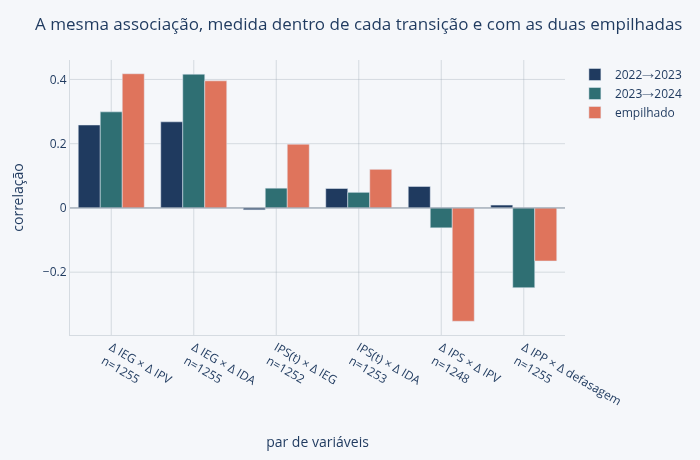

In [38]:
# ---------- Padrão 2: empilhar as duas transições cria sinal que não existe em nenhuma delas ----------
# Juntar 2022→2023 e 2023→2024 numa correlação só parece apenas dobrar a amostra, mas quando as duas
# transições têm médias diferentes nas duas variáveis, a diferença entre as médias vira associação sozinha.
# A conta abaixo abre a covariância empilhada em duas parcelas: a que existe dentro de cada transição e a
# que só aparece porque as duas foram postas juntas. A segunda não fala de aluno nenhum.
CASOS11 = [('Δ IEG × Δ IPV', 'd_ieg', 'd_ipv'), ('Δ IEG × Δ IDA', 'd_ieg', 'd_ida'),
           ('IPS(t) × Δ IEG', 'ips', 'd_ieg'), ('IPS(t) × Δ IDA', 'ips', 'd_ida'),
           ('Δ IPS × Δ IPV', 'd_ips', 'd_ipv'), ('Δ IPP × Δ defasagem', 'd_ipp', 'd_defasagem')]
linhas11c = []
for nome, a, b in CASOS11:
    g = painel.dropna(subset=[a, b])
    ma, mb = g[a].mean(), g[b].mean()
    entre = sum(len(h) * (h[a].mean() - ma) * (h[b].mean() - mb)
                for _, h in g.groupby('transicao')) / len(g)
    total = ((g[a] - ma) * (g[b] - mb)).mean()
    linhas11c.append({'par': nome, 'n': len(g),
                      **{t: np.corrcoef(h[a], h[b])[0, 1] for t, h in g.groupby('transicao')},
                      'empilhado': np.corrcoef(g[a], g[b])[0, 1],
                      'veio de juntar as transições (%)': entre / total * 100})
tab11c = pd.DataFrame(linhas11c).set_index('par')
print(tab11c.round(2).to_string())
print('\nMédia de cada variável em cada transição — é a distância entre elas que produz a parcela acima:')
for nome, a, b in CASOS11:
    g = painel.dropna(subset=[a, b])
    print(f'  {nome:22} ' + '  |  '.join(f'{t}: {h[a].mean():+.2f} e {h[b].mean():+.2f}'
                                         for t, h in g.groupby('transicao')))

# Aqui o eixo mantém o sinal, ao contrário dos gráficos de variação das outras seções. Lá o negativo era um
# recurso de leitura — para baixo o que piorou — e o rótulo mostrava o valor absoluto. Numa correlação o
# sinal é parte da quantidade: dizer 0,35 onde está −0,35 seria trocar o achado pelo seu contrário.
fig11 = go.Figure()
for serie, cor in zip(list(tab11c.columns[1:4]), [AZUL, TEAL, CORAL]):
    fig11.add_bar(x=rotulo_n(list(tab11c.index), tab11c.n), y=tab11c[serie], name=serie, marker_color=cor,
                  hovertemplate='%{y:+.2f}<extra>' + serie + '</extra>')
fig11.add_hline(y=0, line=dict(color=CINZA, width=1))
fig11.update_layout(barmode='group', title='A mesma associação, medida dentro de cada transição e com as '
                                           'duas empilhadas', xaxis_title='par de variáveis',
                    yaxis_title='correlação', hovermode='x unified', legend_title='')
aplicar_tema(fig11, 460).show()

**Leitura do padrão 2.** Somar as duas transições numa conta só parece apenas dobrar a amostra. Não é. Quando
as duas transições têm médias diferentes nas duas variáveis, a distância entre essas médias vira associação
sozinha, sem que nenhum aluno tenha feito nada. O gráfico põe as três medidas lado a lado: a correlação
dentro de cada transição e a das duas empilhadas.

O caso extremo é Δ IPS × Δ IPV. Dentro de cada transição a relação é +0,07 e −0,06, ou seja, nada; empilhada,
−0,35, e 98,27% desse valor vem de juntar as duas. O bloco de médias explica: o IPS cai 1,89 em média na
primeira transição e sobe 1,58 na segunda, enquanto o IPV faz o contrário, +0,55 e depois −0,80. Postas
juntas, uma transição fica no canto "IPS desce, IPV sobe" e a outra no canto oposto, e a reta que liga os
dois cantos é a correlação empilhada. Ela descreve a diferença entre dois anos, não a relação entre dois
indicadores. E o movimento do IPS por trás disso já tem nome: é o piso de escala de 2023 que a P5 encontrou.

O IPS(t) × Δ IEG conta a mesma história em outra direção: −0,01 e +0,06 dentro, +0,20 empilhado, com 81,30%
vindo do empilhamento. É exatamente o número que a P5 tinha diante de si e recusou.

O padrão serve tanto para derrubar quanto para sustentar. Δ IEG × Δ IDA vale 0,27 e 0,42 dentro das
transições e 0,40 empilhado, com apenas 15,13% vindo da junção: o achado da P3 não depende de empilhar — ele
está dentro de cada ano, e é por isso que é o que mais se sustenta neste relatório. Δ IEG × Δ IPV fica no meio
(0,26 e 0,30 dentro, 0,42 empilhado, 47,24% da junção): a associação existe nas duas transições, mas o
tamanho dela empilhada é inflado, e o número que vale é o de dentro.

Δ IPP × Δ defasagem é o caso oposto, e vale registrar para não parecer que empilhar sempre exagera: −0,25 na
segunda transição vira −0,17 empilhado, porque a primeira transição, que quase não tem sinal, dilui a
segunda. Empilhar não erra para mais nem para menos de forma previsível; ele simplesmente mede outra coisa.

Variação de cada indicador, repartida:
           alunos  entre alunos  dentro do aluno  dentro (%)
indicador                                                   
INDE          434          0.63             0.33       34.53
IDA           435          2.02             1.80       47.22
IEG           435          1.20             1.27       51.43
IPV           435          0.60             0.68       53.12
IAN           468          3.43             4.41       56.28
IPP           435          0.61             1.23       66.85
IAA           441          2.51             6.32       71.56
IPS           440          1.23             3.11       71.71


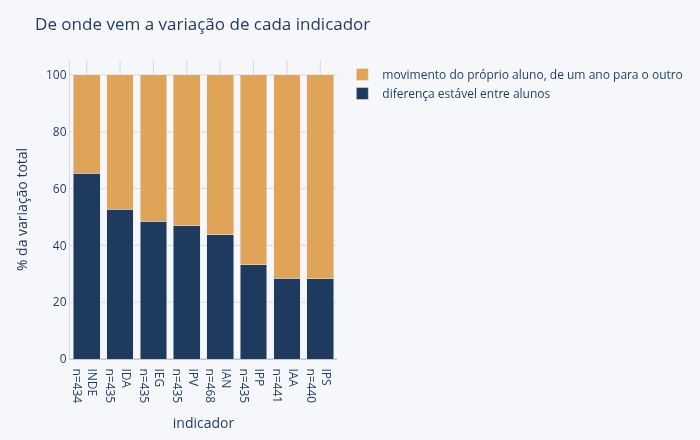

In [39]:
# ---------- Padrão 3: quanto de cada indicador é diferença entre alunos e quanto é movimento do aluno ----
# As duas perguntas que o relatório faz o tempo todo — onde o aluno está e para onde ele foi — não pedem a
# mesma coisa do indicador. Descrever posição exige que a nota separe um aluno do outro; detectar
# movimento exige que ela se mexa quando o aluno se mexe. A conta abaixo parte a variação total de cada
# indicador nessas duas: o quanto os alunos diferem entre si, na média dos três anos, e o quanto cada aluno
# oscila em torno da própria média. A população é a de quem tem o indicador nos três anos, e o n de cada um
# vai no rótulo do eixo porque eles não são iguais.
linhas11d = []
for ind in IND:
    p = df.pivot_table(index='id_aluno', columns='ano', values=ind).dropna()
    entre, dentro = p.mean(axis=1).var(), p.var(axis=1).mean()
    linhas11d.append({'indicador': ind.upper(), 'alunos': len(p), 'entre alunos': entre,
                      'dentro do aluno': dentro, 'dentro (%)': dentro / (entre + dentro) * 100})
tab11d = pd.DataFrame(linhas11d).set_index('indicador').sort_values('dentro (%)')
print('Variação de cada indicador, repartida:')
print(tab11d.round(2).to_string())

fig11d = go.Figure()
x11d = rotulo_n(list(tab11d.index), tab11d.alunos)
for nome, col, cor in [('diferença estável entre alunos', 100 - tab11d['dentro (%)'], AZUL),
                       ('movimento do próprio aluno, de um ano para o outro', tab11d['dentro (%)'], AMBAR)]:
    fig11d.add_bar(x=x11d, y=col, name=nome, marker_color=cor,
                   hovertemplate='%{y:.0f}% da variação<extra>' + nome + '</extra>')
fig11d.update_layout(barmode='stack', title='De onde vem a variação de cada indicador',
                     xaxis_title='indicador', yaxis_title='% da variação total', hovermode='x unified',
                     legend_title='')
aplicar_tema(fig11d, 440).show()

**Leitura do padrão 3.** As duas perguntas que este relatório faz o tempo todo pedem coisas opostas de um
indicador. Para dizer onde o aluno está, a nota precisa separar um aluno do outro e ficar parada quando nada
muda. Para dizer para onde ele foi, precisa se mexer quando o aluno se mexe. O gráfico reparte a variação de
cada indicador nessas duas metades, sobre quem tem a nota nos três anos.

Nos extremos estão o INDE e o IPS. Do INDE, só 34,53% da variação é movimento do próprio aluno: dois terços
dele são diferença estável entre alunos. É a definição de um bom resumo de posição, e a explicação de por que
ele funciona tão mal como alarme — a P8 chegou nisso por outro caminho. Do IPS, 71,71% é movimento, e do IAA,
71,56%.

Só que muito movimento não quer dizer instrumento sensível; pode querer dizer instrumento instável. E os dois
indicadores no topo da lista são exatamente os dois cujos instrumentos este relatório já teve que marcar: o
IAA carrega os zeros de recusa da P4, e o IPS carrega o piso de escala de 2023 da P5. O que sobe a variação
deles dentro do aluno não é o aluno mudando — é a medição mudando de um ano para o outro.

O IPP fica em 66,85%, e também tem ressalva de instrumento: o valor de 2022 é reconstruído pela fórmula do
INDE (P6). Feita a reserva, sobra a leitura que interessa. O IPP se mexe muito, e a P6 mostrou que ele não se
mexe em resposta ao progresso de fase. O que vale nele é o nível, não a variação — que é exatamente o uso que
a P8 e a P9 fazem dele.

O IAN, em 56,28%, não entra nessa leitura como instrumento: ele é função da defasagem, e o que se mexe dentro
do aluno é o aluno recuperando ou perdendo fase. É o achado da P1 aparecendo de novo, não uma propriedade da
medição.

No meio ficam IDA, IEG e IPV, entre 47,22% e 53,12%, repartidos quase pela metade. São os três que sustentam
leitura nas duas camadas ao mesmo tempo, e não é coincidência que sejam justamente os três que aparecem tanto
nas respostas sobre posição quanto nas respostas sobre trajetória.

Transições observadas: 1874. Marcadas como saída: 509. Dessas, 4 reaparecem em algum ano posterior (0.8%).

Saídas por ano de referência:
                saíram     n  taxa
ano_referencia                    
2022               260   860  30.2
2023               249  1014  24.6

Saídas por fase:
      saíram    n  taxa
fase                   
0.0       99  421  23.5
1.0       85  365  23.3
2.0       90  355  25.4
3.0      101  280  36.1
4.0       53  170  31.2
5.0       42  125  33.6
6.0       22   51  43.1
7.0       13   44  29.5
8.0        4   63   6.3
Fora do gráfico, por terem menos de 10 alunos: nenhuma categoria.


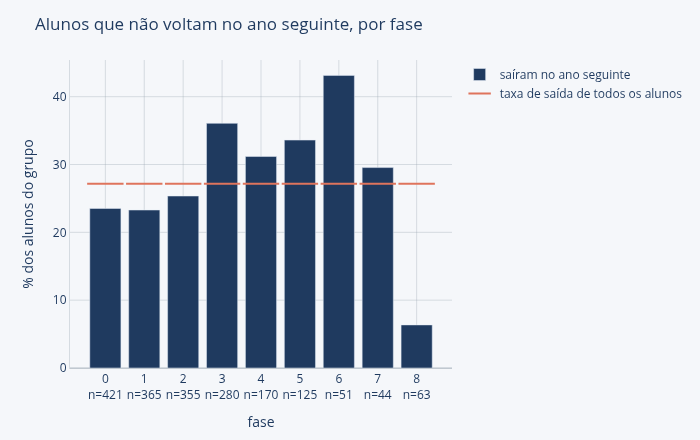


Saídas por faixa_idade:
             saíram    n  taxa
faixa_idade                   
6 a 9            89  373  23.9
10 a 12         159  674  23.6
13 a 15         157  516  30.4
16+             104  310  33.5
Fora do gráfico, por terem menos de 10 alunos: nenhuma categoria.


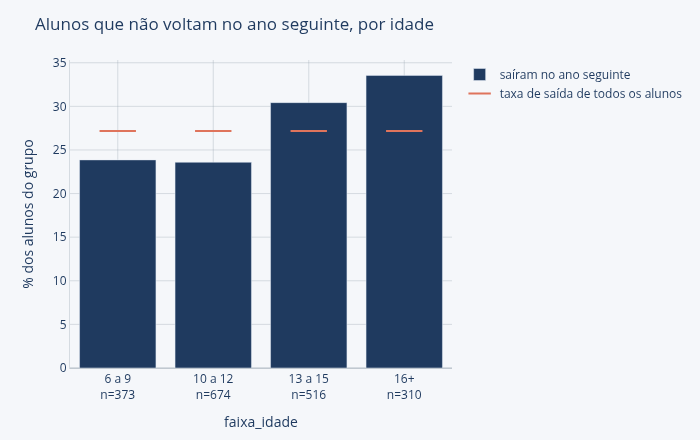

In [40]:
# ---------- Evasão: quantos saem e de onde ----------
# `evadiu` marca quem não reaparece na avaliação seguinte, e não uma saída confirmada da associação: o
# cadastro registra presença na PEDE, não desligamento. Antes de usar isso como se fosse evasão, a checagem
# que autoriza o atalho vai impressa — se muita gente marcada como evadida voltasse depois, a taxa estaria
# contando férias como saída.
e11 = ev.merge(df, left_on=['id_aluno', 'ano_referencia'], right_on=['id_aluno', 'ano'])
anos_do_aluno = df.groupby('id_aluno').ano.apply(set)
voltaram = sum(any(a > r.ano_referencia + 1 for a in anos_do_aluno.get(r.id_aluno, set()))
               for r in ev[ev.evadiu].itertuples())
print(f'Transições observadas: {len(ev)}. Marcadas como saída: {int(ev.evadiu.sum())}. Dessas, '
      f'{voltaram} reaparecem em algum ano posterior ({voltaram / ev.evadiu.sum() * 100:.1f}%).')
print('\nSaídas por ano de referência:')
print(ev.groupby('ano_referencia').evadiu.agg(saíram='sum', n='size',
                                              taxa=lambda s: s.mean() * 100).round(1).to_string())


def taxa_de_saida(chave, titulo, eixo_x):
    """Taxa de saída dentro de cada categoria, com a contagem impressa antes e o n no rótulo do eixo. As
    duas desagregações desta seção usam o mesmo desenho de propósito: a comparação que interessa é entre
    as categorias e contra a taxa geral, e trocar de gráfico no meio faria o leitor reaprender a ler."""
    t = e11.groupby(chave, observed=True).evadiu.agg(saíram='sum', n='size')
    t['taxa'] = t.saíram / t.n * 100
    print(f'\nSaídas por {eixo_x}:')
    print(t.round(1).to_string())
    finas = t[t.n < MIN_CELULA]
    print(f'Fora do gráfico, por terem menos de {MIN_CELULA} alunos: '
          + (', '.join(f'{i} (n = {v})' for i, v in finas.n.items()) or 'nenhuma categoria') + '.')
    t = t[t.n >= MIN_CELULA]
    return barras_taxa(t.taxa.rename('saíram no ano seguinte'), t.saíram.rename('saíram no ano seguinte'),
                       t.n.rename('saíram no ano seguinte'), titulo, eixo_x, '% dos alunos do grupo',
                       referencia=[e11.evadiu.mean() * 100] * len(t),
                       nome_ref='taxa de saída de todos os alunos')


taxa_de_saida('fase', 'Alunos que não voltam no ano seguinte, por fase', 'fase').show()
e11['faixa_idade'] = pd.cut(e11.idade, [5, 9, 12, 15, 25], labels=['6 a 9', '10 a 12', '13 a 15', '16+'])
taxa_de_saida('faixa_idade', 'Alunos que não voltam no ano seguinte, por idade', 'faixa_idade').show()

**Leitura da evasão — quanto e onde.** Antes do número, a definição. `evadiu` marca quem não reaparece na
avaliação do ano seguinte, e isso não é a mesma coisa que desligamento: o cadastro registra presença na PEDE,
não saída da associação. O que autoriza tratar um como o outro está impresso acima — das 509 saídas marcadas,
4 reaparecem em algum ano posterior, 0,8%. Quem não volta no ano seguinte, na prática, não volta.

Com isso na mão, o tamanho do problema: 30,2% dos 860 alunos de 2022 não estavam lá em 2023, e 24,6% dos
1.014 de 2023 não estavam em 2024. Entre um quarto e um terço da base se renova por ano, e esse número
explica por que quase toda a análise deste relatório precisou ser feita dentro do aluno: a média anual
compara turmas com um terço de gente diferente.

A fase 8 entra neste gráfico depois de ficar fora de quase todos os outros. Ela sai das contas de defasagem
porque a régua não se aplica ao ensino superior (nota metodológica); permanência se aplica a todo mundo, e
por isso ela aparece aqui — com 6,3% sobre 63 alunos, a menor taxa da base com folga.

Nas demais fases o desenho é um degrau, e não um pico. A fase 6 tem a maior taxa, 43,1%, mas são 22 alunos
entre 51, e as fases vizinhas ficam em 33,6% e 29,5%: o pico não se sustenta como pico. O que se sustenta é o
degrau. As fases 0 a 2 ficam entre 23,3% e 25,4%, sobre 355 a 421 alunos cada, e da fase 3 em diante nenhuma
fica abaixo de 29,5%. A idade conta a mesma coisa e no mesmo lugar: 23,9% e 23,6% até os 12 anos, 30,4% dos
13 aos 15 e 33,5% dos 16 em diante. Os dois cortes não são independentes — a fase ideal é definida pela idade
—, então é um degrau só, visto de dois ângulos: o aluno que entra na adolescência.

Indicadores do ano de referência, para quem ficou e para quem saiu:
      ficaram  saíram  diferença
IDA      6.66    5.70      -0.96
IEG      8.60    7.57      -1.03
IAA      8.70    8.51      -0.19
IPS      5.96    6.00       0.03
IPP      7.01    6.80      -0.21
IPV      7.81    7.27      -0.54
INDE     7.37    6.76      -0.61

Alunos por indicador:
      ficaram  saíram
IDA      1293     504
IEG      1293     505
IAA      1150     432
IPS      1303     502
IPP      1293     505
IPV      1293     505
INDE     1290     501

Idade e defasagem médias:
        idade       defasagem      
         mean  size      mean  size
evadiu                             
False   12.19  1365     -0.72  1365
True    12.72   509     -0.96   509


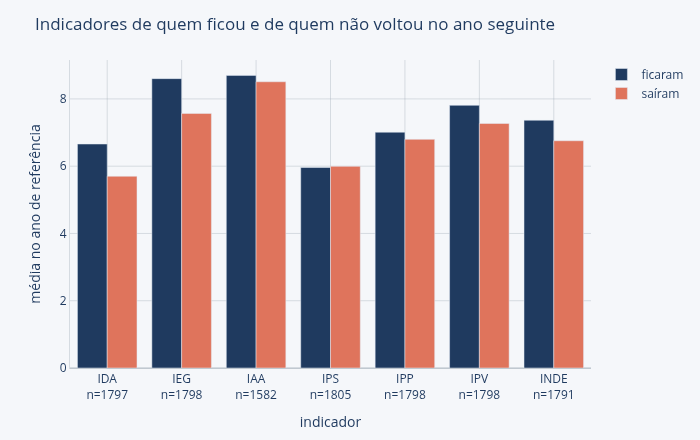

In [41]:
# ---------- Evasão: o que separa quem sai de quem fica ----------
# O IAA entra aqui na versão sem as recusas, pelo motivo que a P4 estabeleceu: o zero de recusa não é uma
# autoavaliação baixa, e deixá-lo dentro faria a diferença entre os dois grupos medir quem respondeu ao
# questionário. Os indicadores estão todos na mesma escala de 0 a 10, então cabem no mesmo gráfico.
COLS11 = ['ida', 'ieg', 'iaa_val', 'ips', 'ipp', 'ipv', 'inde']
med11 = e11.groupby('evadiu')[COLS11].mean().T
n11 = e11.groupby('evadiu')[COLS11].count().T
med11.columns = n11.columns = ['ficaram', 'saíram']
med11.index = n11.index = [c.replace('_val', '').upper() for c in COLS11]
print('Indicadores do ano de referência, para quem ficou e para quem saiu:')
print(med11.join(med11.saíram.sub(med11.ficaram).rename('diferença')).round(2).to_string())
print('\nAlunos por indicador:')
print(n11.to_string())
print('\nIdade e defasagem médias:')
print(e11.groupby('evadiu')[['idade', 'defasagem']].agg(['mean', 'size']).round(2).to_string())

barras_nivel(med11, n11, 'Indicadores de quem ficou e de quem não voltou no ano seguinte',
             'indicador', 'média no ano de referência', cores=(AZUL, CORAL)).show()

**Leitura da evasão — quem sai.** Quem não volta já estava atrás no ano em que foi medido, e a distância se
concentra em dois indicadores: o IEG, 8,60 contra 7,57 (1.293 alunos que ficaram, 505 que saíram), e o IDA,
6,66 contra 5,70 (1.293 e 504) — cerca de um ponto em cada. O INDE recolhe a soma disso e fica em 7,37
contra 6,76. Entrega e desempenho são o que separa os dois grupos.

O IPS é a exceção, e ela vale mais do que a regra: 5,96 para quem fica e 6,00 para quem sai, uma diferença de
0,03 que não é diferença nenhuma. O indicador de acompanhamento psicossocial é o único que não vê a saída
chegando. É o mesmo indicador que a P5 mostrou não antecipar queda de nota e que a P9 teve que descartar da
lista de sinais confiáveis — três perguntas diferentes, a mesma resposta.

Isso fecha o argumento que abre o notebook. A média anual de qualquer indicador melhora sozinha quando sai um
grupo com IEG um ponto abaixo e IDA quase um ponto abaixo. Não é uma suspeita metodológica: é a diferença
medida entre quem saiu e quem ficou.

**O que esta leitura não é.** Um modelo de risco de evasão. Ela descreve o aluno que saiu depois de ele ter
saído; não diz, para um aluno específico no começo do ano, qual a chance de ele não voltar. A diferença de um
ponto é entre médias de grupos com mais de quinhentos e mais de mil e duzentos alunos, e média não separa
indivíduo.

Alunos em 2022: 860, dos quais 132 indicados a bolsa (15.3%).

Indicação por fase:
indicado_bolsa  Não  Sim  taxa    n
fase                               
0.0             176   14   7.4  190
1.0             169   23  12.0  192
2.0             147    8   5.2  155
3.0             117   31  20.9  148
4.0              50   26  34.2   76
5.0              47   13  21.7   60
6.0              14    4  22.2   18
7.0               8   13  61.9   21

Indicadores médios por indicação:
                inde   ida   ieg  iaa_val   ips   ipp   ipv  defasagem  idade
indicado_bolsa                                                               
Não             6.97  5.95  7.86     8.67  6.85  6.13  7.14      -0.93  11.86
Sim             7.41  6.88  8.06     8.64  7.21  7.12  7.86      -0.99  13.68

Não indicados com INDE igual ou acima da mediana dos indicados (7.59): 214.
Idade média deles: 10.8 anos, contra 13.7 dos indicados. Por fase:
fase
0.0    67
1.0    55
2.0    36
3.0    20
4.0    16
5.0    14
6

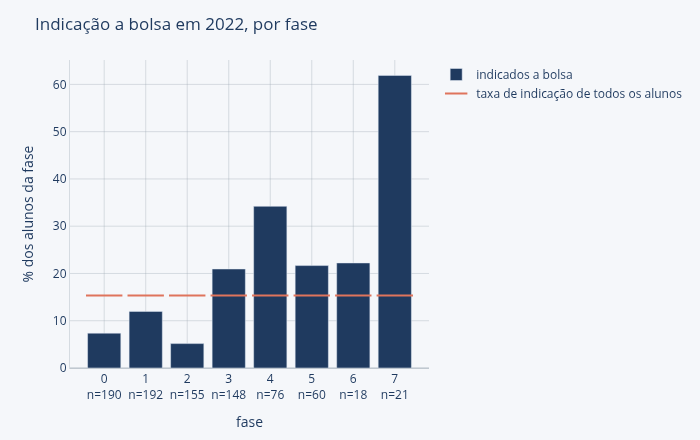


INDE médio dentro de cada fase, por indicação (média e n):
indicado_bolsa   Não   Sim  Não (n)  Sim (n)
fase                                        
0.0             7.32  7.98      176       14
1.0             7.09  8.03      169       23
2.0             6.90  7.99      147        8
3.0             6.42  7.26      117       31
4.0             6.98  7.05       50       26
5.0             6.84  7.00       47       13
6.0             7.16  7.33       14        4
7.0             6.22  6.89        8       13

Fora do gráfico, por terem menos de 10 alunos: "Sim" na fase 2 (n = 8), "Sim" na fase 6 (n = 4), "Não" na fase 7 (n = 8).


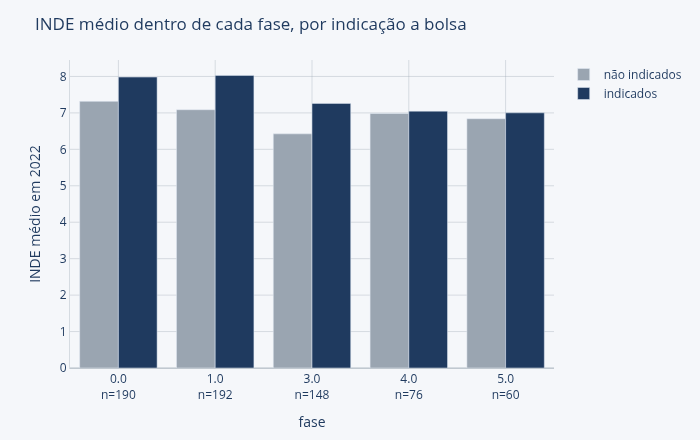

In [42]:
# ---------- Indicação a bolsa em 2022 ----------
# A leitura anterior desta seção comparava a nota dos indicados com a dos não indicados e contava quantos
# ficaram de fora com nota alta. Só que a bolsa não é sorteada dentro de um grupo único: se a indicação
# depender também da fase, comparar todo mundo de uma vez confunde o critério com a distribuição das
# fases. As duas contas vão lado a lado — a taxa de indicação por fase e a nota dos dois grupos dentro de
# cada fase — porque é a segunda que diz se, entre iguais, a nota está sendo usada.
b22 = df[df.ano == 2022]
ind22 = b22.pivot_table(index='fase', columns='indicado_bolsa', values='inde', aggfunc='size', fill_value=0)
ind22['taxa'] = ind22['Sim'] / ind22[['Não', 'Sim']].sum(axis=1) * 100
ind22['n'] = ind22[['Não', 'Sim']].sum(axis=1)
print(f"Alunos em 2022: {len(b22)}, dos quais {int(ind22['Sim'].sum())} indicados a bolsa "
      f"({ind22['Sim'].sum() / len(b22) * 100:.1f}%).")
print('\nIndicação por fase:')
print(ind22.round(1).to_string())

print('\nIndicadores médios por indicação:')
print(b22.groupby('indicado_bolsa')[['inde', 'ida', 'ieg', 'iaa_val', 'ips', 'ipp', 'ipv', 'defasagem',
                                     'idade']].mean().round(2).to_string())

med_ind = b22.loc[b22.indicado_bolsa == 'Sim', 'inde'].median()
esq22 = b22[(b22.indicado_bolsa == 'Não') & (b22.inde >= med_ind)]
print(f'\nNão indicados com INDE igual ou acima da mediana dos indicados ({med_ind:.2f}): {len(esq22)}.')
print(f'Idade média deles: {esq22.idade.mean():.1f} anos, contra '
      f"{b22.loc[b22.indicado_bolsa == 'Sim', 'idade'].mean():.1f} dos indicados. Por fase:")
print(esq22.fase.value_counts().sort_index().to_string())
print('\nTaxa de indicação só entre os alunos com INDE acima dessa mediana:')
acima22 = b22[b22.inde >= med_ind].pivot_table(index='fase', columns='indicado_bolsa', values='inde',
                                               aggfunc='size', fill_value=0)
acima22['taxa'] = acima22['Sim'] / acima22[['Não', 'Sim']].sum(axis=1) * 100
print(acima22.round(1).to_string())

# A bolsa retém? A checagem cabe aqui porque a evasão acabou de ser medida, e a resposta muda a frente de
# ação: se retivesse, ampliar o programa teria efeito próprio, além do mérito de quem recebe.
eb22 = ev[ev.ano_referencia == 2022].merge(b22[['id_aluno', 'indicado_bolsa']], on='id_aluno')
print('\nSaída no ano seguinte, por indicação:')
print(eb22.groupby('indicado_bolsa').evadiu.agg(saíram='sum', n='size',
                                                taxa=lambda s: s.mean() * 100).round(1).to_string())

barras_taxa(ind22.taxa.rename('indicados a bolsa'), ind22['Sim'].rename('indicados a bolsa'),
            ind22.n.rename('indicados a bolsa'), 'Indicação a bolsa em 2022, por fase', 'fase',
            '% dos alunos da fase', referencia=[b22.indicado_bolsa.eq('Sim').mean() * 100] * len(ind22),
            nome_ref='taxa de indicação de todos os alunos').show()

# Dentro de cada fase, quem foi indicado tinha nota maior? Fases com menos de MIN_CELULA alunos de um dos
# lados saem do gráfico: uma diferença apoiada em quatro alunos não sustenta conclusão sobre critério.
nota22 = b22.pivot_table(index='fase', columns='indicado_bolsa', values='inde', aggfunc='mean')
cont22 = b22.pivot_table(index='fase', columns='indicado_bolsa', values='inde', aggfunc='size',
                         fill_value=0)
print('\nINDE médio dentro de cada fase, por indicação (média e n):')
print(nota22.round(2).join(cont22, rsuffix=' (n)').to_string())
finas22 = [(f, c, int(v)) for f in cont22.index for c, v in cont22.loc[f].items() if v < MIN_CELULA]
print(f'\nFora do gráfico, por terem menos de {MIN_CELULA} alunos: '
      + (', '.join(f'"{c}" na fase {f:g} (n = {v})' for f, c, v in finas22) or 'nenhuma célula') + '.')
manter22 = (cont22 >= MIN_CELULA).all(axis=1)
nota22, cont22 = nota22[manter22], cont22[manter22]
nota22.columns = cont22.columns = ['não indicados', 'indicados']
barras_nivel(nota22, cont22, 'INDE médio dentro de cada fase, por indicação a bolsa', 'fase',
             'INDE médio em 2022', cores=(CINZA, AZUL)).show()

**Leitura da indicação a bolsa.** Em 2022, 132 dos 860 alunos foram indicados, 15,3% da base. A leitura
anterior desta seção comparava a nota dos indicados com a dos não indicados, encontrava 214 não indicados com
INDE igual ou acima da mediana dos indicados (7,59) e concluía que o critério estava deixando gente de fora.
Os dois gráficos desta célula mostram que a conclusão não se sustenta como estava escrita.

O primeiro mostra que a indicação não é distribuída por igual entre as fases: 7,4% na fase 0 e 61,9% na fase
7, subindo quase sem interrupção. Comparar indicados e não indicados de toda a base de uma vez é, por isso,
comparar fases diferentes — e é o que produz os 214. Eles estão onde a indicação é rara para todo mundo: 67
na fase 0, 55 na fase 1 e 36 na fase 2 respondem pela maior parte deles, e a idade média do grupo é 10,8 anos
contra 13,7 dos indicados.

O segundo gráfico faz a comparação certa, dentro de cada fase, e o resultado inverte a leitura antiga: em
todas as fases em que os dois grupos têm alunos suficientes, os indicados têm INDE médio maior — 7,32 contra
7,98 na fase 0, 6,42 contra 7,26 na fase 3. Entre iguais, a nota está sendo usada. E mesmo olhando só os
alunos com INDE acima daquela mediana, a taxa de indicação continua subindo com a fase: 14,1% na fase 0
contra 39,4% na fase 3 e 100% na fase 7.

O que sobra, então, não é "o critério ignora a nota". É outra coisa: **o critério é nota dentro de fase, e a
fase pesa mais do que a nota.** Isso pode ser exatamente o que a associação quer — bolsa para quem está perto
de concluir tem outro sentido que bolsa para uma criança na fase 0. Mas é uma escolha, não uma consequência
da regra publicada, e ela não está escrita em lugar nenhum.

Uma última checagem, que a evasão medida logo acima tornou barata: a bolsa não retém. Dos indicados de 2022,
28,8% não voltaram em 2023, contra 30,5% dos não indicados. A diferença é pequena demais para sustentar
qualquer efeito de permanência, e isso fecha uma porta — ampliar a indicação pode ser justificado pelo mérito
de quem recebe, não por um efeito próprio sobre a evasão.

### Resposta da P11

**Três padrões atravessam todas as respostas anteriores, e nenhum deles é sobre os alunos: são sobre a forma
de medir.** O ponto de partida entra duas vezes sempre que uma faixa é definida pela nota que depois será
subtraída. Empilhar as duas transições numa conta só transforma a diferença entre dois anos em associação
entre dois indicadores — 98,27% do que parecia ligar o IPS ao IPV vem daí. E cada indicador reparte sua
variação entre alunos e dentro do aluno de um jeito próprio, o que decide para qual pergunta ele serve.

O que sobrevive aos três é pouco e é claro. O IEG e o IDA andam juntos dentro do aluno em cada transição
separadamente, 0,27 e 0,42, com só 15,13% do valor empilhado vindo da junção: é o achado mais sólido do
relatório. O INDE tem só 34,53% da variação dentro do aluno, o que faz dele um bom resumo de posição e um mau
alarme. O IPS e o IAA passam de 70%, mas os dois carregam problema de instrumento já identificado — o piso de
escala de 2023 e os zeros de recusa —, então o que se mexe neles não é necessariamente o aluno.

Os dois assuntos que sobraram são os mais acionáveis da seção. **A evasão é grande e tem endereço:** 30,2% em
2022 e 24,6% em 2023, com um degrau claro a partir da fase 3 e dos 13 anos. Quem sai já estava atrás em
entrega e desempenho — IEG 7,57 contra 8,60, IDA 5,70 contra 6,66 —, e o IPS, que é o indicador desenhado
para enxergar exatamente esse aluno, não vê diferença nenhuma: 6,00 contra 5,96. **E a bolsa não é o que a
regra publicada sugere:** a indicação vai de 7,4% na fase 0 a 61,9% na fase 7, e dentro de cada fase a nota é
usada. O critério é nota dentro de fase, com a fase pesando mais.

**O que a seção não estabelece.** Que os três padrões esgotam as explicações. Eles dizem quanto de um número
já vem da forma de medir; não provam que o resto é efeito. Também não estabelecem causa em nenhum dos dois
assuntos finais: quem sai é descrito depois de ter saído, e a bolsa é descrita pelo critério observado, não
pelo que ela produz. A única checagem de efeito feita aqui é a de retenção, e ela deu negativa.

**Frentes:**

1. **Fixar as três regras de leitura em qualquer número que a associação publicar.** Não ordenar alunos pela
   nota que será subtraída; não somar anos diferentes numa correlação só; não ler a variação de um indicador
   sem saber se quem se mexeu foi o aluno ou a régua. As três já mudaram conclusões deste relatório, e vão
   mudar as do próximo.
2. **Tratar a passagem para a fase 3 como frente de retenção, e não a fase 6.** O degrau da evasão está ali,
   apoiado em centenas de alunos de cada lado, enquanto o pico aparente de 43,1% na fase 6 são 22 alunos. E o
   gatilho tem que ser IEG e IDA, porque o IPS não antecipa a saída.
3. **Escrever o critério da bolsa como ele é praticado.** Prioridade por fase, com a nota decidindo entre
   iguais, é uma escolha defensável — mas ela não está escrita, e a leitura de mérito puro produz a impressão
   falsa de que há alunos com nota alta sendo esquecidos. Junto disso, parar de tratar a bolsa como
   instrumento de permanência: 28,8% dos indicados não voltaram no ano seguinte, contra 30,5% dos não
   indicados.

## Síntese executiva

Este relatório responde onze perguntas em duas camadas. A **transversal** compara alunos diferentes ano a
ano; a **longitudinal** acompanha o mesmo aluno de um ano para o outro, nas 1.365 transições consecutivas da
base. Quando as duas discordam, quem decide é a segunda, e a P11 mostra por quê com o número na mão: quem não
volta no ano seguinte tinha, no ano em que foi medido, IEG um ponto abaixo e IDA quase um ponto abaixo de
quem ficou. Entre um quarto e um terço da base se renova por ano. Uma média anual pode subir sem que nenhum
aluno tenha melhorado — basta que os alunos certos tenham saído.

| # | Pergunta | Achado principal |
|---|----------|------------------|
| 1 | Defasagem (IAN) | Cai de **69,9% (2022) → 56,9% (2023) → 49,2% (2024)**, e a queda é real, não composição: sobre o total de alunos acompanhados, **20,9% recuperam a fase ideal** contra 10,9% que a perdem — dois para um. O destino do conjunto também melhora de uma transição para a outra: em 2022→2023, 61% dos alunos permaneceram defasados ou se tornaram defasados; em 2023→2024, apenas 42,6%. |
| 2 | Desempenho (IDA) | **Não está em alta.** A média anual sobe porque muda quem está sendo medido. No mesmo aluno, +0,12 em 2022→2023 e **−0,48 em 2023→2024**. A explicação mais simpática — seria só o efeito de promover mais alunos para conteúdo mais difícil — foi medida e não cobre o buraco: trocar só a proporção de promovidos move 0,09 da queda de 0,59, contra 0,52 de desempenho dentro dos grupos. E ele desaba na fase 3 (−1,25 sobre 167 alunos). |
| 3 | Engajamento (IEG) | **O achado mais sólido do relatório.** Entre os alunos cujo IEG subiu, 55,3% melhoraram de IDA, contra 34,5% entre os demais, e o efeito sobrevive a separar promovidos de não promovidos. A P11 confirma que ele não depende de empilhar anos: vale 0,27 e 0,42 dentro de cada transição. É a alavanca em que a associação mexe diretamente. |
| 4 | Autoavaliação (IAA) | **Achado sobre o instrumento, não sobre os alunos.** Os zeros do IAA são recusa de participar, não nota (PEDE 2022, p. 133): 190 dos 951 alunos de 2023, **19,98%**. A penalidade muda a pedra de **148 dos 245** afetados. Alinhamento com desempenho: 87,5% se avaliam acima do próprio IDA, **+2,25** em média. **Nenhuma comparação de IAA que atravesse 2023 é válida.** |
| 5 | IPS antecede quedas | **Achado refutado.** Dentro de cada transição, o IPS de hoje vale 0,06 e 0,05 para a variação de desempenho e −0,01 e 0,06 para a de engajamento, e os quartis não formam gradiente — em 2023→2024 quem mais caiu foi o quartil de IPS **mais alto**. Causa: **28,0% da base está no piso da escala em 2023**, contra 0,1% em 2022. Na P11, 81,30% do valor empilhado vinha de somar os dois anos. |
| 6 | IPP × IAN | **Confirma como retrato, não como acompanhamento.** Alunos mais defasados recebem IPP menor (+0,24 entre alunos, estável nos dois anos); mas quando a defasagem do mesmo aluno muda, o IPP quase não acompanha — os −0,25 de 2023→2024 caem para −0,10 assim que o ponto de partida é descontado, mecanismo demonstrado na P11. O IPP descreve a situação; não mede progresso. |
| 7 | Drivers do IPV | **Descrever onde o aluno está é fácil; prever para onde ele vai, não.** Entre alunos, IDA (0,38) e IEG (0,36) dominam o IPV. Na variação eles seguem liderando, mas quase nada explica quase nada: a distância entre 0,42 e 0,10 de poder explicativo é, ela mesma, o achado. |
| 8 | Combinações → INDE | **Não triar alunos pelo INDE sozinho.** O índice é derivado, não observado — a regressão recupera os pesos oficiais até a quarta casa. Mas peso nominal e influência real não coincidem: IDA, IEG e IPV valem 60% no papel e respondem por **70,4%** da variação, enquanto IPS fica em 3,6% e IPP em 5,3%. E é o IPP, o menos influente no índice, que é a associação mais forte com defasagem e o segundo sinal de risco mais forte da P9. |
| 9 | Previsão de risco | **Viável, e útil.** De cada 10 alunos que vão se defasar no ano seguinte, cerca de 8 são sinalizados; de cada 10 sinalizados, cerca de 8 realmente se defasam. Sinalizar simplesmente quem já está defasado acerta 69%; o modelo acrescenta 11 pontos de precisão sobre essa régua. Modelo completo em `04_modelagem.ipynb`. |
| 10 | Efetividade | **Sim, para quem fica.** Na coorte de 468 alunos presente nos três anos, a defasagem cai de **67,3% → 58,1% → 34,8%** — as mesmas pessoas. O INDE dessa coorte não se move porque IAN (+1,49) e IPP (+1,26) cancelam IEG (−0,58), IDA (−0,47) e IPV (−0,22) — e desses dois, o IAN é a própria queda de defasagem contada por outro caminho e o IPP atravessa o degrau de instrumento da P6. A taxa publicada de 49,2% é maior porque inclui os **358 alunos que chegaram em 2024**, 62,8% deles já defasados. |
| 11 | O que atravessa | **Três regras de leitura e dois achados operacionais.** Não ordenar pela nota que será subtraída, não somar transições numa correlação só, não confundir movimento do aluno com movimento da régua. Evasão: 30,2% e 24,6%, com degrau na fase 3 e aos 13 anos; quem sai já estava um ponto abaixo em IEG e IDA, e o IPS não vê. Bolsa: o critério é nota dentro de fase, a fase pesa mais, e a bolsa não retém (28,8% contra 30,5%). |

**O fio que liga tudo.** A P1 mostra o resultado central: a defasagem cai, e cai no mesmo aluno. A P10
confirma isso no grupo que atravessa os três anos e mostra o preço — para recuperar fase, o programa promove
alunos para conteúdo mais difícil, e é ali que a P2 encontra a queda de IDA. Só que a P2 também mede essa
explicação, e ela não cobre tudo: a maior parte da queda é desempenho, não promoção, e se concentra na fase 3.
Do lado dos instrumentos, a P4 mostra que um dos indicadores não é comparável entre anos e a P11 mostra que
outros dois se mexem por razão de régua, o que restringe bastante o que se pode ler das séries. O que sobra
de sólido para agir é o IEG (P3), que é onde a associação mexe, e o IPP (P8), que vale pouco no índice e
muito como sinal de risco. A P9 fecha o circuito transformando esse sinal em ferramenta: dá para saber com um
ano de antecedência quem vai se defasar, que é a única forma de agir antes de a defasagem acontecer.

**O que não se sustenta.** Cinco leituras que a foto anual sugeria não passam no teste do mesmo aluno, e
registrá-las importa tanto quanto os achados positivos: o IDA em alta (P2 — é seleção de quem permanece); o
IPS como sinal antecedente de queda (P5 — é o piso de escala de 2023 somado ao empilhamento das transições);
a queda de autoimagem em 2023 (P4 — é recusa de participar); o IPP como indicador que responde ao progresso
de fase (P6 — é o ponto de partida entrando duas vezes, demonstrado na P11); e o INDE parado da coorte como
sinal de que nada aconteceu em três anos (P10 — é cancelamento entre ganhos e perdas grandes).

A sexta era deste próprio notebook, e cai pelo mesmo motivo que as outras: os "214 alunos com nota alta
esquecidos pela bolsa" somem quando a comparação é feita dentro de cada fase. Todas juntas são o motivo de o
painel de alunos, e não a média anual, ser a unidade de análise deste relatório.